# <a id='toc1_'></a>[Bericht zur Datenqualität (klin) 📉](#toc0_)

**Table of contents**<a id='toc0_'></a>    
- [Bericht zur Datenqualität (klin) 📉](#toc1_)    
  - [Änderungen seit der letzten Version](#toc1_1_)    
  - [Datenstand ⏱️](#toc1_2_)    
  - [Lieferdatum 📆](#toc1_3_)    
  - [Fallzahlen](#toc1_4_)    
    - [absolut](#toc1_4_1_)    
    - [relativ](#toc1_4_2_)    
  - [missings](#toc1_5_)    
  - [Fallzahlen epi vs clin](#toc1_6_)    
  - [Verteilung von Variablen](#toc1_7_)    
    - [UICC (p)](#toc1_7_1_)    
    - [Diagnosesicherung](#toc1_7_2_)    
    - [Geschlecht](#toc1_7_3_)    
    - [Diagnosejahr](#toc1_7_4_)    
    - [Inzidenzort vs Lieferregister](#toc1_7_5_)    
    - [ICD10 Gruppen](#toc1_7_6_)    
    - [Verstorben](#toc1_7_7_)    
    - [TNM-T (p)](#toc1_7_8_)    
    - [TNM-N (p)](#toc1_7_9_)    
    - [TNM-M (p)](#toc1_7_10_)    
    - [TNM-Auflage (p)](#toc1_7_11_)    
    - [Todesursachen (TU)](#toc1_7_12_)    
      - [nach ICD10 Einstellern](#toc1_7_12_1_)    
      - [nach Sterbejahr und Todesursachen](#toc1_7_12_2_)    
      - [nach hat_todesursache bei Nicht-Verstorbenen](#toc1_7_12_3_)    
      - [nach ICD10 Dreistellern (TOP 5)](#toc1_7_12_4_)    
      - [nach IsGrundleiden](#toc1_7_12_5_)    
    - [OP](#toc1_7_13_)    
      - [nach ICD10](#toc1_7_13_1_)    
      - [nach Intention](#toc1_7_13_2_)    
    - [OPS](#toc1_7_14_)    
      - [nach OPS ICD Kapitel (Top 10)](#toc1_7_14_1_)    
      - [nach OPS Einzelcodes (Top 5)](#toc1_7_14_2_)    
    - [SYST](#toc1_7_15_)    
      - [nach Stellung_OP](#toc1_7_15_1_)    
  - [Missings / Unbekannt in den Daten](#toc1_8_)    
    - [Missings für verpflichtende Variablen in Tumor Element](#toc1_8_1_)    
    - [Missings für Therapieangaben](#toc1_8_2_)    
      - [Missings für alle Therapien](#toc1_8_2_1_)    
      - [Missings für Operationen](#toc1_8_2_2_)    
      - [Missings für Strahlentherapie](#toc1_8_2_3_)    
      - [Missings für systemische Therapie](#toc1_8_2_4_)    
    - [Missings für Folgeereignisse](#toc1_8_3_)    
    - [Missings für Freitexte](#toc1_8_4_)    
    - [Missings für Tumorstadien](#toc1_8_5_)    
    - [Missings für organspezifische Variablen (Mamma)](#toc1_8_6_)    
    - [Missings für organspezifische Variablen (Prostata)](#toc1_8_7_)    
    - [Missings für organspezifische Variablen (Darm)](#toc1_8_8_)    
    - [Missings für organspezifische Variablen (Melanom)](#toc1_8_9_)    
    - [Unbekannt-Kodierungen für ausgewählte Variablen](#toc1_8_10_)    
  - [Verteilung Monat von Datum_Vitalstatus](#toc1_9_)    
  - [Numerische Variablen 🔢](#toc1_10_)    
    - [Diagnosealter](#toc1_10_1_)    
    - [Anzahl Tage zwischen Diagnose und Tod](#toc1_10_2_)    
    - [Tumordicke](#toc1_10_3_)    
    - [PSA](#toc1_10_4_)    
    - [LK_befallen](#toc1_10_5_)    
    - [LK_untersucht](#toc1_10_6_)    
    - [RektumAbstandAnokutanlinie](#toc1_10_7_)    
    - [LDH](#toc1_10_8_)    

<!-- vscode-jupyter-toc-config
	numbering=false
	anchor=true
	flat=false
	minLevel=1
	maxLevel=6
	/vscode-jupyter-toc-config -->
<!-- THIS CELL WILL BE REPLACED ON TOC UPDATE. DO NOT WRITE YOUR TEXT IN THIS CELL -->

## <a id='toc1_1_'></a>[Änderungen seit der letzten Version](#toc0_)
- Neulieferung `08-BW`

<br>

## <a id='toc1_2_'></a>[Datenstand ⏱️](#toc0_)

In [2]:
import os
from pathlib import Path
import pandas as pd
import duckdb as ddb
from connection_helper import sql
from pandas_plots import tbl, pls, hlp
from enum import Enum
import duckdb as ddb

hlp.show_package_version()
os.environ["RENDERER"] = "svg"
os.environ['THEME']='light'

dir_db=Path("C://temp") if hlp.get_os(hlp.OperatingSystem.WINDOWS) else Path(os.path.expanduser("~/tmp"))
file_db_clin = dir_db/'2025-11-11_data_clin.duckdb'
file_db_intern = dir_db/'2025-11-11_internal_clin.duckdb'
file_db_epi = dir_db/'2025-06-20_data_epi.duckdb'
URL_V2 = 'https://gitlab.opencode.de/robert-koch-institut/zentrum-fuer-krebsregisterdaten/cancerdata-references/-/raw/main/data/v2/'

if not file_db_clin.exists() or not file_db_epi.exists() or not file_db_intern.exists():
    raise FileNotFoundError()

🐍 3.12.8 | 📦 pandas: 2.3.3 | 📦 numpy: 1.26.4 | 📦 duckdb: 1.4.1 | 📦 pandas-plots: 0.21.3 | 📦 connection-helper: 0.13.1


In [3]:
sql.print_meta(file_db_clin)

sqlite db file:          2025-11-11_data_clin.duckdb
data tag:                v2.3
last kkr data import:    2025-09-30
sql table created:       2025-11-11 11:52:01
doi:                     10.18444/5.03.01.0005.0021.0002
document created:        2025-11-13 17:33:27


In [4]:
con = ddb.connect()
_=con.execute("PRAGMA disable_progress_bar;")
_=con.execute(f"ATTACH DATABASE '{file_db_epi}' AS epi (READ_ONLY);")
_=con.execute(f"ATTACH DATABASE '{file_db_intern}' AS intern (READ_ONLY);")
_=con.execute(f"ATTACH DATABASE '{file_db_clin}' AS clin (READ_ONLY); SET SCHEMA 'clin';")

In [72]:
dim_icd10_3d = sql.load_file_to_duckdb(con, URL_V2 + "Aggregationen/icd10_3d.csv", sep=";")
dim_syst_op_stellung = sql.load_file_to_duckdb(con, URL_V2 + "Klassifikationen/syst_op_stellung.csv", sep=";")

Applikationsart = con.sql("select * from clin.Applikationsart")
Bestrahlung = con.sql("select * from clin.Bestrahlung")
Diagnose_Fernmetastase = con.sql("select * from clin.Diagnose_Fernmetastase")
Diagnose_WeitereKlassifikation = con.sql("select * from clin.Diagnose_WeitereKlassifikation")
Folgeereignis = con.sql("select * from clin.Folgeereignis")
Folgeereignis_Fernmetastase = con.sql("select * from clin.Folgeereignis_Fernmetastase")
Folgeereignis_TNM = con.sql("select * from clin.Folgeereignis_TNM")
Folgeereignis_WeitereKlassifikation = con.sql("select * from clin.Folgeereignis_WeitereKlassifikation")
Lieferung = con.sql("select * from clin.Lieferung")
OP = con.sql("select * from clin.OP")
OPS = con.sql("select * from clin.OPS")
Protokoll = con.sql("select * from clin.Protokoll")
ST = con.sql("select * from clin.ST")
SYST= con.sql("select * from clin.SYST")
Substanz = con.sql("select * from clin.Substanz")
Todesursache = con.sql("select * from clin.Todesursache")
_meta = con.sql("select * from clin._meta")
Tumor = con.sql("select * from clin.Tumor")
Patient = con.sql("select * from clin.Patient")

dim_lieferregister = con.sql("select * from clin.dim_lieferregister")
dim_tnm_t = con.sql("select * from clin.dim_tnm_t")
dim_tnm_uicc = con.sql("select * from clin.dim_tnm_uicc")
dim_dsich_clin = con.sql("select * from clin.dim_diagnosesicherung_clin")
dim_op_intention = con.sql("select * from clin.dim_op_intention")

dim_tree = sql.load_file_to_duckdb(con, "../quality-reports/data/dim_tree.csv", sep=";")

_treecompletion = con.sql("select * from intern._treecompletion").project('*, Diagnose_ICD10_Code_DREI as icd10_3d').project('* exclude (Diagnose_ICD10_Code_DREI)')

# * epi (Fallzahlen)
Tumor4 = con.sql("select * from epi.Tumor4")#.project("*, case when IARC like '%A_%' then cast(1 as int16) else cast(0 as int16) end as is_deleted")

In [6]:
# # ! settings
class grouper_reg(Enum):
    KKR = "kkr"
    SYSTEM = "system"
    TOTAL = "Total"

class kpi(Enum):
    MISSINGS = "kpi_missing"
    UNKNOWN = "kpi_unknown"
    
class grouper_table(Enum):
    TABLECOL = "tablecolumn"
    TABLES = "tables"

dy_max = 2023

fil_pd_dco_dy=f"dco=0 and dj_clipped>2019 and dj_clipped <= {dy_max}"
fil_pd_c44 = "icd10_3d <> 'C44'"

fil_dy = f"z_dy > 2019 and z_dy <= {dy_max}"
fil_dy_no_c44_no_dco = f"{fil_dy} and not z_is_dco and icd10_3d <> 'C44'"
fil_dy_no_solid_no_dco = f"{fil_dy} and not z_is_dco and is_solid"

<br>

## <a id='toc1_3_'></a>[Lieferdatum 📆](#toc0_)
- `kkr` = Klinisches Krebsregister
- `Lieferdatum` = Datum der letzten Übermittlung durch die KKR
- `Diagnosemonat` = letzter Diagnosemonat in den Daten

In [7]:
_tu_latest = Tumor.filter(f"z_dy = {dy_max}").aggregate("z_kkr_label, count(*) as cnt")

_tu=(Tumor.set_alias("t")
    .join(Lieferung.set_alias("l"), "l.Lieferregister::int = t.z_kkr::int", "inner")
    .aggregate("t.z_kkr_label, left(cast(max(Diagnosedatum) as varchar),7) as Diagnosemonat, max(Lieferdatum) as Lieferdatum")
    .join(_tu_latest.set_alias("latest"), "z_kkr_label", "left")
    # .project("z_kkr_label, Diagnosemonat")
    .order("z_kkr_label")
    .to_df().set_index("z_kkr_label")
    .astype({"Lieferdatum":str})
    .assign(Tumorfälle_2023 = lambda x: x["cnt"].apply(lambda y: f"{y:_.0f}"))
    .drop(columns=["cnt"])
    .T
)
display(_tu)
# con.from_df(_tu.reset_index()).show()

z_kkr_label,01-SH,02-HH,03-NI,04-HB,05-NW,06-HE,07-RP,08-BW,09-BY,10-SL,11-BE,12-BB,13-MV,14-SN,15-ST,16-TH
Diagnosemonat,2023-12,2023-12,2023-12,2023-12,2023-12,2025-04,2023-12,2024-12,2024-12,2023-12,2025-01,2025-01,2025-01,2023-12,2024-11,2023-12
Lieferdatum,2025-01-06,2025-01-29,2025-01-08,2025-02-04,2025-02-23,2025-05-27,2025-02-21,2025-09-30,2025-01-10,2025-02-13,2025-03-10,2025-03-10,2025-01-21,2025-01-13,2025-01-29,2025-02-28
Tumorfälle_2023,36_066,13_937,48_361,5_251,202_729,40_386,28_342,90_457,91_020,10_697,27_295,22_556,23_661,56_030,25_326,15_869


<div style="page-break-after: always;"></div>

## <a id='toc1_4_'></a>[Fallzahlen](#toc0_)
- in den Darstellungen sind keine Filter angewendet, solange nicht explizit angegeben

<br>

### <a id='toc1_4_1_'></a>[absolut](#toc0_)
- aufgespannt sind die Fallzahlen für Lieferregister und Elementknoten
- für jedes Register ist hier insbesondere einsehbar, wie viele Tumore/Patienten aus der aktuellsten Lieferung verarbeitet wurden
- kein Filter, "Altfälle" (DJ < 2020) sind also enthalten
- aufgeteilt auf 2 Tabellen zur besseren Übersicht
- die `%` Werte sowie die farbigen Datenbalken zeigen das relative Gewicht jedes KKR an "D gesamt" (`Total` Zeile)
- Erklärung für einige Elementknoten: (_cnt = count/Fallzahl)
  - `weitere_diag_cnt` = Weitere Klassifikation im Elementknoten "Diagnose"
  - `weitere_folge_cnt` = Weitere Klassifikation im Elementknoten "Folgeereignis"
  - `fm_folge_cnt`= Fernmetastasen im Elementknoten "Folgeereignis"
  - `fm_diag_cnt` = Fernmetastasen im Elementknoten "Diagnose"
  - `tnm_folge_cnt` = TNM im Elementknoten "Folgeereignis"

> 💡 `ZfKD` _die absoluten Werte lassen erkennen, dass inzwischen die meisten Elemente flächendeckend vorliegen. Ausnahmen: `Applikationsart`, `Folgeereignisse`, `Protokolle` / `Substanzen`_

In [8]:
with open("sql/clin_data.sql") as f:
    sql_clin_data = f.read()
db_clin_all = (con
    .sql(sql_clin_data)
    .join(dim_icd10_3d, "icd10_3d = code", "left")
    .project("* exclude (code)")
    .project("* replace (bl::tinyint as bl)")
)
# tbl.descr_db(db_clin_all, "db_clin_all")

In [9]:
col_count_str = [
    f"sum({col}) as {col}" for col in db_clin_all.columns if (col.endswith("_cnt"))
]
col_missing_str = [
    f"sum({col}) as {col}" for col in db_clin_all.columns if col.endswith("_missing")
]

def get_absolute_cases(
    db_all,
    cols: list[str],
    group=grouper_reg.KKR.value,
    filter: str = "",
    total_include: bool = False,
):
    # * empty filter must be neutral in the query
    if not filter:
        filter = "True"

    # * is executed twice
    def get_db(group: str):
        _project = "'Total' as Total, *" if group == grouper_reg.TOTAL.value else "*"
        return (
            db_all.filter(filter)
            .project(_project)
            .aggregate(
                f"""--sql
                    {group},
                    count(*) as tum_cnt, 
                    count(distinct pat_id) as pat_cnt,
                    {','.join(cols)},
                    """
            )
            .order(group)
        )

    db = get_db(group)
    if group != grouper_reg.TOTAL.value and total_include:
        db = db.union(get_db(grouper_reg.TOTAL.value))
    return db


def get_relative_cases(
    db_all, group=grouper_reg.KKR.value, filter: str = "", total_include: bool = False
):
    db_abs = get_absolute_cases(
        db_clin_all,
        cols=col_count_str,
        group=group,
        filter=filter,
        total_include=total_include,
    )
    db_rel = db_abs.aggregate(
        f"""--sql
            {group},
            sum(tum_cnt)/sum(pat_cnt) as tum_per_pat,
            sum(op_cnt)/sum(tum_cnt) as op_per_tum,
            sum(ops_cnt)/sum(tum_cnt) as ops_per_tum,
            sum(st_cnt)/sum(tum_cnt) as st_per_tum,
            sum(syst_cnt)/sum(tum_cnt) as syst_per_tum,
            sum(folge_cnt)/sum(tum_cnt) as folge_per_tum,
            """
    ).order(group)
    df = db_rel.to_df().set_index(group)
    return df


def get_missing_cases(db_all, group=grouper_reg.KKR.value, filter: str = "", total_include: bool = False):
    db_abs = get_absolute_cases(
        db_clin_all, cols=col_missing_str, group=group, filter=filter, total_include=total_include
    )
    db_miss = db_abs.aggregate(
        f"""--sql
            {group},
            sum(op_missing)/sum(tum_cnt) as op_missing_per_tum,
            sum(st_missing)/sum(tum_cnt) as st_missing_per_tum,
            sum(syst_missing)/sum(tum_cnt) as syst_missing_per_tum,
            sum(folge_missing)/sum(tum_cnt) as folge_missings_per_tum,
            sum(thera_missing)/sum(tum_cnt) as treat_missing_per_tum,
            """
    ).order(group)
    df = db_miss.to_df().set_index(group)
    return df

In [10]:
db_cases_abs = get_absolute_cases(
    db_clin_all, group=grouper_reg.KKR.value, cols=col_count_str, total_include=False
)
_tu = db_cases_abs.to_df().set_index("kkr")[
    [
        "tum_cnt",
        "pat_cnt",
        "op_cnt",
        "ops_cnt",
        "syst_cnt",
        "st_cnt",
        "bestr_cnt",
        "app_cnt",

        "weitere_diag_cnt",
        "fm_diag_cnt",
        "folge_cnt",
        "weitere_folge_cnt",
        "fm_folge_cnt",
        "tnm_folge_cnt",
        "proto_cnt",
        "subst_cnt",
    ]
]
tbl.show_num_df(
    _tu.iloc[:, :8],
    data_bar_axis="x",
    total_axis="x",
    pct_axis="x",
    # kpi_mode="max_min_x",
)

,tum_cnt,pat_cnt,op_cnt,ops_cnt,syst_cnt,st_cnt,bestr_cnt,app_cnt
kkr,,,,,,,,
01-SH,150_685 (4.6%),136_279 (5.0%),44_826 (2.7%),86_663 (2.8%),39_951 (3.6%),20_343 (4.0%),20_343 (3.3%),0
02-HH,55_559 (1.7%),51_555 (1.9%),33_147 (2.0%),61_766 (2.0%),31_235 (2.8%),12_733 (2.5%),16_630 (2.7%),16_630 (3.2%)
03-NI,216_710 (6.7%),201_385 (7.4%),95_021 (5.7%),197_982 (6.3%),99_259 (9.0%),41_667 (8.3%),41_667 (6.8%),0
04-HB,25_182 (0.8%),22_954 (0.8%),9_265 (0.6%),21_345 (0.7%),10_564 (1.0%),4_354 (0.9%),4_354 (0.7%),0
05-NW,805_679 (24.9%),746_553 (27.3%),355_202 (21.5%),713_974 (22.7%),219_790 (19.9%),76_685 (15.3%),102_951 (16.9%),102_951 (20.0%)
06-HE,174_565 (5.4%),153_528 (5.6%),92_019 (5.6%),198_038 (6.3%),72_866 (6.6%),31_072 (6.2%),43_886 (7.2%),43_886 (8.5%)
07-RP,123_111 (3.8%),112_755 (4.1%),57_912 (3.5%),108_047 (3.4%),39_125 (3.5%),22_834 (4.5%),22_834 (3.7%),0
08-BW,362_189 (11.2%),322_201 (11.8%),228_012 (13.8%),464_617 (14.8%),111_974 (10.1%),82_173 (16.3%),97_115 (15.9%),97_115 (18.9%)
09-BY,431_813 (13.3%),343_452 (12.6%),226_367 (13.7%),421_347 (13.4%),156_584 (14.2%),77_356 (15.4%),94_487 (15.5%),93_652 (18.2%)


In [11]:
tbl.show_num_df(
    _tu.iloc[:, 8:],
    data_bar_axis="x",
    total_axis="x",
    pct_axis="x",
    # kpi_mode="max_min_x",
)

,weitere_diag_cnt,fm_diag_cnt,folge_cnt,weitere_folge_cnt,fm_folge_cnt,tnm_folge_cnt,proto_cnt,subst_cnt
kkr,,,,,,,,
01-SH,10_991 (1.9%),20_491 (4.2%),0,0,0,0,0,0
02-HH,14_732 (2.6%),18_160 (3.7%),10_849 (0.5%),0,1_124 (0.5%),10_849 (0.5%),31_235 (5.1%),73_168 (4.3%)
03-NI,42_158 (7.3%),47_648 (9.7%),0,0,0,0,0,0
04-HB,3_419 (0.6%),6_231 (1.3%),0,0,0,0,0,0
05-NW,73_844 (12.9%),75_618 (15.4%),518_395 (22.9%),84_781 (70.2%),34_296 (16.0%),518_395 (22.9%),42_452 (6.9%),435_310 (25.6%)
06-HE,37_730 (6.6%),33_816 (6.9%),167_564 (7.4%),7_558 (6.3%),12_506 (5.8%),167_564 (7.4%),72_861 (11.9%),138_412 (8.1%)
07-RP,9_624 (1.7%),13_677 (2.8%),32_555 (1.4%),0,6_738 (3.1%),32_555 (1.4%),0,0
08-BW,188_128 (32.8%),68_967 (14.1%),690_503 (30.5%),4_332 (3.6%),69_701 (32.5%),690_503 (30.5%),0,243_297 (14.3%)
09-BY,50_090 (8.7%),65_503 (13.4%),224_216 (9.9%),14_374 (11.9%),35_862 (16.7%),224_216 (9.9%),156_343 (25.5%),276_299 (16.2%)


<br>

### <a id='toc1_4_2_'></a>[relativ](#toc0_)
- **Filter: `DJ` = 2020-2023, `DCO` = N, `ICD10` != C44**
- der Filter ist gewählt, um eine bessere Vergleichbarkeit der Werte zu gewährleisten
- die Metriken sind **einfache Verhältiszahlen**, z.B: `op_per_tum` = alle OP / alle Tumore (pro kkr)
- es sind jeweils die kumulierten Werte aufgespannt:
  - nach einzelnen **Lieferregistern**
  - nach verwendeten **Tumordokumentationssystemen** (um systemische Effekte darstellen zu können)

In [12]:
_tu = get_relative_cases(db_clin_all, group=grouper_reg.KKR.value, filter=fil_dy_no_c44_no_dco, total_include=True)
tbl.show_num_df(
    _tu,
    data_bar_axis="xy",
    total_axis="",
    pct_axis="",
    precision=2,
    # kpi_mode="min_max_x",
    # total_exclude=True,
)

,tum_per_pat,op_per_tum,ops_per_tum,st_per_tum,syst_per_tum,folge_per_tum
kkr,,,,,,
01-SH,1.07,0.42,0.81,0.19,0.38,0
02-HH,1.07,0.61,1.15,0.24,0.58,0.20
03-NI,1.08,0.44,0.91,0.19,0.46,0
04-HB,1.08,0.45,1.04,0.21,0.52,0
05-NW,1.06,0.58,1.19,0.14,0.39,0.84
06-HE,1.06,0.54,1.16,0.18,0.44,0.93
07-RP,1.09,0.47,0.88,0.19,0.33,0.27
08-BW,1.11,0.63,1.32,0.24,0.34,2.04
09-BY,1.06,0.66,1.24,0.23,0.47,0.65


In [13]:
_tu = get_relative_cases(db_clin_all, group=grouper_reg.SYSTEM.value, filter=fil_dy_no_c44_no_dco, total_include=True)
tbl.show_num_df(_tu, data_bar_axis="xy", total_axis="", pct_axis="", precision=2)

,tum_per_pat,op_per_tum,ops_per_tum,st_per_tum,syst_per_tum,folge_per_tum
system,,,,,,
Total,1.07,0.60,1.19,0.20,0.45,0.85
gtds,1.06,0.69,1.29,0.23,0.52,0.89
nw,1.06,0.58,1.19,0.14,0.39,0.84
rp,1.09,0.47,0.88,0.19,0.33,0.27
tristan,1.08,0.43,0.89,0.19,0.44,0
tristan_bw,1.11,0.63,1.32,0.24,0.34,2.04
tristan_hh,1.07,0.61,1.15,0.24,0.58,0.20


<br>

## <a id='toc1_5_'></a>[missings](#toc0_)
- **Filter: `DJ` = 2020-2023, `DCO` = N, `ICD10` nur solide Tumoren** (_solide Tumoren_ schliesst folgende Diagnosen _aus_: C44, C70-C72, C76-C97, alle D)
- ein Wert von bspw. 0.68 ist zu interpretieren als: _"68% aller Tumorfälle im KKR haben keine zugeordneten OP Angaben, die restlichen 32% mindestens eine."_
- `treat_missing_per_tum` stellt den Anteil Fälle dar, bei denen keinerlei Therapieangabe (OP, ST, SYST) vorliegt
- in der Darstellung sind die Max/Min Werte pro Kennzahl mit 🟥/🟩 markiert (kleiner ist besser)
> 💡 `NI`: _"Die **Missings für Folgeereignis, Strahlentherapie und Systemische Therapie** sind Resultat der noch ausstehenden Implementierung in der Registersoftware Tristan zur Bildung der jeweiligen Best-Of-Informationen. Die Implementierung ist bereits beauftragt. Neben Niedersachsen nutzen die Bundesländer Schleswig-Holstein, Bremen und das Saarland dieselbe Tristan-Implementierung"_

> 💡 `ZfKD`: _aus `st_missing_per_tum` lässt sich ablesen, dass ~23% der Tumoren deutschlandweit mind. eine ST zugeordnet ist (Total: 1 - 0.77 = 0.23). Das entspricht in etwa der Annahme von 30% Anteil von Strahlentherapien an primären Diagnosen_

In [14]:
_tu = get_missing_cases(db_clin_all, group=grouper_reg.KKR.value, filter=fil_dy_no_solid_no_dco, total_include=True)
tbl.show_num_df(_tu, data_bar_axis="xy", total_axis="", pct_axis="", precision=2, kpi_mode="min_max_x", total_exclude=True)
# todo treat nach dy aufspannen

,op_missing_per_tum,st_missing_per_tum,syst_missing_per_tum,folge_missings_per_tum,treat_missing_per_tum
kkr,,,,,
01-SH,0.48 ⬜,0.74 ⬜,0.67 ⬜,1.00 🟥,0.25 ⬜
02-HH,0.43 ⬜,0.73 ⬜,0.70 ⬜,0.82 ⬜,0.24 ⬜
03-NI,0.50 ⬜,0.78 ⬜,0.69 ⬜,1.00 🟥,0.30 ⬜
04-HB,0.45 ⬜,0.72 ⬜,0.61 ⬜,1.00 🟥,0.23 ⬜
05-NW,0.47 ⬜,0.84 🟥,0.71 ⬜,0.65 ⬜,0.31 ⬜
06-HE,0.51 ⬜,0.80 ⬜,0.72 ⬜,0.54 ⬜,0.34 ⬜
07-RP,0.54 🟥,0.79 ⬜,0.72 🟥,0.80 ⬜,0.34 🟥
08-BW,0.46 ⬜,0.74 ⬜,0.64 ⬜,0.46 ⬜,0.26 ⬜
09-BY,0.43 ⬜,0.76 ⬜,0.71 ⬜,0.62 ⬜,0.25 ⬜


In [15]:
_tu = get_missing_cases(db_clin_all, group=grouper_reg.SYSTEM.value, filter=fil_dy_no_solid_no_dco, total_include=True)
tbl.show_num_df(_tu, data_bar_axis="xy", total_axis="", pct_axis="", precision=2, kpi_mode="min_max_x", total_exclude=True)

,op_missing_per_tum,st_missing_per_tum,syst_missing_per_tum,folge_missings_per_tum,treat_missing_per_tum
system,,,,,
Total,0.45 ⬜,0.77 ⬜,0.68 ⬜,0.64 ⬜,0.27 ⬜
gtds,0.42 🟩,0.75 ⬜,0.66 ⬜,0.54 ⬜,0.23 🟩
nw,0.47 ⬜,0.84 🟥,0.71 ⬜,0.65 ⬜,0.31 ⬜
rp,0.54 🟥,0.79 ⬜,0.72 🟥,0.80 ⬜,0.34 🟥
tristan,0.49 ⬜,0.76 ⬜,0.68 ⬜,1.00 🟥,0.28 ⬜
tristan_bw,0.46 ⬜,0.74 ⬜,0.64 🟩,0.46 🟩,0.26 ⬜
tristan_hh,0.43 ⬜,0.73 🟩,0.70 ⬜,0.82 ⬜,0.24 ⬜


<br>

## <a id='toc1_6_'></a>[Fallzahlen epi vs clin](#toc0_)
- **Filter: `DJ` = 2023, `DCO` = N, `ICD10` != C44, Inzidenzort(BL) = Register**
- Ziel der Darstellung: Abschätzung der Vollzähligkeit der klinischen Daten
- dargestellt sind die gefilterten Fallzahlen jeweils aus den epi und den klinischen Daten, hier allerdings nur aus dem letzten DJ 2023
- Hinweis: Die Auswertung Daten basiert auf `Inzidenzort` anstatt `Lieferregister`, da in den epi Daten bislang die einzelnen Länder des GKR nicht aufgeschlüsselt waren, und ein matching auf EKRNR somit fehlschlägt
> 💡 `NI`: _"Die **höhere Fallzahl** des epidemiologischen Registers im Vergleich zum klinischen Register ist vermutlich auf unterschiedliche Filterkriterien in den beiden Registern zurückzuführen. Im KKN werden neben den Kriterien die das Lieferschema vorgibt auch noch weitere Plausibilitätsprüfungen angewandt. Tumoren, welche diese Prüfungen nicht bestehen, werden vom Export ausgeschlossen"_  

> 💡 `ZfKD`: _Die quota in den anderen KKR entspricht der Erwartung, dass die Fallzahl bei klin. Daten höher sein sollte als bei epi Daten._

In [16]:
_db2=(db_clin_all
    # .filter("left(kkr,2) = bl and bl::int between 1 and 16")  # * very few cases
    .filter(f"z_dy in ({dy_max})")
    .filter(f"left(icd10,3) <> 'C44' and not z_is_dco")
    .aggregate("bl, count(*) as clin_cnt")
    .join(dim_lieferregister.set_alias("l"), "bl::int8 = l.code", "inner")
    .project("bl,clin_cnt")
    )

_db1=(Tumor4
    # .project("*, case when left(GKZlk,2)::int > 10 then left(GKZlk,2) else EKRNR end as EKRNR_")
    # .filter("EKRNR_ = left(GKZlk,2) and left(GKZlk,2)::int between 1 and 16")
    .filter(f"DJ in ({dy_max}) and not is_deleted")
    .filter("left(ICDGM10,3) <> 'C44' and  DCO = 2")
    .aggregate("left(GKZlk,2) as bl, count(*) as epi_cnt")
    )

_df12 = _db1.join(_db2, "bl", "right").to_df()


_tu = (
    _df12.merge(dim_lieferregister.to_df(), left_on="bl", right_on="code")
    .assign(quota=lambda x: x.clin_cnt / x.epi_cnt * 100)
    .set_index("kkr")[["clin_cnt", "epi_cnt", "quota"]]
    .sort_index(ascending=True)
    .T
)
tbl.show_num_df(_tu.fillna(0), total_mode="")

kkr,01-SH,02-HH,03-NI,04-HB,05-NW,06-HE,07-RP,08-BW,09-BY,10-SL,11-BE,12-BB,13-MV,14-SN,15-ST,16-TH
clin_cnt,25_481,13_121,48_277,4_691,140_041,39_467,27_715,83_186,85_344,7_992,24_742,20_901,15_391,36_244,17_194,11_910
epi_cnt,23_920,12_701,60_704,4_533,139_870,39_146,27_415,73_780,80_381,7_986,23_705,19_638,14_766,34_932,16_251,11_361
quota,107,103,80,103,100,101,101,113,106,100,104,106,104,104,106,105


<div style="page-break-after: always;"></div>

## <a id='toc1_7_'></a>[Verteilung von Variablen](#toc0_)
- in den Diagrammen gibt das angegebene _`n=`_ einen Hinweis auf die verwendete Grundgesamtheit
- die _relativen_ Barcharts enthalten ein `Total` item für den Gesamtvergleich

In [17]:
def show_vars(idx: int, group_reg: str, show: bool = True, filter: str=""):
    agg_counts = {"pat": "distinct oBDS_RKIPatientId", "tum": "*"}
    agg_cols = [
        ["Geschlecht", "pat"],
        ["Verstorben", "pat"],
        ["UICC_Stadium_p", "tum"],
        ["Diagnosesicherung", "tum"],
        ["z_dy", "tum"],
        ["Inzidenzort_BL", "tum"],
        ["icd10_3d", "tum"],
        ["Morphologie_Version", "tum"],
        ["TNM_Auflage_p", "tum"],
        ["z_t_p_1", "tum"],
        ["z_is_dco", "tum"],
        ["z_n_p_1", "tum"],
        ["z_m_p_1", "tum"],
    ]

    db_vars = (Tumor.set_alias("t")
        .project("*, left(Diagnose_ICD10_Code,3) as icd10_3d, left(Inzidenzort,2) as Inzidenzort_BL, z_dy, z_is_dco")
        .join(Patient, "oBDS_RKIPatientId")
        .join(dim_lieferregister, "t.z_kkr::int = code::int", "inner")
        .join(dim_icd10_3d.set_alias("i"), "icd10_3d=i.code")
        .filter(filter if filter else "True")
        .aggregate(
            f"{group_reg}, {agg_cols[idx][0]} as value, count({agg_counts[agg_cols[idx][1]]}) as cnt"
        )
    )

    # * optional dim applikation
    if idx==2:
        db_vars = (db_vars
                .join(dim_tnm_uicc.set_alias("dim"), "value = dim.code", "left")
                .project(f"{group_reg},code_1 as value, cnt"))
    elif idx==3:
        db_vars = (db_vars
                .join(dim_dsich_clin, "value = code", "left")
                .project(f"{group_reg}, concat(code, ' - ', name) as value, cnt"))
    elif idx==6:
        db_vars = (db_vars
                .join(dim_icd10_3d, "value = code", "left")
                .project(f"{group_reg}, code_kid as value, cnt"))
    # elif idx==9:
    #     db_vars = (db_vars
    #             .join(dim_tnm_t, "value = code", "left")
    #             .project(f"{group_reg}, code_1 as value, cnt"))

    df= db_vars.to_df()
    if idx==4:
        df["value"] = df["value"].astype("Int64").astype(str)

    df = df.rename(columns={"value":agg_cols[idx][0]})
    if show:
        pls.plot_stacked_bars(df, swap=False, orientation='h', show_total=True, normalize=False, relative=True, height=700)
    return df

<br>

### <a id='toc1_7_1_'></a>[UICC (p)](#toc0_)
- **Filter: `DJ` = 2020-2023, `DCO` = N, `ICD10` nur solide Tumoren** (_solide Tumoren_ schliesst folgende Diagnosen _aus_: C44, C70-C72, C76-C97, alle D)
- nach den absoluten Werten ist auch die relative Verteilung gegeben unter Ausschluss der hohen Zahl an UICC missings
- die Variable wird in den meisten kkr selbst gebildet. Für GTDS Länder ist dafür ein Standard definiert  

> 💡 `NI`: _"UICC-Stadium: In Tristan ist die Implementierung zur automatisierten Ermittlung des UICC-Stadiums ausstehend. Bis zur Umsetzung der Implementierung wird das KKN **keine gesonderte Berechnung** des UICC-Stadiums vornehmen, liefert aber die Werte, die gemeldet worden sind"_  

> 💡 `HH`: _"Komplett fehlende UICC-Stadien: Teilweise bei uns unter **weitere Klassifikationen** zu finden und erst ab 2023 in einem eigenen Feld. UICC nach TNM-8 ist noch nicht vollständig in unserer Datenbank berechnet."_

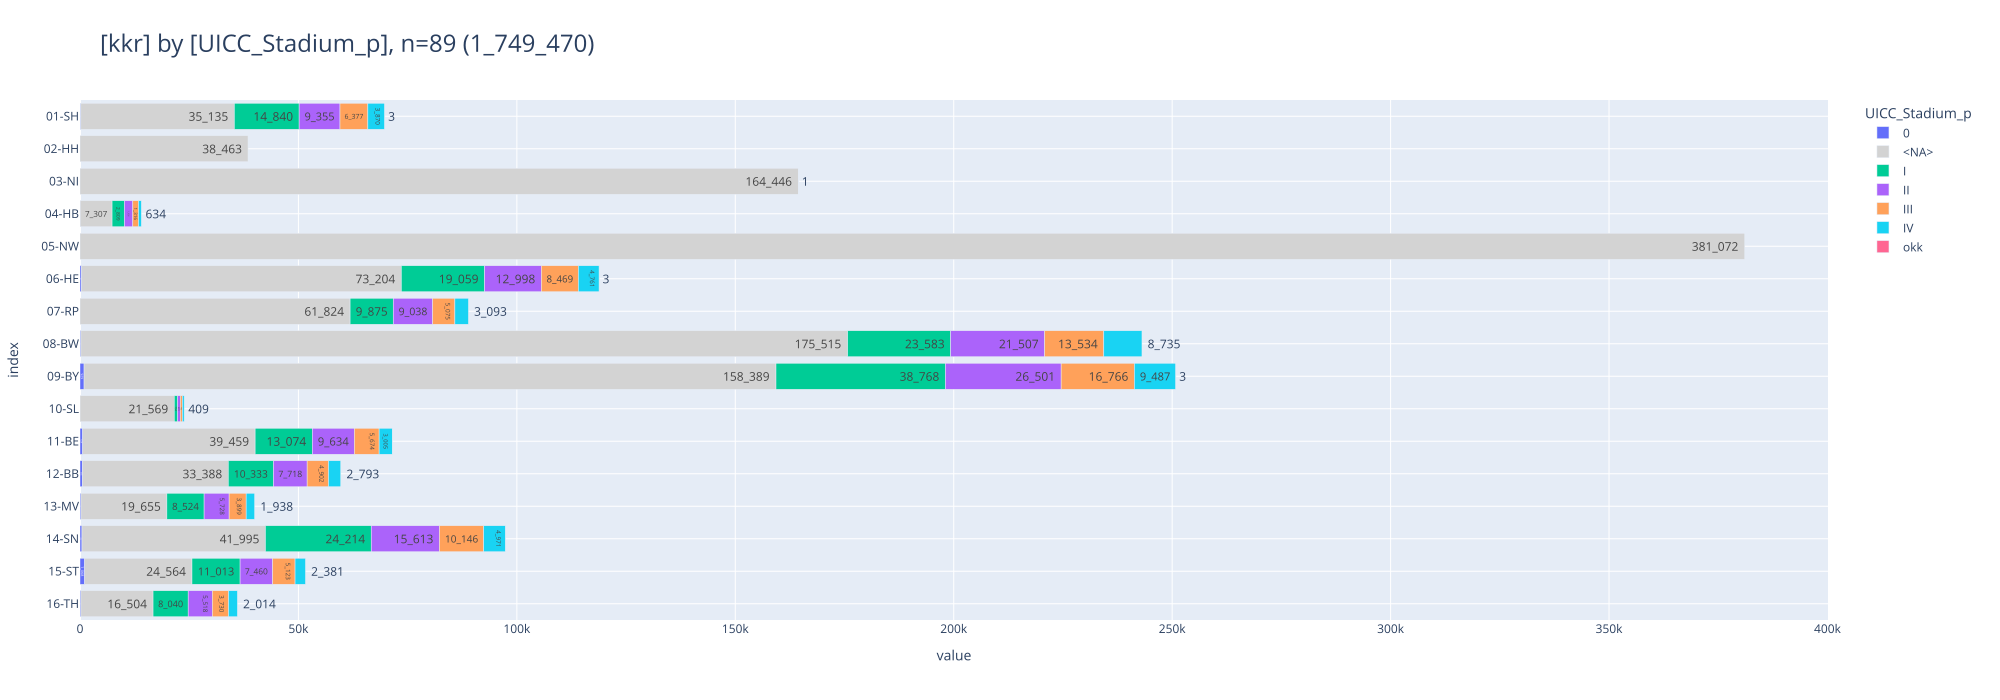

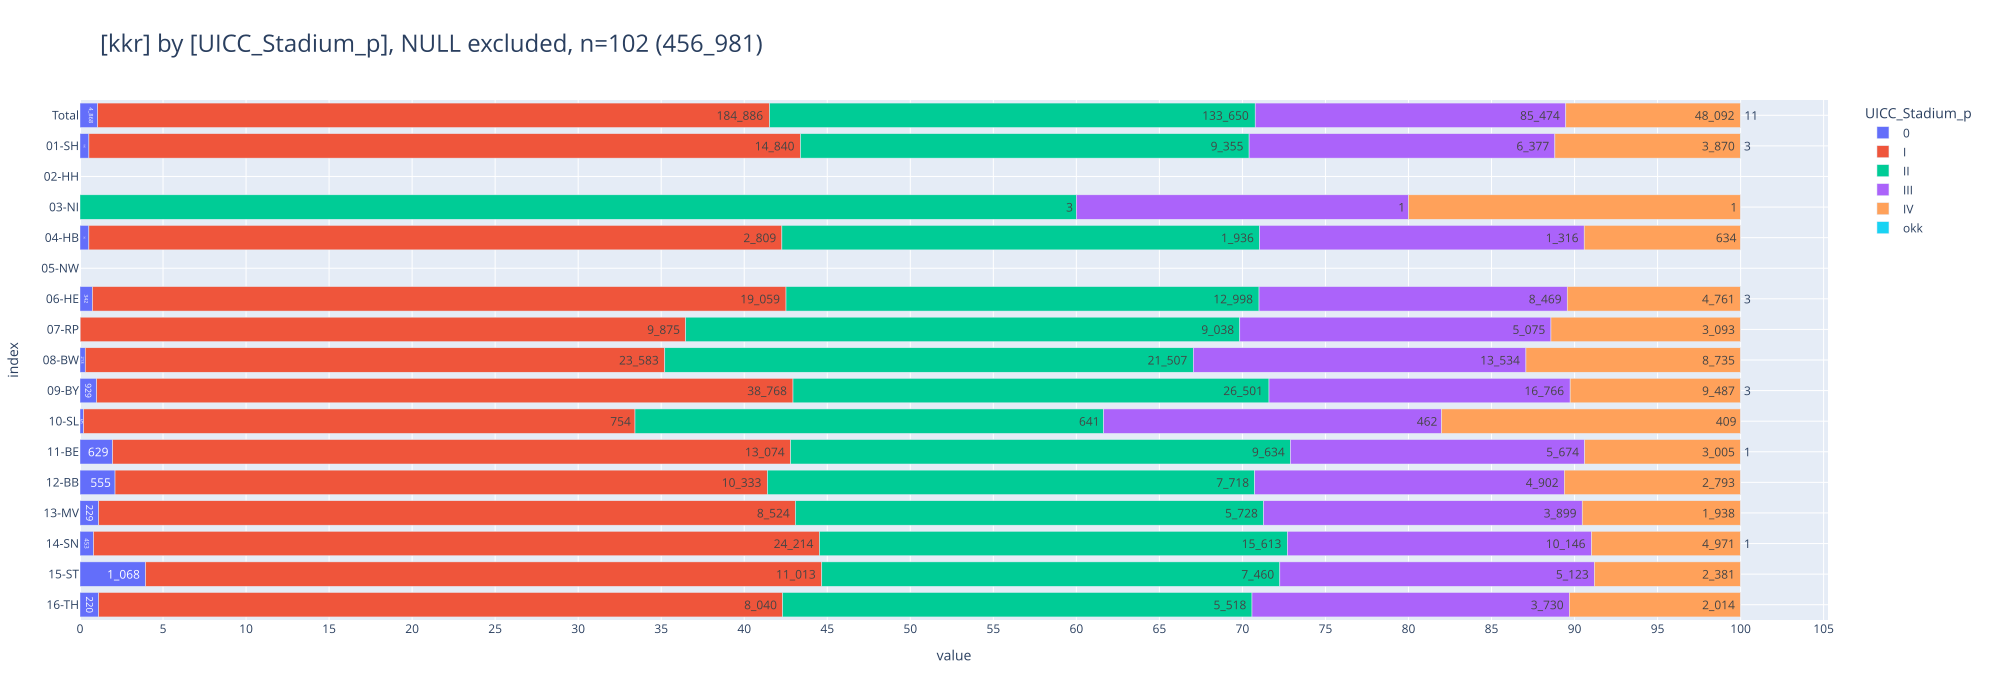

In [18]:
_tu=show_vars(2, grouper_reg.KKR.value, show=False, filter=fil_dy_no_solid_no_dco)
_=pls.plot_stacked_bars(_tu, swap=False, orientation='h', show_total=False, relative=False, height=700)
_=pls.plot_stacked_bars(_tu, swap=False, orientation='h', show_total=True, relative=True, height=700, dropna=True, kkr_col="kkr")

# todo (DCN in klin. epi Fällen für GKR länder) pro DJ

<br>

### <a id='toc1_7_2_'></a>[Diagnosesicherung](#toc0_)
- **Filter: `DJ` = 2020-2023**

> 💡 `NI`: _"Die Ausprägung **DCO als Diagnosesicherung** kommt im KKN-Datensatz nicht vor. Diese Information liegt bisher nur dem EKN vor und wird gegebenenfalls zur Anreicherung von Datenexporten fallspezifisch vom KKN beim EKN angefragt. Der Prozess zur automatisierten Übermittlung dieser Informationen vom EKN zum KKN ist in Planung"_

> 💡 `ZfKD`: _Aufgrund der verschiedenartigen Handhabung von DCO in den übermittelten Daten ist die Filterung nach DCO mit erheblicher Unschärfe verbunden_

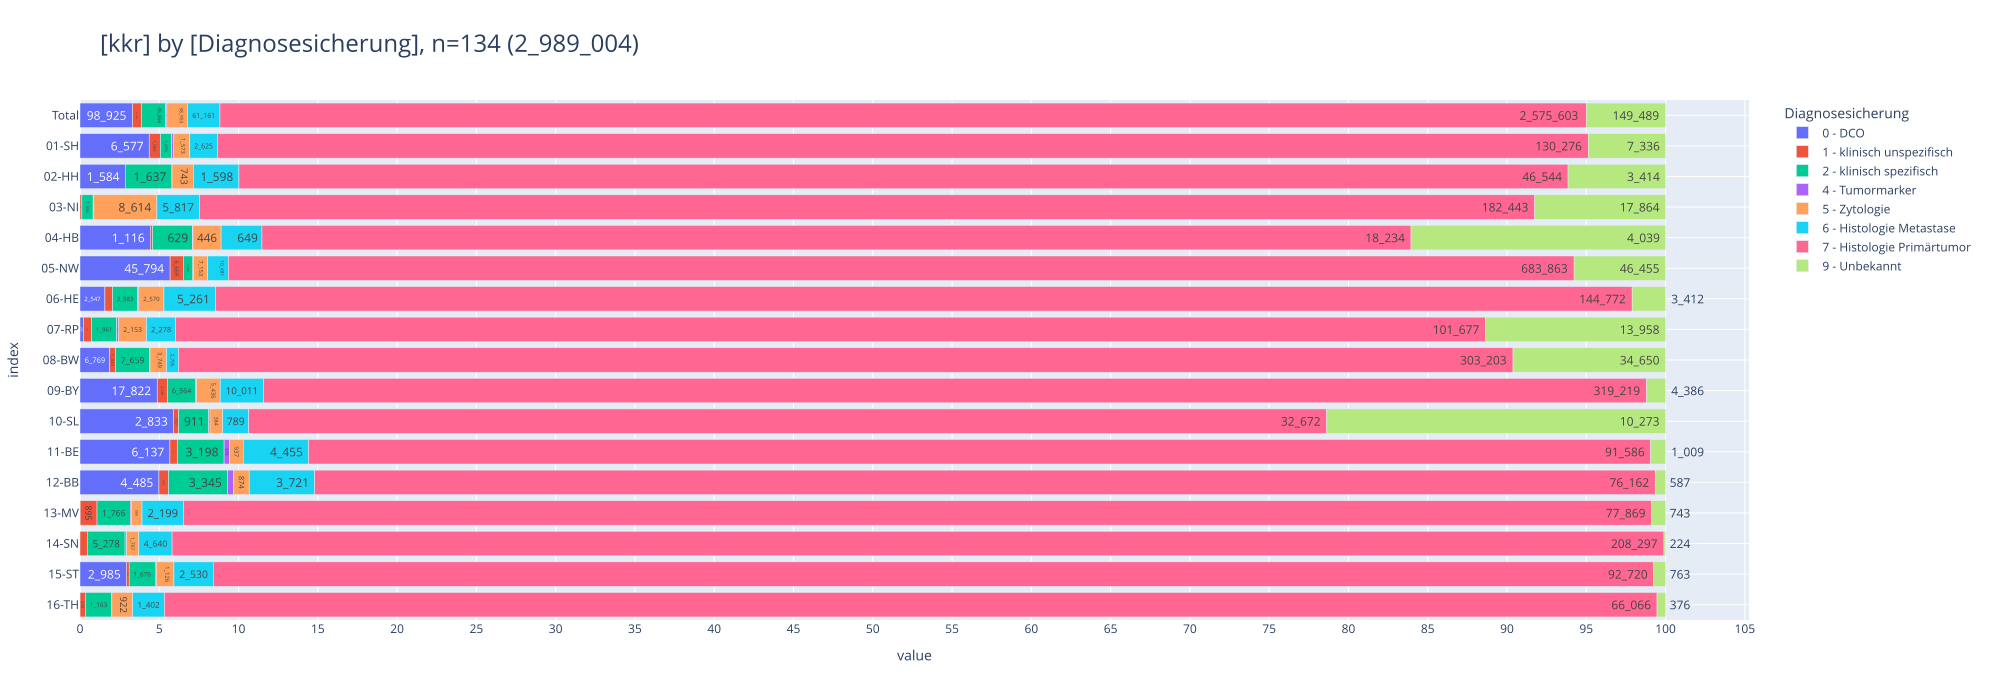

In [19]:
_=show_vars(3, grouper_reg.KKR.value, show=True, filter=fil_dy)

<br>

### <a id='toc1_7_3_'></a>[Geschlecht](#toc0_)
- Grundgesamtheit: Menge aller **Patienten** 
- **Filter: `DJ` = 2020-2023**

> 💡 `ZfKD`: _Angaben zu Geschlecht ungleich `M` oder `W` sind sehr selten, diese Fälle werden nicht gesondert verarbeitet_

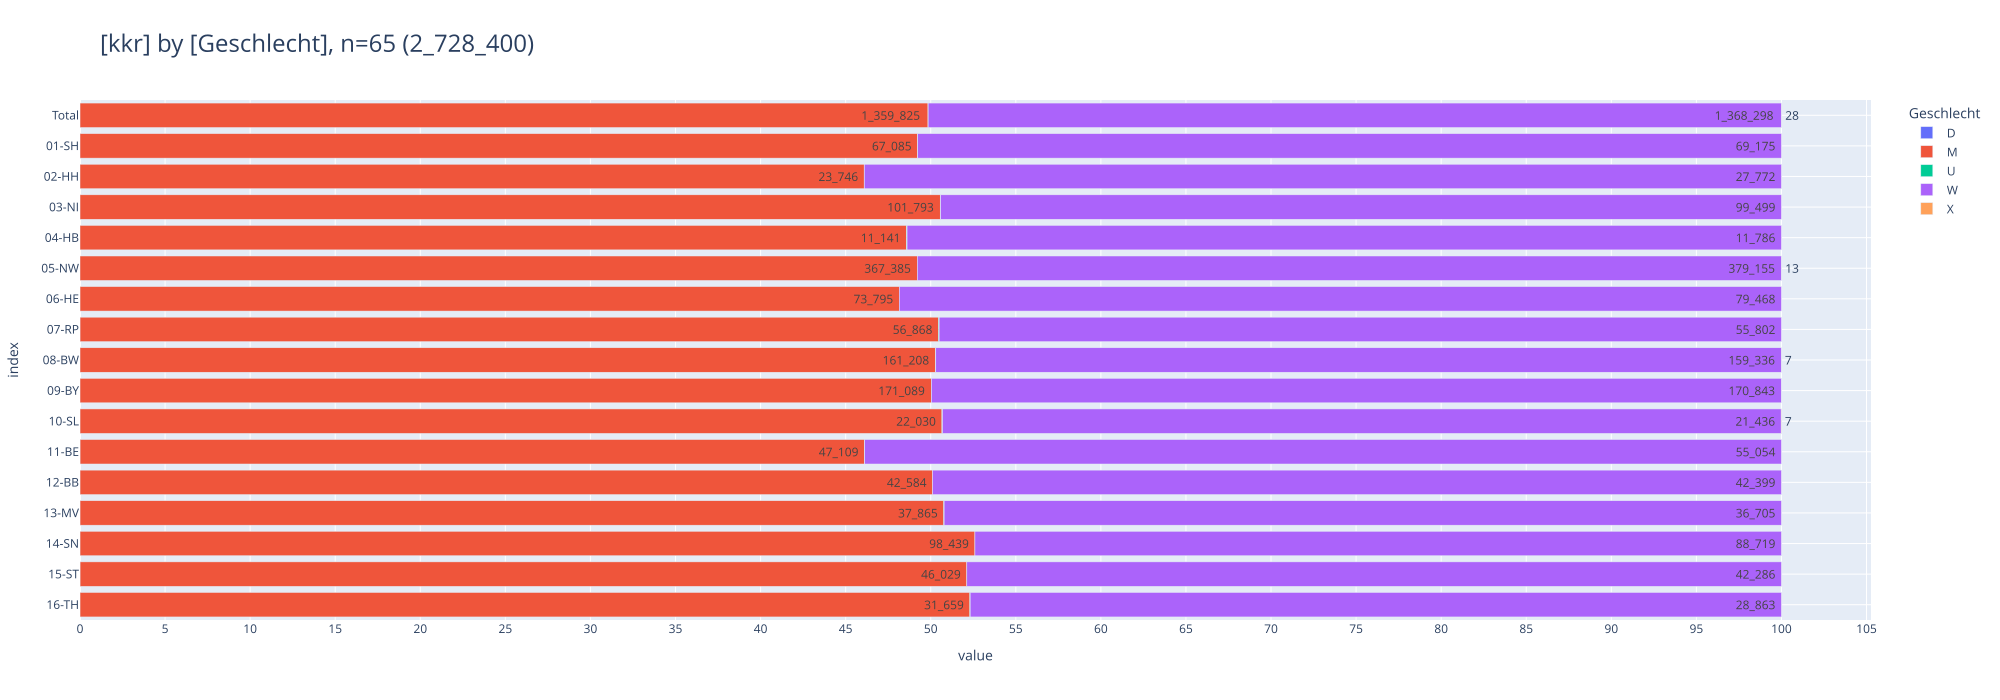

Anzahl Ausprägungen <> M oder W im Gesamtdatensatz: {'D': 37, 'U': 212, 'X': 28}


In [20]:
_tu=show_vars(0, grouper_reg.KKR.value, show=True, filter=fil_dy)
_other = _tu[~_tu["Geschlecht"].isin(["M", "W"])].groupby("Geschlecht")["cnt"].sum().to_dict()
print(f"Anzahl Ausprägungen <> M oder W im Gesamtdatensatz: {_other}")

<br>

### <a id='toc1_7_4_'></a>[Diagnosejahr](#toc0_)
- Filter: Top 5 Diagnosejahre
- Legende ist **absteigend sortiert nach Fallzahl im DJ**, Restkategorie `<other>` ist aufgeführt

Anzahl 2024 Fälle: {'13-MV': 2835, '08-BW': 679, '11-BE': 509, '12-BB': 642, '15-ST': 1917, '09-BY': 2233, '06-HE': 844}


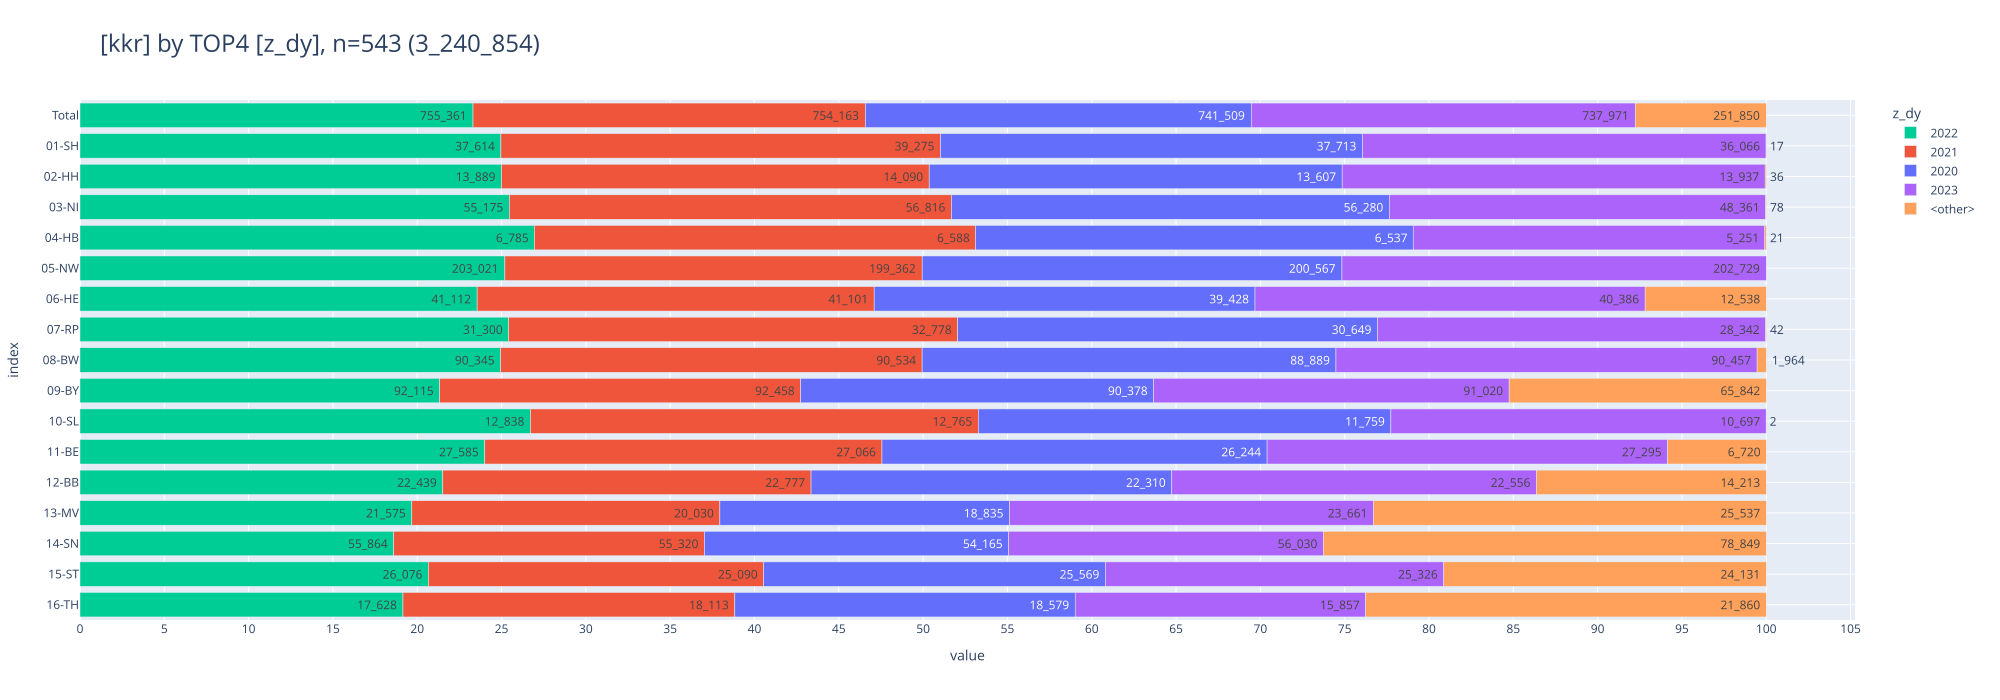

In [21]:
_tu = show_vars(4, grouper_reg.KKR.value, show=False)
print(
    f"Anzahl {str(dy_max+1)} Fälle: {_tu[_tu['z_dy'] == str(dy_max+1)].set_index('kkr')['cnt'].to_dict()}"
)
_ = pls.plot_stacked_bars(
    _tu,
    swap=False,
    orientation="h",
    show_total=True,
    normalize=False,
    relative=True,
    height=700,
    top_n_color=4,
    sort_values_color=True,
    show_other=True,
)

<br>

### <a id='toc1_7_5_'></a>[Inzidenzort vs Lieferregister](#toc0_)
- **Filter: keiner, Grundgesamtheit sind alle Fälle**
- vertikal: `Inzidenzort` (Zeile `00` bündelt alle Fälle mit ungültiger Ortsangabe). horizontal: `Lieferregister`
- Beispiel: `03-NI` liefert zu 100% Fälle aus dem Inzidenzort `03`, `13-MV` liefert 159 Fälle aus `03`
> 💡 `ZfKD`: _Angestrebt ist eine "Diagonale", möglichst nur noch Fallübermittlungen aus dem eigenen Einzugsgebiet, was inzwischen schon besser erreicht ist. ~ 99% der Fälle stammen aus dem liefernden Register_

In [22]:
_tu = show_vars(5, grouper_reg.KKR.value, show=False).rename(columns={"Inzidenzort_BL":"ort"}).fillna(0)
_tu.loc[_tu["ort"]=="","ort"]="00"
_tu.loc[(_tu['ort'].astype(int) < 1) | (_tu['ort'].astype(int) > 16), "ort"]="00"
tbl.show_num_df(_tu.pivot_table(index='ort', columns='kkr', values='cnt', fill_value=0, dropna=False), data_bar_axis="xy", total_axis="xy", total_exclude=True, pct_axis="x")

kkr,01-SH,02-HH,03-NI,04-HB,05-NW,06-HE,07-RP,08-BW,09-BY,10-SL,11-BE,12-BB,13-MV,14-SN,15-ST,16-TH,Total
ort,,,,,,,,,,,,,,,,,
00,0,0,0,0,0,1 (0.0%),0,0,4 (0.0%),0,1 (0.0%),36 (0.0%),497 (0.5%),0,0,0,539 (0.0%)
01,150_685 (100.0%),0,0,0,0,0,0,0,0,0,0,7 (0.0%),29 (0.0%),1 (0.0%),0,0,150_722 (4.7%)
02,0,55_559 (100.0%),0,0,0,0,0,0,0,0,0,0,2 (0.0%),4 (0.0%),0,0,55_565 (1.7%)
03,0,0,216_710 (100.0%),0,0,238 (0.1%),0,0,0,0,1 (0.0%),0,226 (0.2%),3 (0.0%),0,0,217_178 (6.7%)
04,0,0,0,25_182 (100.0%),0,0,0,0,0,0,0,0,0,0,0,0,25_182 (0.8%)
05,0,0,0,0,805_679 (100.0%),100 (0.1%),0,0,0,0,0,1 (0.0%),0,8 (0.0%),0,0,805_788 (24.9%)
06,0,0,0,0,0,174_121 (99.7%),0,0,1 (0.0%),0,0,0,0,8 (0.0%),78 (0.1%),0,174_208 (5.4%)
07,0,0,0,0,0,3 (0.0%),123_111 (100.0%),0,1 (0.0%),0,0,0,0,4 (0.0%),0,0,123_119 (3.8%)
08,0,0,0,0,0,10 (0.0%),0,362_189 (100.0%),269 (0.1%),0,0,0,6 (0.0%),6 (0.0%),0,0,362_480 (11.2%)


<br>

### <a id='toc1_7_6_'></a>[ICD10 Gruppen](#toc0_)
- die verwendete ICD10 Skala entspricht der Darstellung aus *"Krebs in Deutschland"*
> 💡 `NI`: _"Für nicht-melanozytäre Hautkrebsarten bestimmter Histologien sowie fortgeschrittene Plattenepithelkarzinome gilt ab dem 20. September 2023 eine geänderte Meldepflicht. Erst seit diesem Zeitpunkt sind die prognostisch ungünstigen Hauttumore **(C44)** an das KKN zu melden und kommen daher im gelieferten Datensatz bisher nicht vor. In den nächsten Lieferungen werden diese Daten enthalten sein"_

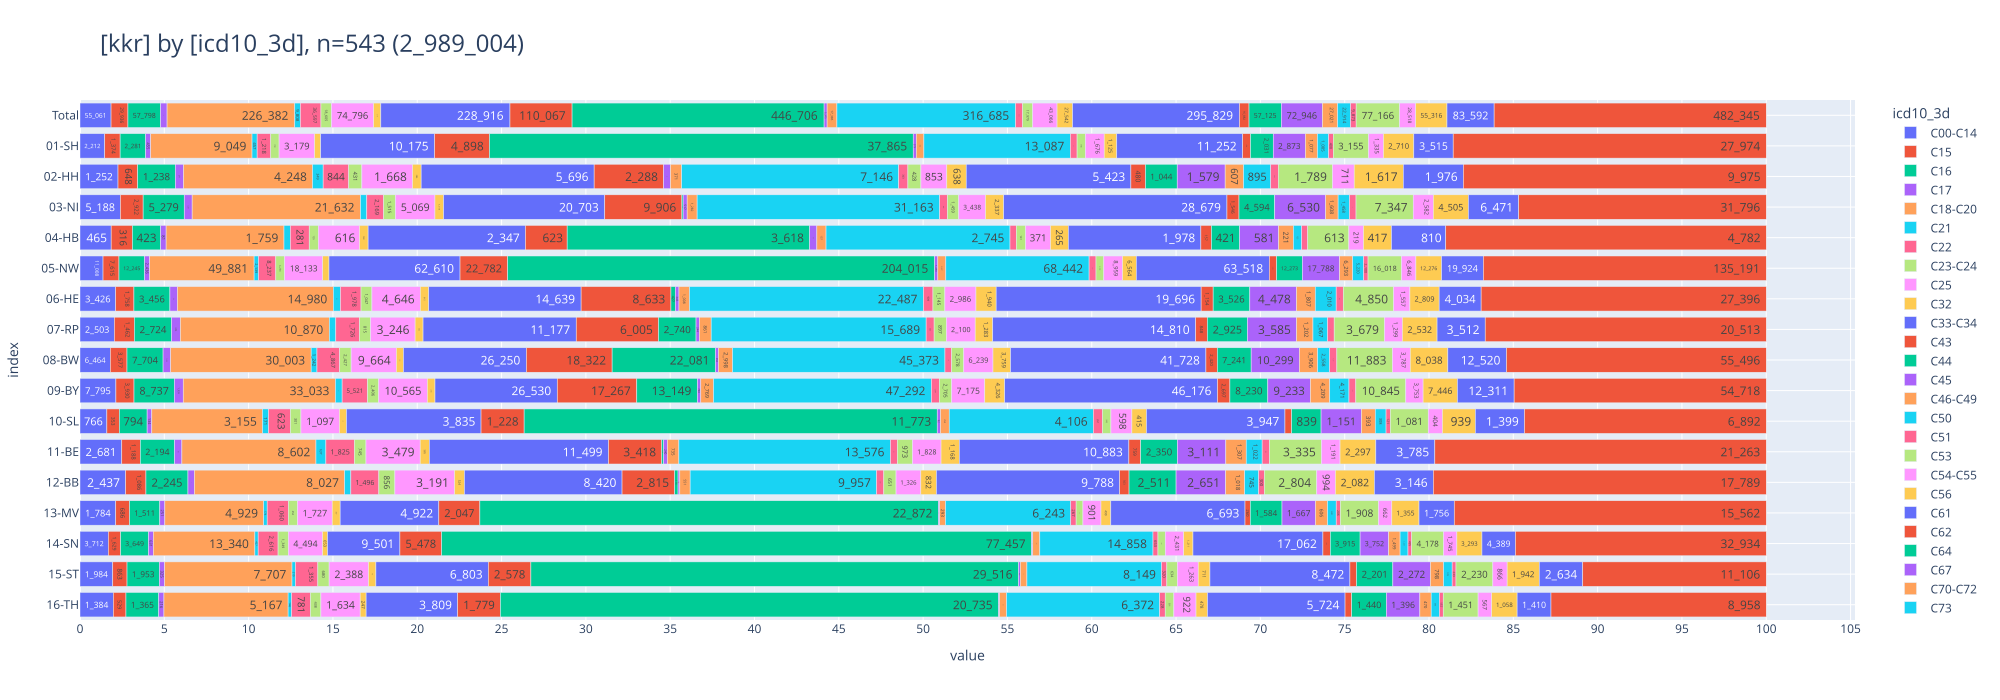

In [23]:
_=show_vars(6, grouper_reg.KKR.value, show=True, filter=fil_dy)

<br>

### <a id='toc1_7_7_'></a>[Verstorben](#toc0_)

- **Filter: `DJ` = 2020-2023, `DCO` = N, `ICD10` != C44**

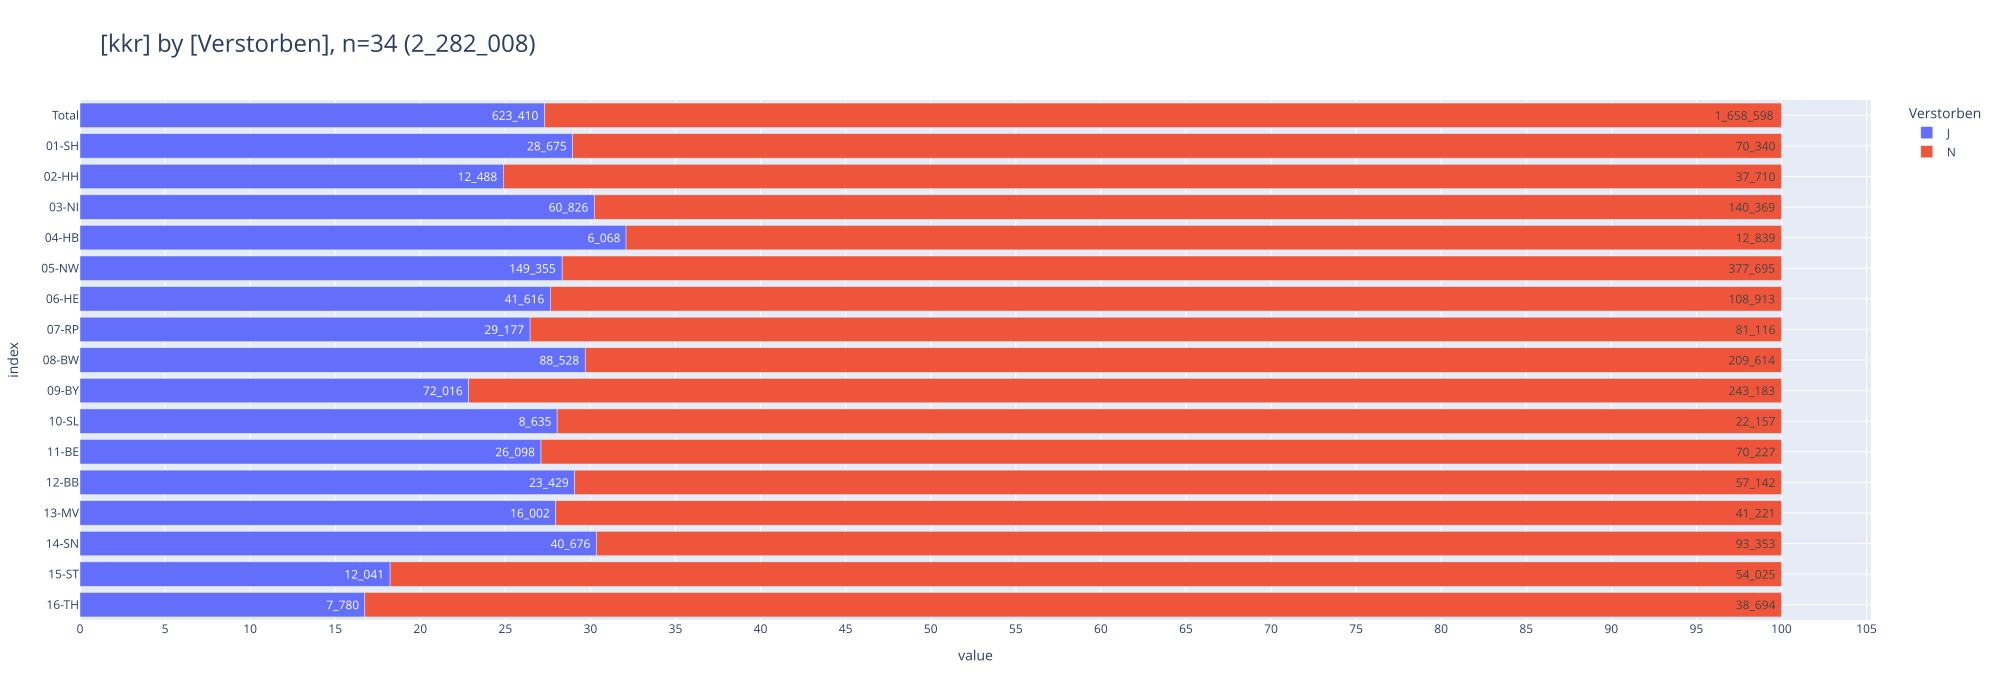

In [24]:
_=show_vars(1, grouper_reg.KKR.value, show=True, filter=f"z_dy > 2019 and z_dy <= {dy_max} and icd10_3d != 'C44' and not z_is_dco")

<br>

### <a id='toc1_7_8_'></a>[TNM-T (p)](#toc0_)
- **Filter: `DJ` = 2020-2023, `DCO` = N, `ICD10` nur solide Tumoren** (_solide Tumoren_ schliesst folgende Diagnosen _aus_: C44, C70-C72, C76-C97, alle D)

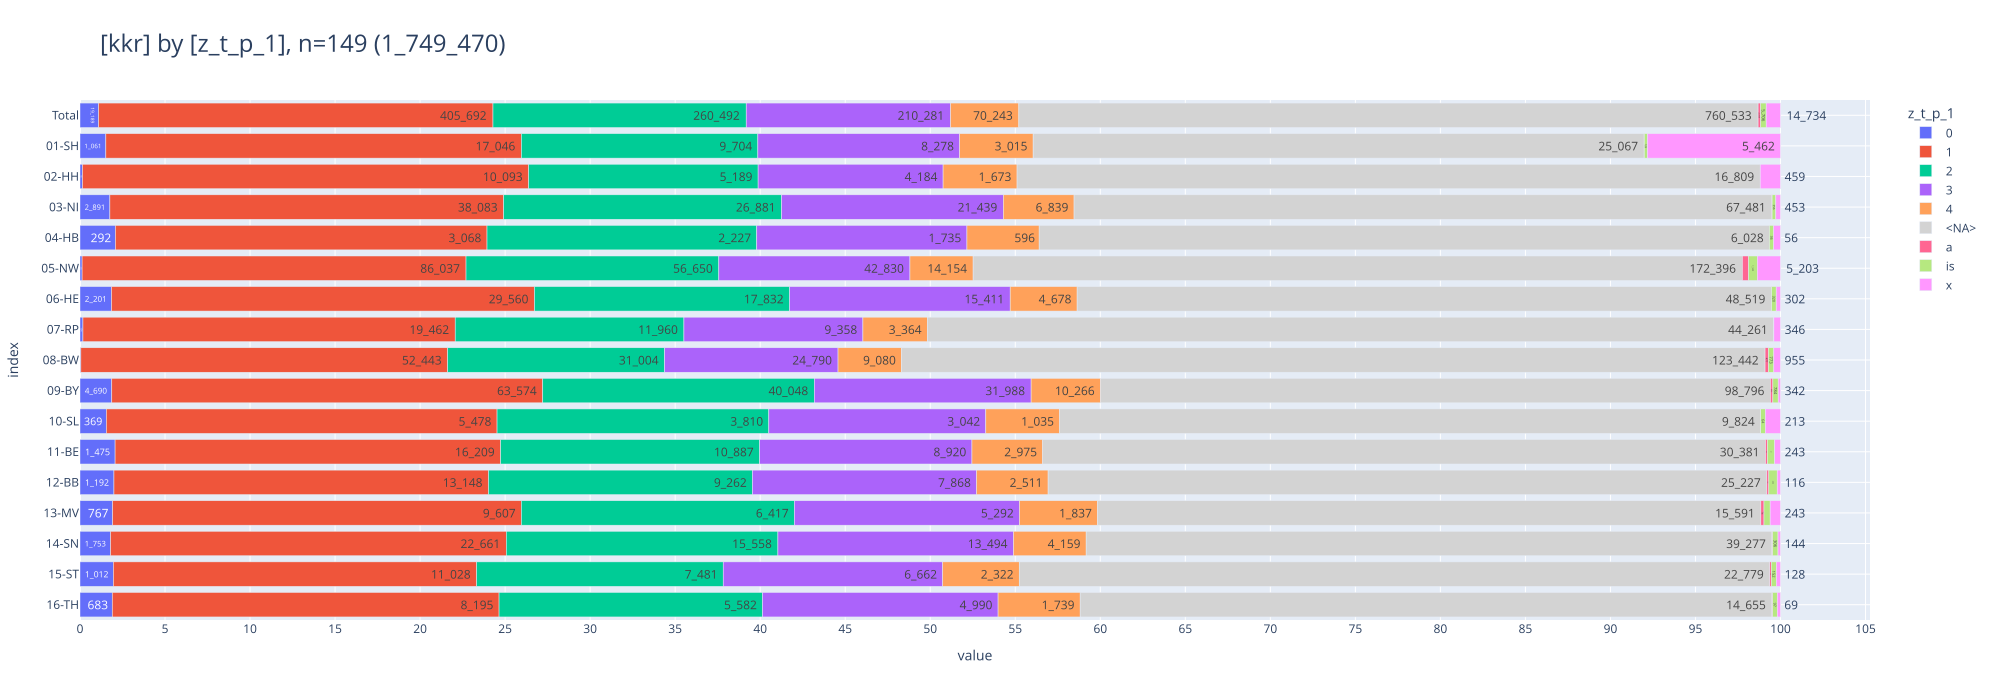

In [25]:
_=show_vars(9, grouper_reg.KKR.value, show=True, filter=fil_dy_no_solid_no_dco)

<br>

### <a id='toc1_7_9_'></a>[TNM-N (p)](#toc0_)
- **Filter: `DJ` = 2020-2023, `DCO` = N, `ICD10` nur solide Tumoren** (_solide Tumoren_ schliesst folgende Diagnosen _aus_: C44, C70-C72, C76-C97, alle D)


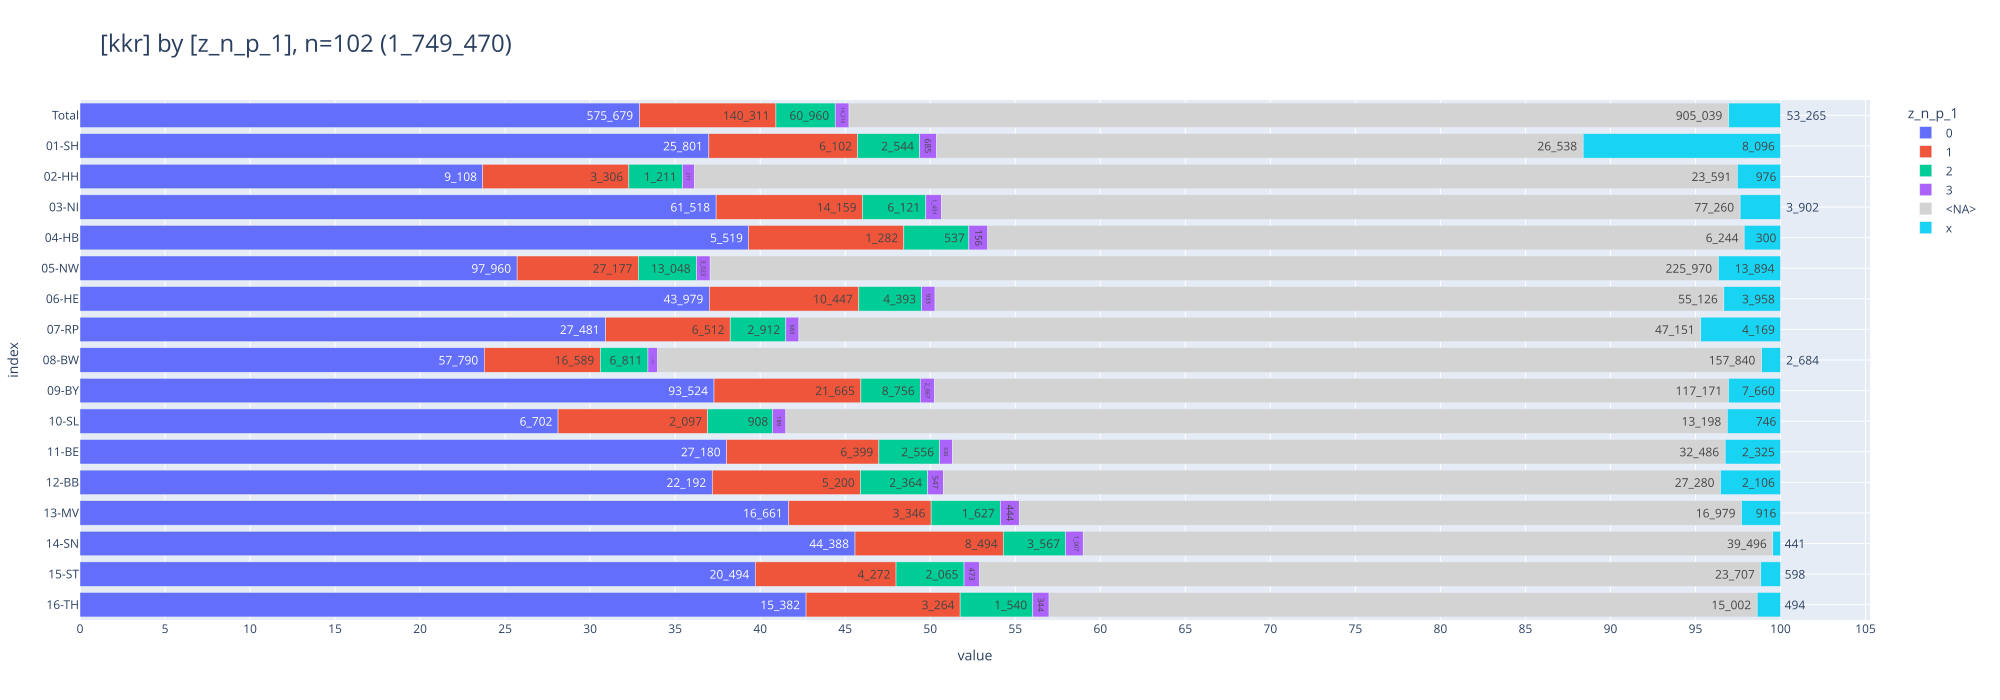

In [26]:
_=show_vars(11, grouper_reg.KKR.value, show=True, filter=fil_dy_no_solid_no_dco)

<br>

### <a id='toc1_7_10_'></a>[TNM-M (p)](#toc0_)
- **Filter: `DJ` = 2020-2023, `DCO` = N, `ICD10` nur solide Tumoren**

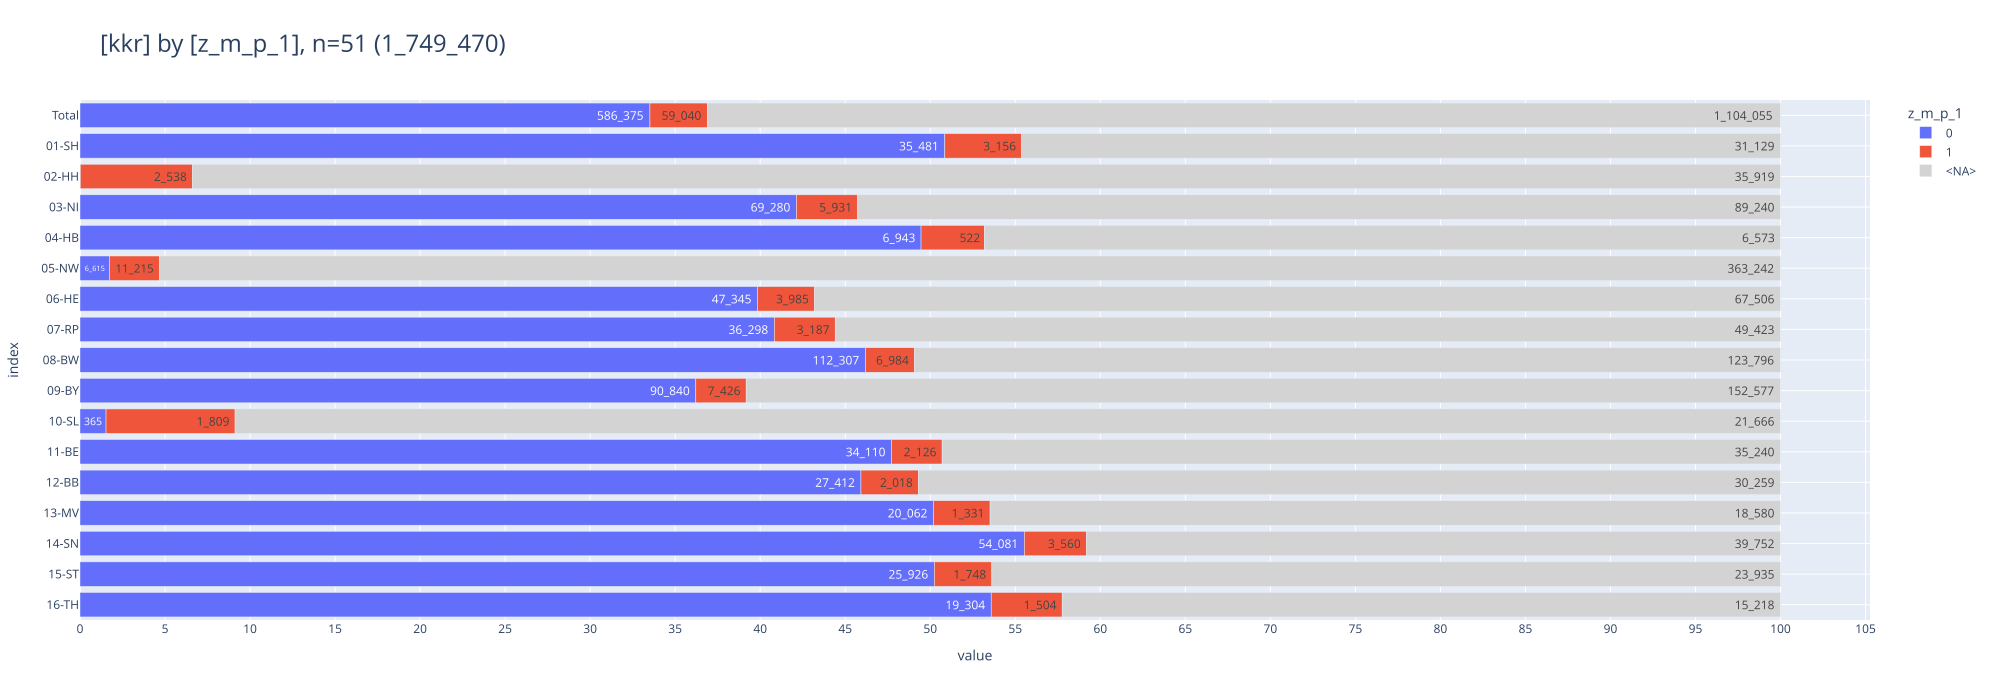

In [27]:
_=show_vars(12, grouper_reg.KKR.value, show=True, filter=fil_dy_no_solid_no_dco)

<br>

### <a id='toc1_7_11_'></a>[TNM-Auflage (p)](#toc0_)

- **Filter: `DJ` = 2020-2023**

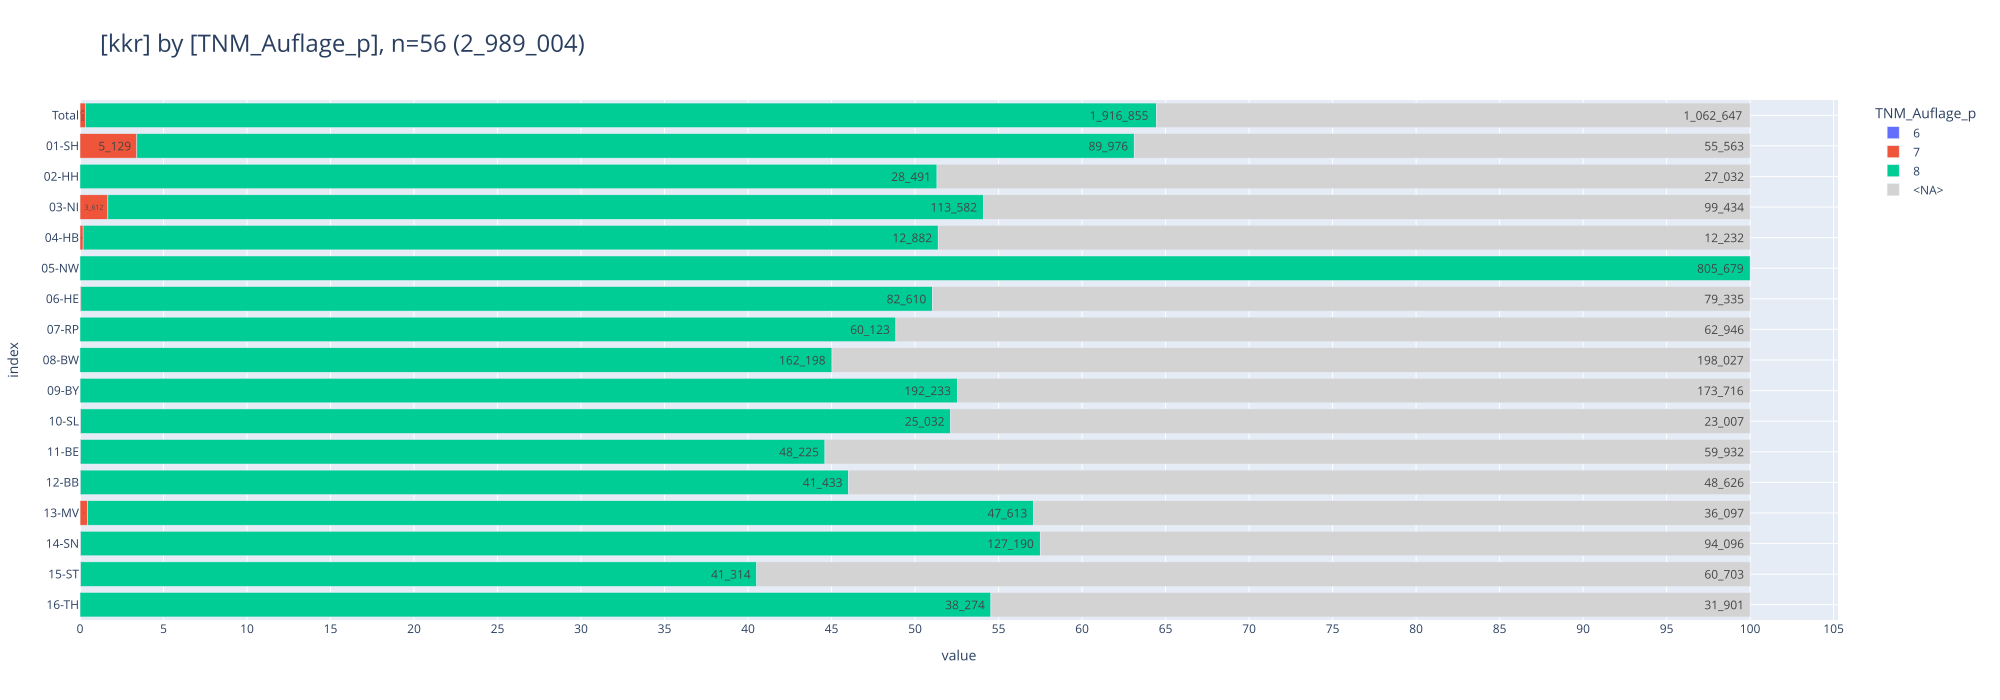

In [28]:
_=show_vars(8, grouper_reg.KKR.value, show=True, filter=fil_dy)

<br>

### <a id='toc1_7_12_'></a>[Todesursachen (TU)](#toc0_)

#### <a id='toc1_7_12_1_'></a>[nach ICD10 Einstellern](#toc0_)
- gezählt sind die ersten Stellen aller TU Codes ohne jeglichen Filter

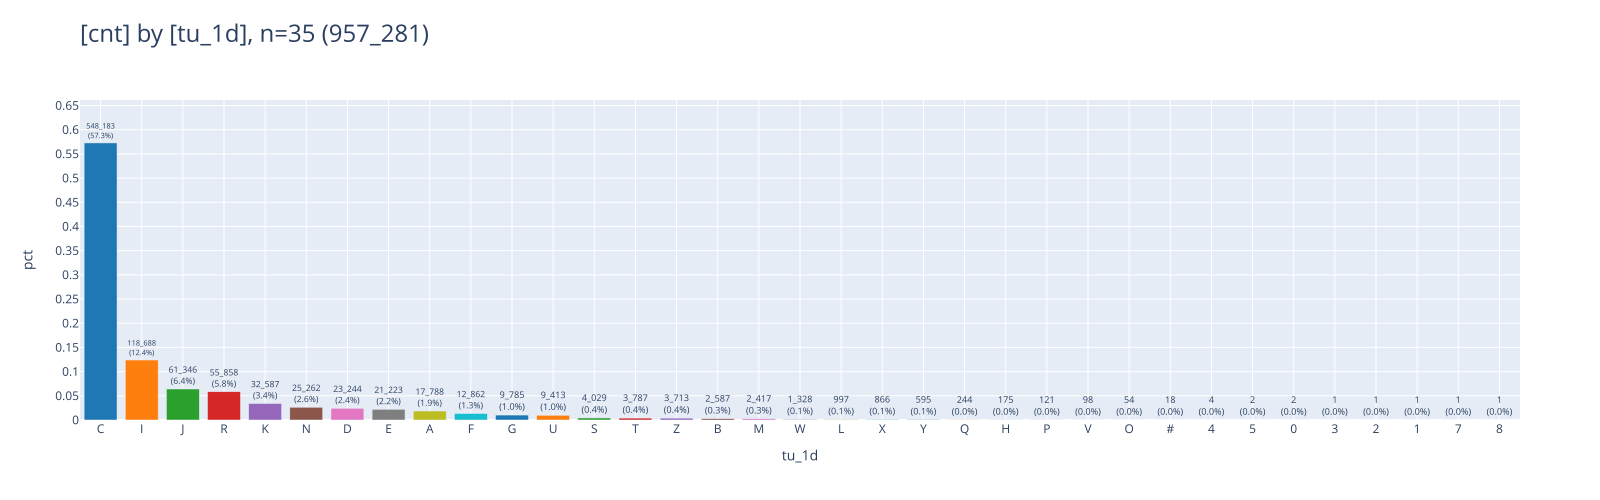

In [29]:
db_tu = Todesursache.project("*, upper(substr(Code, 1,1)) as tu_1d")
_=pls.plot_bars(db_tu.aggregate("tu_1d, count(*) as cnt").to_df(), orientation='v', sort_values=True, height=500,)

#### <a id='toc1_7_12_2_'></a>[nach Sterbejahr und Todesursachen](#toc0_)
- gezählt werden **Personen**
- **Filter: `SJ`= 2020-2023, `Verstorben` = J**
- `tu_type` Art der TU pro Patient
  - `<NA>` keine Todesursache
  - `C` Todesursache Cxx
  - `<other>` andere Todesursache

> 💡 `ZfKD`: _"`03-NI` und `06-HE` übermitteln deutlich weniger Todesursachen asl in den epi Daten, für `07-RP` ist der Anteil in beiden Datenräumen gering. Für `15-ST` sind auffällig wenige Todesfälle in 2023 übermittelt."_

In [30]:
# # * get list of all patient and their first TU
_tu = (Patient.set_alias("p")
    .join(Todesursache, "oBDS_RKIPatientId", "inner")
    .aggregate("p.oBDS_RKIPatientId, min(Code) as code")
)
# _tu

In [31]:

db_tu=(
    Patient
    .join(_tu, "oBDS_RKIPatientId", "left")
    .join(Tumor, "oBDS_RKIPatientId", "left")
    .filter(f"year(Datum_Vitalstatus::date) between 2020 and {dy_max} and Verstorben='J'")
    .project("""--sql
            --z_dy 
            year(Datum_Vitalstatus::date) as SJ
            --,left(code,3) as tu
            ,case 
                when left(code,1)='C' then 'C' 
                when left(code,1)<>'C' then '<other>' 
                else null end as tu_type
            ,z_kkr_label
    """)
)
df_tu = db_tu.to_df()
# 974_056

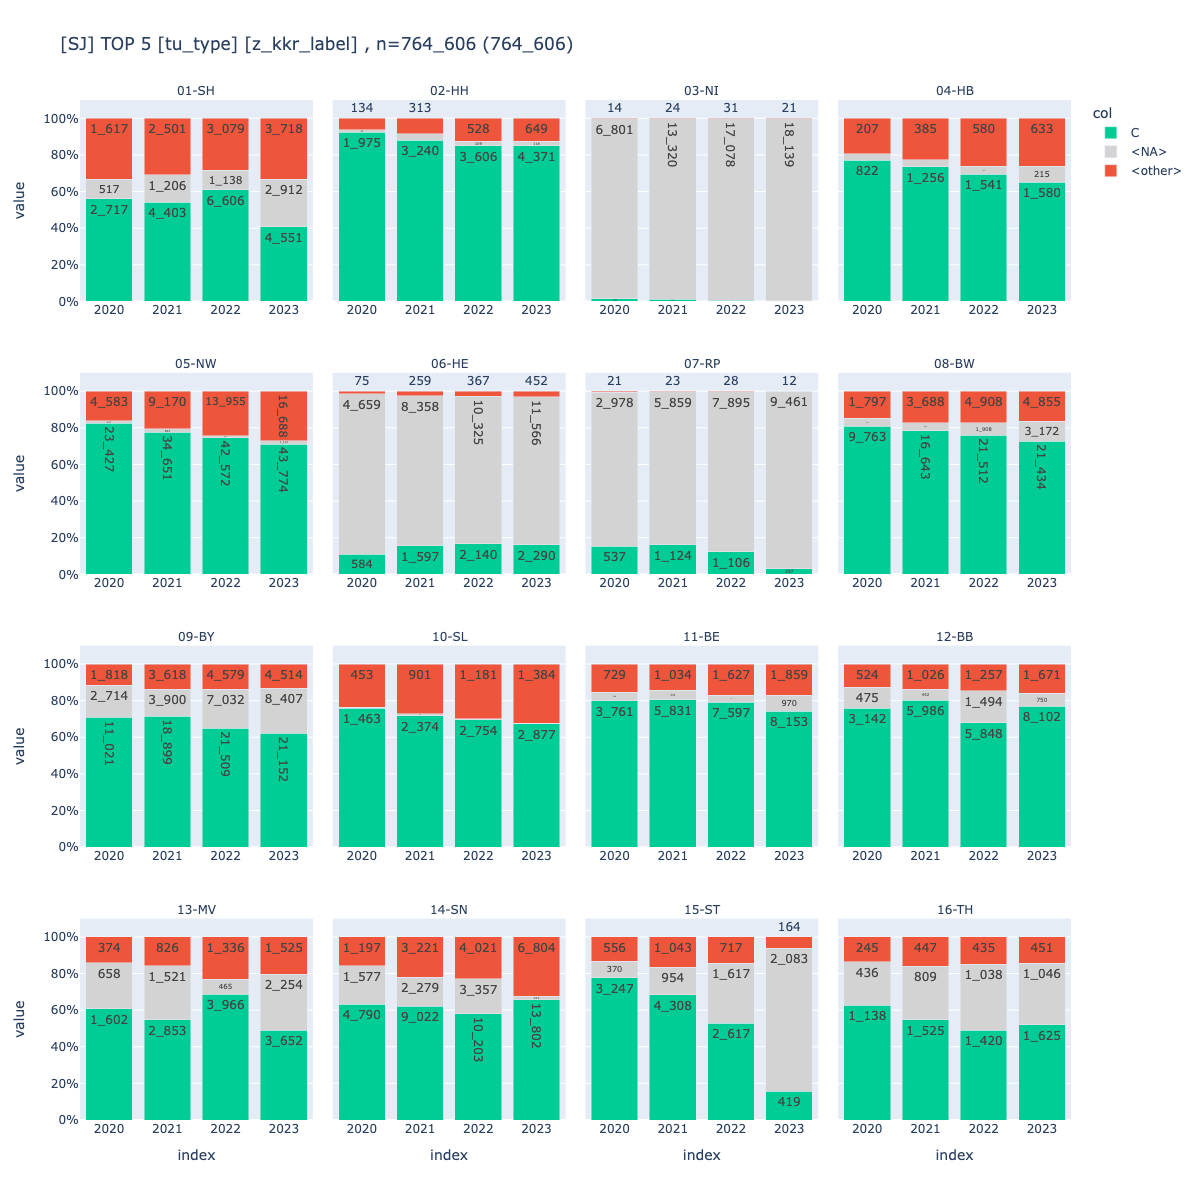

In [32]:
_ = pls.plot_facet_stacked_bars(
    df_tu,
    subplots_per_row=4,
    top_n_color=5,
    sort_values_color=True,
    show_other=False,
    relative=True,
    annotations=True
)

<br>

#### <a id='toc1_7_12_3_'></a>[nach hat_todesursache bei Nicht-Verstorbenen](#toc0_)
- gezählt werden **Personen**
- **Filter: `Verstorben` = N**

> 💡 `HH`: _"Da haben wir jetzt gesehen, dass es an dem Überhang-Konstrukt liegt. Da handelt es sich um Patienten, die im Datenlieferungszeitraum <31.12.2022 noch gelebt haben, aber dann innerhalb des Zeitraums zur Erstellung des Datensatzes (01.02.2024) verstorben sind. Da passen wir unseren Datenexport noch einmal an."_

In [33]:
_pat = Patient.filter("Verstorben='N'").project("oBDS_RKIPatientId")
_df = (Todesursache
    .join(_pat, "oBDS_RKIPatientId")
    .aggregate("z_kkr, count(distinct oBDS_RKIPatientId) as has_tu")
    .join(dim_lieferregister, "z_kkr::int=code::int", "right")
    .project("kkr, has_tu")
    .order("kkr")
    .to_df().set_index("kkr").fillna(0)
    .T
)
tbl.show_num_df(_df, total_axis="", heatmap_axis="x")

kkr,01-SH,02-HH,03-NI,04-HB,05-NW,06-HE,07-RP,08-BW,09-BY,10-SL,11-BE,12-BB,13-MV,14-SN,15-ST,16-TH,Total
has_tu,0,980,0,0,0,0,0,0,1,8,1,5,472,0,0,3,0


<br>

#### <a id='toc1_7_12_4_'></a>[nach ICD10 Dreistellern (TOP 5)](#toc0_)
- Grundgesamtheit: alle **Todesursachen**, kein Filter

> 💡 `ZfKD`: _Enthalten sind in einigen KKR auch `C79` (Metastasen), welche in offizieller Todesursachen-Statistik nicht kodiert sind_

In [34]:
_tu = (
    Todesursache.aggregate("z_kkr, left(Code,3) as tu_3d, count(*) as cnt")
    .join(dim_lieferregister, "z_kkr::int = code::int")
    .project("tu_3d,kkr, cnt")
    .to_df()
    # .pivot_table(index='tu_3d', columns='kkr', values='cnt', fill_value=0, dropna=False)
)
# tbl.show_num_df(_df, data_bar_axis="xy", total_axis="xy", total_exclude=True, pct_axis="x",)
tbl.pivot_df(_tu, top_n_index=5, data_bar_axis="xy", pct_axis="", swap=False, heatmap_axis="", total_axis="y")

kkr,01-SH,02-HH,03-NI,04-HB,05-NW,06-HE,07-RP,08-BW,09-BY,10-SL,11-BE,12-BB,13-MV,14-SN,15-ST,16-TH,Total
tu_3d,,,,,,,,,,,,,,,,,
C18,974,794,15,259,8_683,121,257,4_522,5_709,520,1_862,1_765,924,3_038,746,363,30_552
C25,1_740,1_209,29,423,13_927,196,353,7_329,7_380,744,3_207,2_736,1_566,4_300,966,584,46_689
C34,4_533,3_335,85,1_299,36_471,776,935,14_222,14_437,2_068,8_296,6_121,3_621,7_126,2_047,1_246,106_618
C78,0,0,0,0,190,2_338,1_462,0,6_731,0,4_476,4_035,1_948,6_013,1_373,921,29_487
C79,0,0,0,0,166,2_703,1_984,0,19_442,0,3_804,2_294,1_184,3_536,715,405,36_233


<br>

#### <a id='toc1_7_12_5_'></a>[nach IsGrundleiden](#toc0_)
- Grundgesamtheit: **alle Todesursachen**

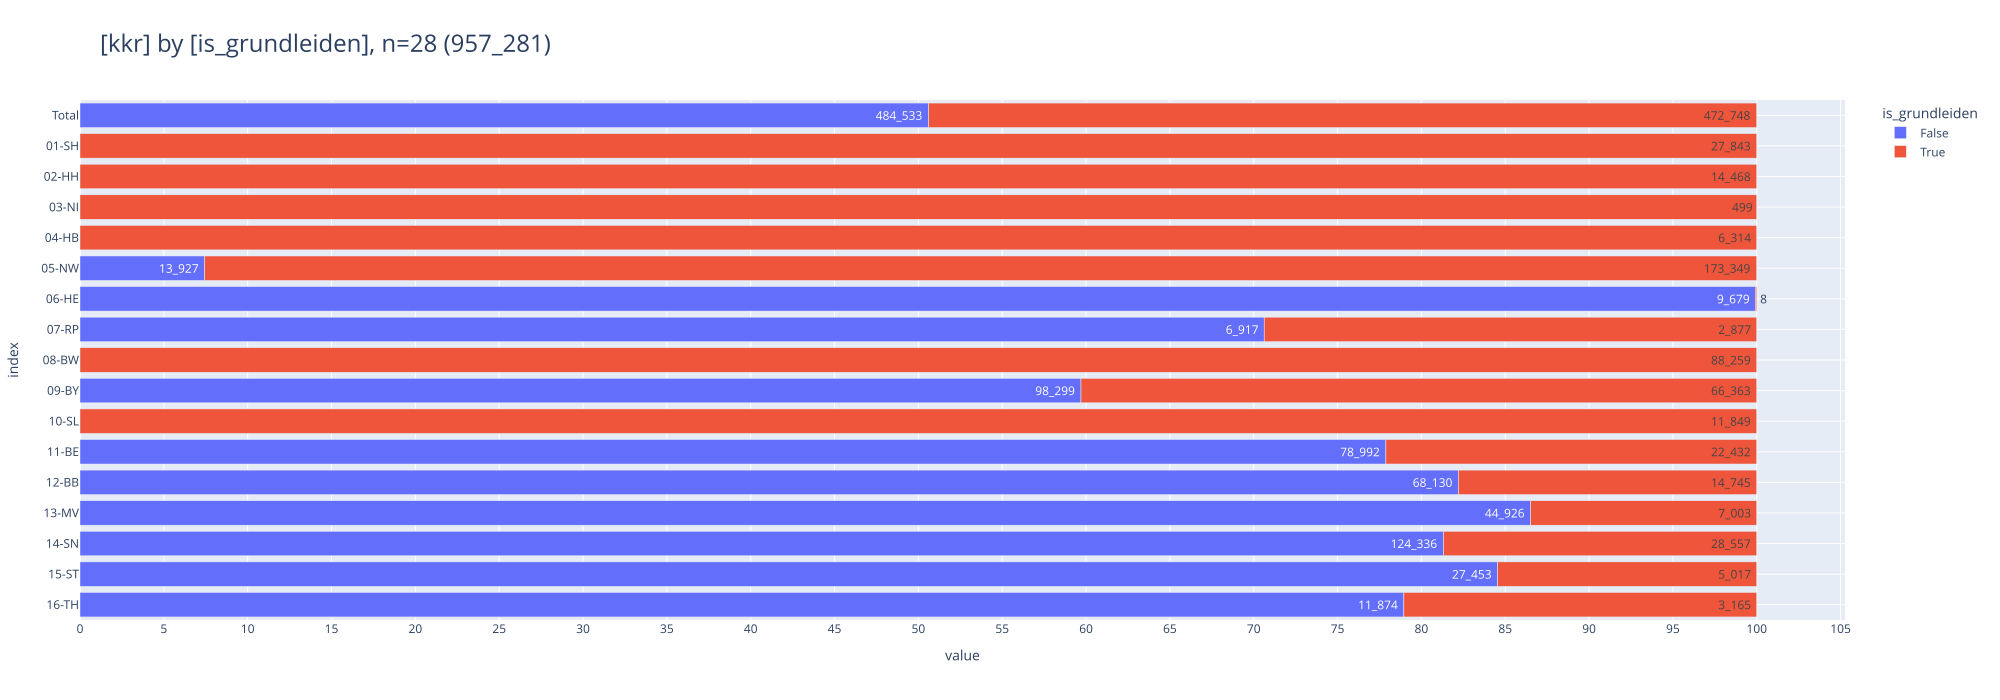

In [35]:
_tu = (
    Todesursache.aggregate(
        "z_kkr, cast(IsGrundleiden as bool) as is_grundleiden, count(*) as cnt"
    )
    .join(dim_lieferregister, "z_kkr::int = code::int")
    .project("kkr, is_grundleiden, cnt")
    .to_df()
)
_=pls.plot_stacked_bars(_tu, orientation="h", height=700, relative=True, show_total=True)

<br>

### <a id='toc1_7_13_'></a>[OP](#toc0_)


#### <a id='toc1_7_13_1_'></a>[nach ICD10](#toc0_)
- Grundgesamtheit: alle **OP Meldungen**

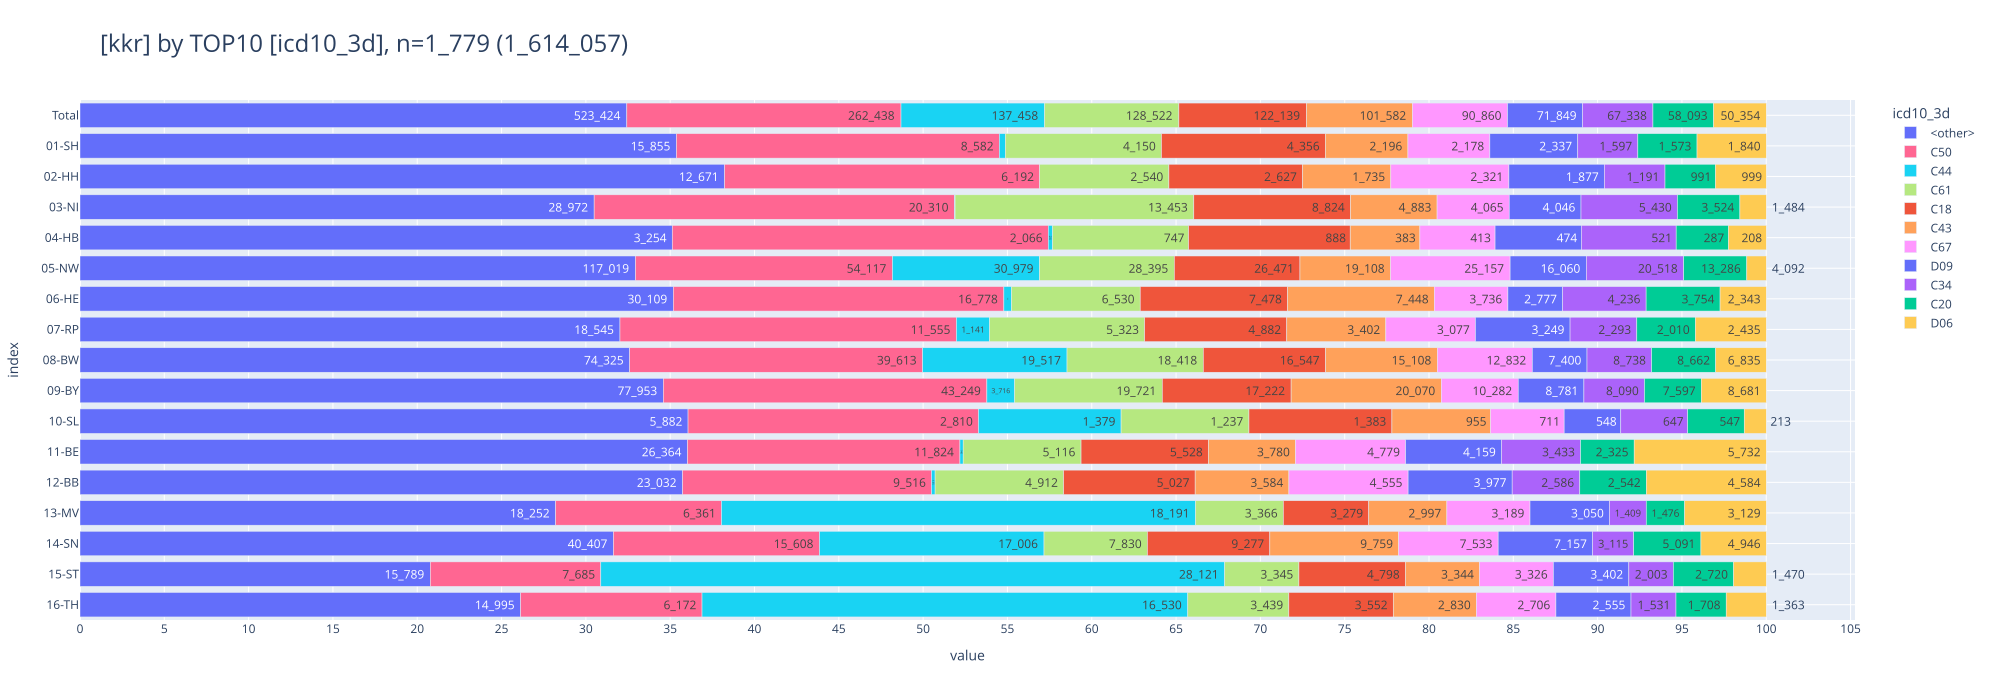

In [36]:
_op = (OP
    .join(Tumor
        .set_alias("t")
        .project("*, left(Diagnose_ICD10_Code,3) as icd10_3d"), 
        "z_tum_id")
    .filter(fil_dy)
    .aggregate("icd10_3d, t.z_kkr, count(*) as cnt")
    .join(dim_lieferregister, "z_kkr::int = code::int")
    .project("kkr, icd10_3d, cnt")
    .to_df()
    )
_=pls.plot_stacked_bars(_op, orientation="h", height=700, top_n_color=10, relative=True, sort_values_color=True, show_other=True, show_total=True)

<br>

#### <a id='toc1_7_13_2_'></a>[nach Intention](#toc0_)
- Grundgesamtheit: alle **OP Meldungen**

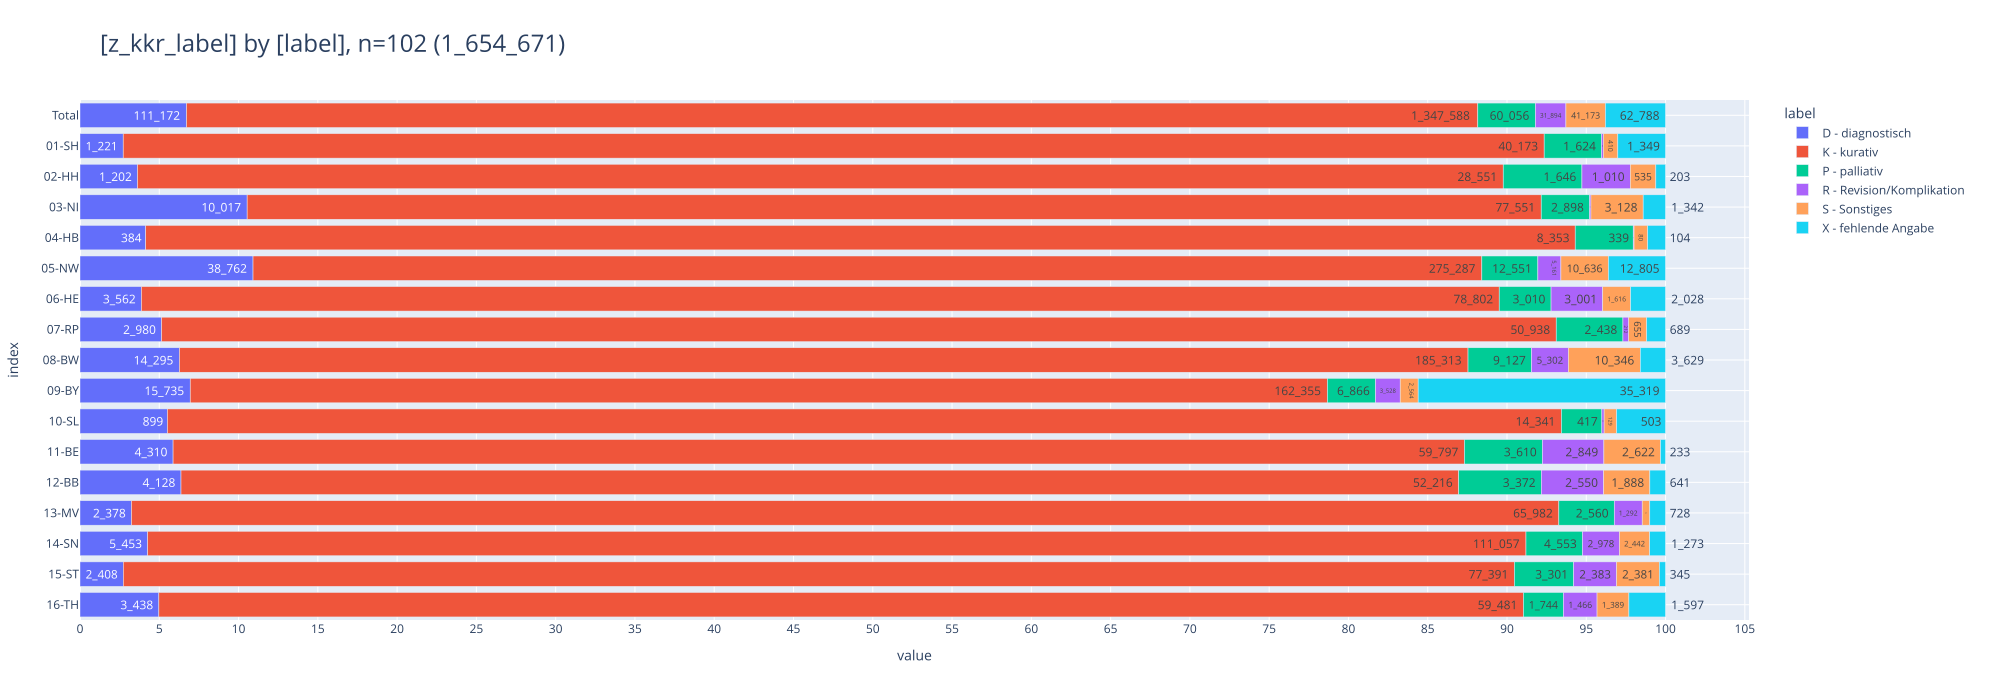

In [37]:
_op = (OP
    .join(Tumor.set_alias("t"), "z_tum_id")
    .aggregate("Intention, t.z_kkr_label, count(*) as cnt")
    .join(dim_op_intention.set_alias("i"), "Intention=i.code")
    .project("z_kkr_label,concat(i.code, ' -  ', i.name) as label, cnt")
    .to_df()
    )
_=pls.plot_stacked_bars(_op, orientation="h", height=700, top_n_color=0, relative=True, show_total=True)

<br>

### <a id='toc1_7_14_'></a>[OPS](#toc0_)


#### <a id='toc1_7_14_1_'></a>[nach OPS ICD Kapitel (Top 10)](#toc0_)
- Grundgesamtheit: **alle OPS Codes**

> 💡 `ZfKD`: _Lediglich `02-HH` und `05-NW` übermitteln ausschliesslich Kapitel 5. Der Anteil von Meldungen <> Kapitel 5 sind wahrscheinlich diagnostische Massnahmen oder nicht-operative Therapien. Vorschlag: nur noch Kapitel 5 übermitteln_

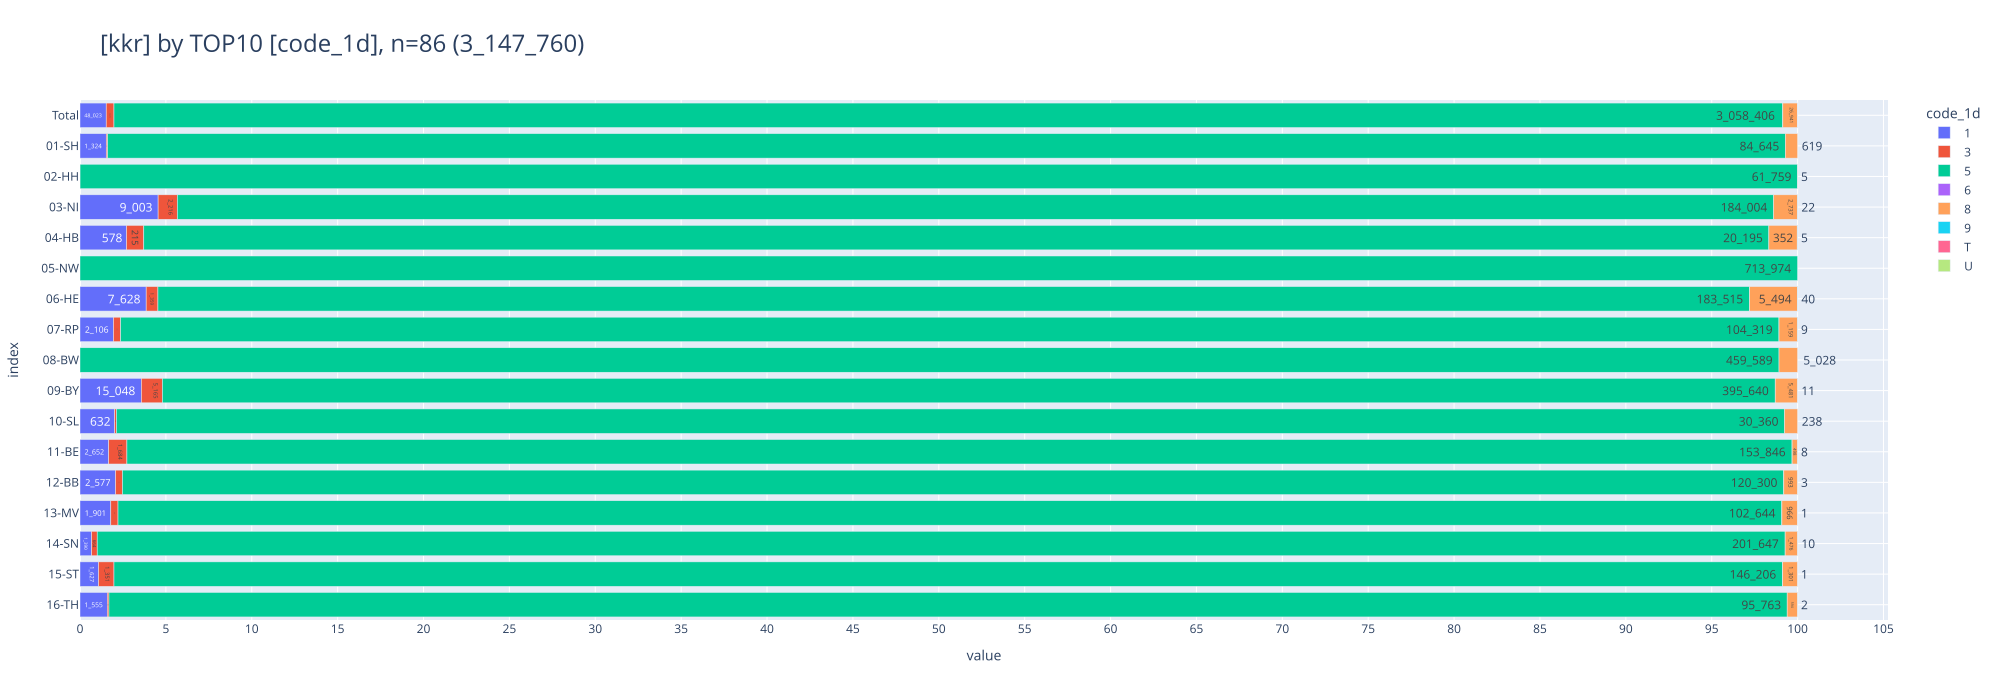

In [38]:
_ops = (OPS
    # .join(Tumor.set_alias("t"), "oBDS_RKIPatientTumorId")
    .aggregate("left(Code,1) as code_1d, z_kkr, count(*) as cnt")
    .join(dim_lieferregister, "z_kkr::int=code::int")
    .project("kkr, code_1d, cnt")
    .to_df()
    )
_=pls.plot_stacked_bars(_ops, orientation="h", height=700, top_n_color=10, relative=True, sort_values_color=False, show_total=True)

<br>

#### <a id='toc1_7_14_2_'></a>[nach OPS Einzelcodes (Top 5)](#toc0_)
- Grundgesamtheit: **alle OPS Codes**

In [39]:
_ops = (OPS.set_alias("o")
    .aggregate("Code, z_kkr, count(*) as cnt")
    .join(dim_lieferregister.set_alias("l"), "z_kkr::int=l.code::int")
    .project("o.Code,kkr, cnt")
    )
# _ops
tbl.pivot_df(_ops.to_df(), top_n_index=5, data_bar_axis="y", pct_axis="", heatmap_axis="", total_axis="y", col1_width=80)

kkr,01-SH,02-HH,03-NI,04-HB,05-NW,06-HE,07-RP,08-BW,09-BY,10-SL,11-BE,12-BB,13-MV,14-SN,15-ST,16-TH,Total
Code,,,,,,,,,,,,,,,,,
5-401.11,5_918,3_813,15_148,1_567,26_109,10_773,7_035,20_972,11_089,1_802,6_533,4_868,3_709,8_246,4_534,3_710,135_826
5-573.40,3_533,2_481,4_993,658,27_975,3_653,4_640,10_415,7_042,750,4_815,4_751,2_709,8_896,4_184,2_771,94_266
5-870.a1,2_540,1_565,7_058,421,12_354,6_018,4_259,9_957,5_532,730,3_600,1_670,1_381,3_660,1_768,2_527,65_040
5-870.a2,2_217,2_467,4_447,236,10_668,3_894,2_255,9_726,5_972,901,2_858,1_903,1_155,1_890,1_428,393,52_410
5-987.0,1_983,980,5_718,391,25_080,4_778,2_841,13_487,11_218,758,3_753,2_804,1_063,4_136,2_419,1_352,82_761


In [40]:
con.sql("""--sql
    select dim_ops.code, dim_ops.name, sum(cnt)::int as cnt
    from _ops
    join dim_ops on _ops.Code = dim_ops.Code
    group by dim_ops.code, dim_ops.name
    order by cnt desc
    limit 5
""").show(max_width=145)


┌──────────┬───────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────┬────────┐
│   code   │                                                           name                                                            │  cnt   │
│ varchar  │                                                          varchar                                                          │ int32  │
├──────────┼───────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────┼────────┤
│ 5-401.11 │ Exzision einzelner Lymphknoten und Lymphgefäße: Axillär: Mit Radionuklidmarkierung (Sentinel-Lymphonodektomie)            │ 135826 │
│ 5-573.40 │ Transurethrale Inzision, Exzision, Destruktion und Resektion von (erkranktem) Gewebe der Harnblase: Resektion: Nicht fl…  │  94266 │
│ 5-987.0  │ Anwendung eines OP-Roboters: Komplexer OP-Roboter                                                              

### <a id='toc1_7_15_'></a>[SYST](#toc0_)

#### <a id='toc1_7_15_1_'></a>[nach Stellung_OP](#toc0_)

- Grundgesamtheit: **alle SYST Elemente**

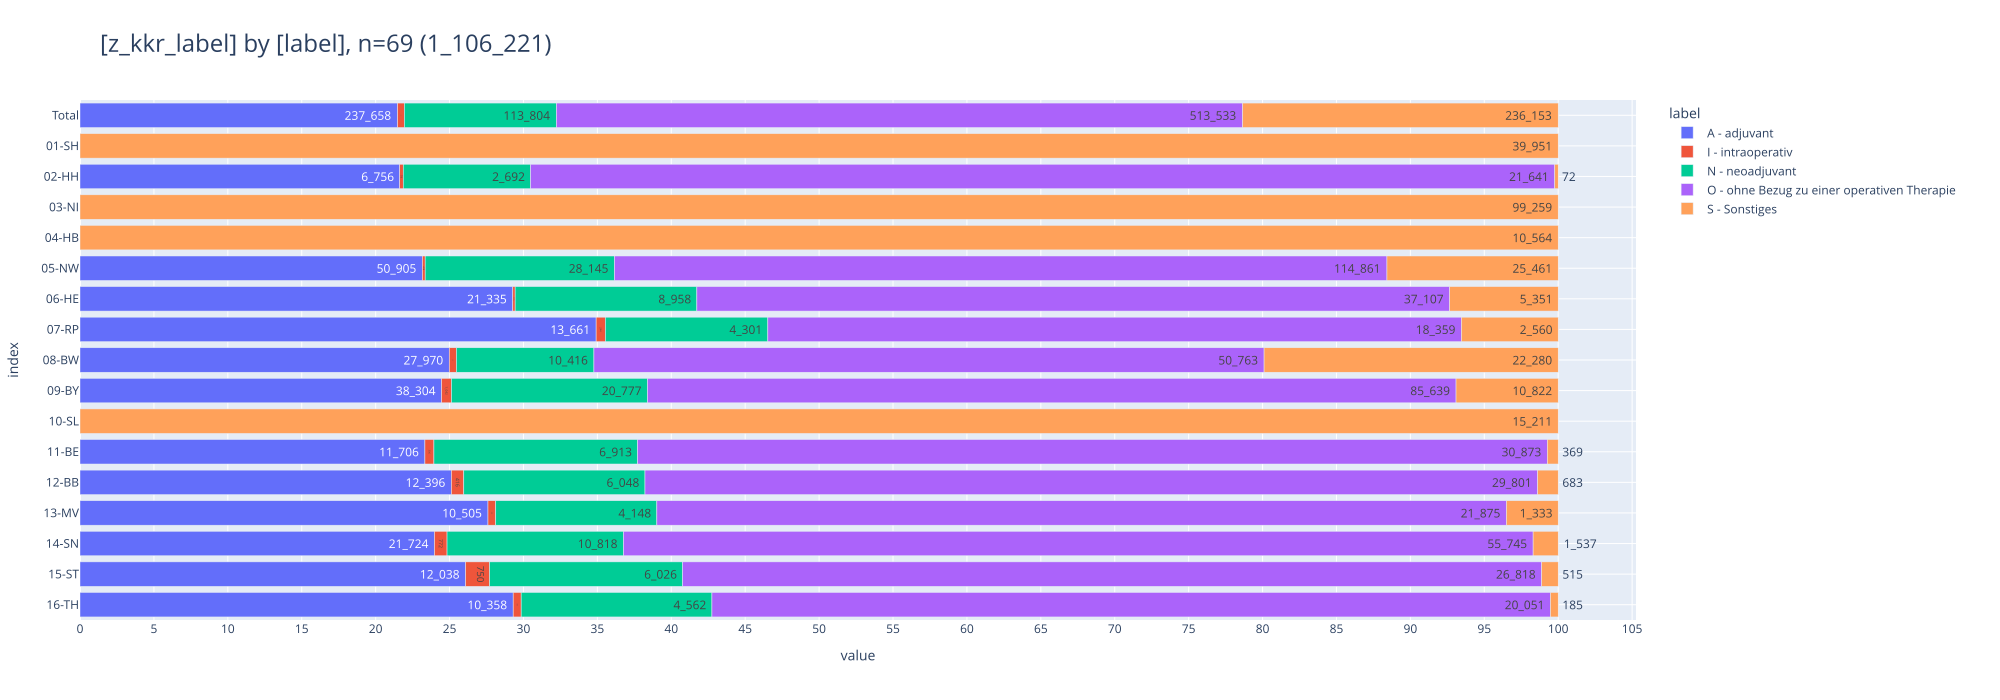

In [41]:
_syst = (SYST
    .join(Tumor.set_alias("t"), "z_tum_id")
    .aggregate("Stellung_OP, t.z_kkr_label, count(*) as cnt")
    .join(dim_syst_op_stellung.set_alias("s"), "Stellung_OP=s.code")
    .project("z_kkr_label,concat(s.code, ' -  ', s.name) as label, cnt")
    .to_df()
    )
_=pls.plot_stacked_bars(_syst, orientation="h", height=700, top_n_color=0, relative=True, show_total=True)

<div style="page-break-after: always;"></div>

## <a id='toc1_8_'></a>[Missings / Unbekannt in den Daten](#toc0_)
- es sind folgende Schwellwerte angezeigt:
  - 🟩 0 bis <5%
  - 🟨 5 bis <100%
  - 🟥 bei 100%
- **Filter: `DJ` 2020-2023** Weitere Filter sind extra aufgeführt
- dargestellt sind Variablen aus dem Schema in folgender Notation: `[Elementknoten]Variablenname`
- die graumelierte `0` kennzeichnet einen leeren Wert (=keine missings), 0% entsteht durch Rundung von kleinen Werten

In [153]:
#
# ? available filter cols: ['kkr', 'table', 'column', 'tablecolumn', 'Diagnose_ICD10_Code_DREI', 'DCO', 'DJ_clipped', <sel criteria>]

from itertools import product


def show_missings(kpi_type: str, filter: str = "", group_table: str = grouper_table.TABLECOL.value):

    if filter and group_table == grouper_table.TABLES.value:
        print("❌ no filter allowed on tables agg level")
        return

    if not filter:
        filter="True"

    # * start
    db_tree =_treecompletion
    
    # * only join if columm is involved
    if group_table == grouper_table.TABLECOL.value:
        db_tree= (db_tree
                .set_alias("t2")
                .join(dim_tree.set_alias("tr"), f"t2.{group_table}=tr.{group_table}", "inner")
                .project("* exclude (t2.tables, t2.tablecolumn)")
        )


    # * then go on, create df
    df_tree =(db_tree.set_alias("t")
        .join(dim_lieferregister.set_alias("l"), "t.kkr::int=l.code::int", "inner")
        .join(dim_icd10_3d.set_alias("i"), "icd10_3d = i.code", "left")
        # * we want the enriched kkr str
        .project("* replace (l.kkr as kkr)")
        # * to use filter, dim_tree must have been joint
        .filter(filter)
        .aggregate(f"""--sql
                kkr, {group_table} --, Diagnose_ICD10_Code_DREI, DCO, DJ_clipped
                ,sum(allHasValues) as allHasValues, sum(sumIsMissing) as sumIsMissing, sum(sumIsUnknown) as sumIsUnknown, sum(sumRelatedTumors) as sumRelatedTumors
                """)
        .project(f"""--sql
                kkr, {group_table} --, Diagnose_ICD10_Code_DREI, DCO, DJ_clipped
                ,case when allHasValues = 0 then 1 else case when sumRelatedTumors = 0 then 0 else sumIsMissing / sumRelatedTumors end end as kpi_missing
                ,case when sumRelatedTumors = 0 then 0 else sumIsUnknown / sumRelatedTumors end as kpi_unknown
            """
            )
        .to_df()
        # .pivot(index=group_table, columns="kkr", values=kpi_type)
    )

    # * create the table for Totals
    df_tree_total =(db_tree.set_alias("t")
        .join(dim_icd10_3d.set_alias("i"), "icd10_3d = i.code", "left")
        # * to use filter, dim_tree must have been joint
        .filter(filter)
        .aggregate(f"""--sql
                {group_table} --, Diagnose_ICD10_Code_DREI, DCO, DJ_clipped
                ,sum(allHasValues) as allHasValues, sum(sumIsMissing) as sumIsMissing, sum(sumIsUnknown) as sumIsUnknown, sum(sumRelatedTumors) as sumRelatedTumors
                """)
        .project(f"""--sql
                'Total' as kkr, {group_table} --, Diagnose_ICD10_Code_DREI, DCO, DJ_clipped
                ,case when allHasValues = 0 then 1 else case when sumRelatedTumors = 0 then 0 else sumIsMissing / sumRelatedTumors end end as kpi_missing
                ,case when sumRelatedTumors = 0 then 0 else sumIsUnknown / sumRelatedTumors end as kpi_unknown
            """
            )
        .to_df()
        # .pivot(index=group_table, columns="kkr", values=kpi_type)
    )

    # * concat both tables
    df_all = df_tree
    # ! dt_tree_total is still experimental
    # df_all = pd.concat([df_tree, df_tree_total], axis=0)

    # * debug
    # print(df_all["tablecolumn"].unique())
    # display(df_all)

    # * add missing kkr
    list_kkr_all = dim_lieferregister.filter("kkr <> 'Total'").to_df().kkr.unique().tolist()
    list_kkr_present = df_all.kkr.unique().tolist()
    list_kkr = list(set(list_kkr_all) - set(list_kkr_present))
    
    # * get available columns 
    list_col = df_all.tablecolumn.unique().tolist()
    
    # * multiply
    prod = list(product(list_kkr, list_col))
    
    # * add this frame to also have missxing kkr
    df_add = pd.DataFrame(prod, columns=["kkr","tablecolumn"]).assign(kpi_missing=1).assign(kpi_unknown=0)
    df_all = pd.concat([df_all,df_add], axis=0).reset_index(drop=True)

    df_all= (df_all
        .pivot(index=group_table, columns="kkr", values=kpi_type)
        # ! when no kkr data are present, set to 100% missing
        .fillna(1)
    )
    
    out = tbl.show_num_df(df_all,
            data_bar_axis="xy",
            total_axis="",
            pct_axis="",
            precision=1,
            kpi_mode="rag_abs",
            # * red threshold: 100% missings | 35% unknown
            kpi_rag_list=[0.05, 1] if kpi_type == kpi.MISSINGS.value else [0.05, 0.35],
            show_as_pct=True,
        )
    display(out)


<br>

### <a id='toc1_8_1_'></a>[Missings für verpflichtende Variablen in Tumor Element](#toc0_)
- kein Filter
- Pflichtangaben aus anderen Elementknoten (z.B. Datum aus dem OP Knoten) sind nicht aufgeführt, da diese selbst optional sind
- ganz überwiegend sind die Angaben vollständig, die wenigen Ausnahmen werden allerdings Stand heute nicht korrigiert

> 💡 `ZfKD`: _Pflichtfelder sind nahezu komplett vorhanden_


In [141]:
show_missings(
    kpi.MISSINGS.value,
    filter=f"sel5_pflicht",
    group_table=grouper_table.TABLECOL.value,
)

kkr,01-SH,02-HH,03-NI,04-HB,05-NW,06-HE,07-RP,08-BW,09-BY,10-SL,11-BE,12-BB,13-MV,14-SN,15-ST,16-TH
tablecolumn,,,,,,,,,,,,,,,,
[Patient]Datum_Vitalstatus,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩
[Patient]Geburtsdatum,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩
[Patient]Geschlecht,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩
[Patient]Verstorben,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩
[Tumor]DCN,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩
[Tumor]Diagnose_ICD10_Code,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0.0% 🟩,0.4% 🟩,0 🟩,0 🟩,0.2% 🟩
[Tumor]Diagnosedatum,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩
[Tumor]Diagnosesicherung,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩
[Tumor]Inzidenzort,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0.9% 🟩,0 🟩,0 🟩,0 🟩


<br>

### <a id='toc1_8_2_'></a>[Missings für Therapieangaben](#toc0_)
- **Filter: `DJ` 2020-2023, `DCO` = N, `ICD10` != C44**
- fiktives Rechenbeispiel für `[Bestrahlung]Anzahl_Tage_Diagnose_ST`:
  - 5363 Bestrahlungen sind in den 01-SH Daten unter Beachtung des Filters (DCO/DJ/ICD10) für den zugeordneten Tumor
  - davon enthalten 302 ein leeres Feld `Anzahl_Tage_Diagnose_ST` -> ~ 6%

#### <a id='toc1_8_2_2_'></a>[Missings für Operationen](#toc0_)

> 💡 `ZfKD`: _Für überlieferte OP liegen `Datum_OP` und `Intention` komplett vollständig vor. Der Tagesabstand hat wenige Lücken, während `Lokale_Beurteilung_Residualstatus` auch ausserhalb von Tristan erkennbar häufiger fehlt._

In [142]:
show_missings(
    kpi.MISSINGS.value,
    filter=f"{fil_pd_dco_dy} and {fil_pd_c44} and tables in ('OP') and tablecolumn not ilike '%genauigkeit'",
    group_table=grouper_table.TABLECOL.value,
)

kkr,01-SH,02-HH,03-NI,04-HB,05-NW,06-HE,07-RP,08-BW,09-BY,10-SL,11-BE,12-BB,13-MV,14-SN,15-ST,16-TH
tablecolumn,,,,,,,,,,,,,,,,
[OP]Anzahl_Tage_Diagnose_OP,1.5% 🟩,0 🟩,2.8% 🟩,2.9% 🟩,3.0% 🟩,0 🟩,4.8% 🟩,2.2% 🟩,0.0% 🟩,2.7% 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0.0% 🟩
[OP]Datum_OP,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩
[OP]Intention,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩
[OP]Lokale_Beurteilung_Residualstatus,100.0% 🟥,4.2% 🟩,100.0% 🟥,100.0% 🟥,8.7% 🟨,10.3% 🟨,1.8% 🟩,0.0% 🟩,14.7% 🟨,100.0% 🟥,10.8% 🟨,11.1% 🟨,5.1% 🟨,7.0% 🟨,15.4% 🟨,16.4% 🟨


#### <a id='toc1_8_2_3_'></a>[Missings für Strahlentherapie](#toc0_)

> 💡 `ZfKD`: _`Datum_Beginn_Bestrahlung` und `Intention` sind nahezu komplett verfügbar in den dokumentierten ST / Bestrahlungen, mit Abstrichen auch `Anzahl_Tage_Diagnose_ST`._  
> _`Anzahl_Tage_ST_Dauer` und `Stellung_OP` fehlen bei Tristan_  
> _`Applikationsart` wird nicht von allen kkr übermittelt, davon abgesehen ist `Seite_Zielgebiet` zuverlässig angegeben, die CodeVersionen ergänzen sich, wobei `2014` deutlich häufiger angewendet wird als `2021`._

In [143]:
show_missings(
    kpi.MISSINGS.value,
    filter=f"""--sql
        {fil_pd_dco_dy} and {fil_pd_c44} and tablecolumn not ilike '%genauigkeit' and (
            tables in ('ST', 'Bestrahlung') 
            or regexp_matches(tablecolumn,'codeversion|zielgebiet','i')
        )
    """,
    group_table=grouper_table.TABLECOL.value,
)

kkr,01-SH,02-HH,03-NI,04-HB,05-NW,06-HE,07-RP,08-BW,09-BY,10-SL,11-BE,12-BB,13-MV,14-SN,15-ST,16-TH
tablecolumn,,,,,,,,,,,,,,,,
[Applikationsart]CodeVersion2014,100.0% 🟥,46.7% 🟨,100.0% 🟥,100.0% 🟥,100.0% 🟥,10.7% 🟨,100.0% 🟥,24.9% 🟨,8.5% 🟨,100.0% 🟥,16.9% 🟨,11.8% 🟨,0.4% 🟩,34.9% 🟨,18.7% 🟨,27.4% 🟨
[Applikationsart]CodeVersion2021,100.0% 🟥,53.3% 🟨,100.0% 🟥,100.0% 🟥,0 🟩,89.4% 🟨,100.0% 🟥,75.9% 🟨,93.3% 🟨,100.0% 🟥,83.5% 🟨,88.4% 🟨,99.7% 🟨,65.3% 🟨,81.3% 🟨,73.0% 🟨
[Applikationsart]Seite_Zielgebiet,100.0% 🟥,0.0% 🟩,100.0% 🟥,100.0% 🟥,0 🟩,0.0% 🟩,100.0% 🟥,0.9% 🟩,0.9% 🟩,100.0% 🟥,0.0% 🟩,0.0% 🟩,0.0% 🟩,0.2% 🟩,0.0% 🟩,0.3% 🟩
[Bestrahlung]Anzahl_Tage_Diagnose_ST,5.3% 🟨,0 🟩,6.7% 🟨,6.1% 🟨,0.4% 🟩,0 🟩,10.2% 🟨,0.1% 🟩,0.1% 🟩,5.4% 🟨,0.0% 🟩,0.0% 🟩,0.0% 🟩,0 🟩,0.0% 🟩,0.0% 🟩
[Bestrahlung]Anzahl_Tage_ST_Dauer,100.0% 🟥,2.2% 🟩,100.0% 🟥,100.0% 🟥,8.6% 🟨,3.9% 🟩,5.8% 🟨,0 🟩,3.8% 🟩,100.0% 🟥,1.4% 🟩,1.3% 🟩,1.9% 🟩,0.4% 🟩,1.3% 🟩,1.4% 🟩
[Bestrahlung]Datum_Beginn_Bestrahlung,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0.0% 🟩,0.0% 🟩,0.0% 🟩,0 🟩,0 🟩,0.0% 🟩
[ST]Intention,0.0% 🟩,0 🟩,0.4% 🟩,0.0% 🟩,0.0% 🟩,0.1% 🟩,0 🟩,0 🟩,3.5% 🟩,0 🟩,0.2% 🟩,0.1% 🟩,0.0% 🟩,0.0% 🟩,0.0% 🟩,1.1% 🟩
[ST]Stellung_OP,100.0% 🟥,0.0% 🟩,100.0% 🟥,100.0% 🟥,0 🟩,0.7% 🟩,0.3% 🟩,0 🟩,3.9% 🟩,100.0% 🟥,0 🟩,0.0% 🟩,0.1% 🟩,0.0% 🟩,0.0% 🟩,1.6% 🟩


#### <a id='toc1_8_2_4_'></a>[Missings für systemische Therapie](#toc0_)

> 💡 `ZfKD`: _Die meisten Angaben im SYST Element liegen komplett vor. `Anzahl_Tage_SYST_Dauer` fehlt häufig, was auch an noch nicht abgeschlossenen Therapien liegen könnte - wohingegen `08-BW` hier als einzige keine missings ausweisen._

In [144]:
show_missings(
    kpi.MISSINGS.value,
    filter=f"{fil_pd_dco_dy} and {fil_pd_c44} and tables in ('SYST') and tablecolumn not ilike '%genauigkeit'",
    group_table=grouper_table.TABLECOL.value,
)

kkr,01-SH,02-HH,03-NI,04-HB,05-NW,06-HE,07-RP,08-BW,09-BY,10-SL,11-BE,12-BB,13-MV,14-SN,15-ST,16-TH
tablecolumn,,,,,,,,,,,,,,,,
[SYST]Anzahl_Tage_Diagnose_SYST,6.4% 🟨,0 🟩,11.1% 🟨,12.3% 🟨,1.1% 🟩,0 🟩,16.8% 🟨,0.4% 🟩,0.1% 🟩,13.3% 🟨,0.0% 🟩,0.0% 🟩,0.1% 🟩,0 🟩,0.0% 🟩,0.0% 🟩
[SYST]Anzahl_Tage_SYST_Dauer,100.0% 🟥,31.3% 🟨,100.0% 🟥,100.0% 🟥,43.1% 🟨,35.7% 🟨,40.8% 🟨,0 🟩,44.7% 🟨,100.0% 🟥,32.2% 🟨,40.1% 🟨,37.0% 🟨,33.3% 🟨,40.5% 🟨,37.3% 🟨
[SYST]Datum_Beginn_SYST,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩
[SYST]Intention,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩
[SYST]Stellung_OP,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩
[SYST]Therapieart,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩


### <a id='toc1_8_3_'></a>[Missings für Folgeereignisse](#toc0_)

> 💡 `ZfKD`: _`Datum_Folgeereignis` und `Gesamtbeurteilung_Tumorstatus` liegen komplett vor, die anderen Angaben zum Tumorstatus allerdings nicht. Angaben für `Folgeereignis_TNM` fehlen ganz überwiegend, auch wenn Folgereignisse keine TNM enthalten müssen. Die Erkennung von Rezidiven ist so deutlich erschwert._

In [145]:
show_missings(
    kpi.MISSINGS.value,
    filter=f"{fil_pd_dco_dy} and tablecolumn not ilike '%genauigkeit' and sel11_fo",
    # filter=f"{fil_pd_dco_dy} and tablecolumn not ilike '%genauigkeit' and tables in ('Folgeereignis')",
    group_table=grouper_table.TABLECOL.value,
)

kkr,01-SH,02-HH,03-NI,04-HB,05-NW,06-HE,07-RP,08-BW,09-BY,10-SL,11-BE,12-BB,13-MV,14-SN,15-ST,16-TH
tablecolumn,,,,,,,,,,,,,,,,
[Folgeereignis]Datum_Folgeereignis,100.0% 🟥,0 🟩,100.0% 🟥,100.0% 🟥,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,100.0% 🟥,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩
[Folgeereignis]Gesamtbeurteilung_Tumorstatus,100.0% 🟥,0 🟩,100.0% 🟥,100.0% 🟥,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,100.0% 🟥,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩
[Folgeereignis]Verlauf_Lokaler_Tumorstatus,100.0% 🟥,61.2% 🟨,100.0% 🟥,100.0% 🟥,30.3% 🟨,26.1% 🟨,0.3% 🟩,0 🟩,39.2% 🟨,100.0% 🟥,26.0% 🟨,26.9% 🟨,31.8% 🟨,30.0% 🟨,18.3% 🟨,26.6% 🟨
[Folgeereignis]Verlauf_Tumorstatus_Fernmetastasen,100.0% 🟥,61.3% 🟨,100.0% 🟥,100.0% 🟥,31.3% 🟨,28.2% 🟨,0.4% 🟩,0 🟩,40.8% 🟨,100.0% 🟥,24.2% 🟨,25.4% 🟨,34.0% 🟨,29.3% 🟨,17.0% 🟨,27.6% 🟨
[Folgeereignis]Verlauf_Tumorstatus_Lymphknoten,100.0% 🟥,61.5% 🟨,100.0% 🟥,100.0% 🟥,32.0% 🟨,31.9% 🟨,0.4% 🟩,0 🟩,45.2% 🟨,100.0% 🟥,31.1% 🟨,32.6% 🟨,35.5% 🟨,35.1% 🟨,20.5% 🟨,32.2% 🟨
[Folgeereignis_TNM]T,100.0% 🟥,80.0% 🟨,100.0% 🟥,100.0% 🟥,89.3% 🟨,87.8% 🟨,100.0% 🟥,98.3% 🟨,79.2% 🟨,100.0% 🟥,83.4% 🟨,87.5% 🟨,76.8% 🟨,88.3% 🟨,91.1% 🟨,83.1% 🟨
[Folgeereignis_TNM]UICC_Stadium,100.0% 🟥,100.0% 🟥,100.0% 🟥,100.0% 🟥,100.0% 🟥,95.1% 🟨,100.0% 🟥,100.0% 🟥,87.5% 🟨,100.0% 🟥,93.6% 🟨,95.0% 🟨,90.2% 🟨,89.5% 🟨,93.8% 🟨,93.9% 🟨
[Folgeereignis_TNM]r_Symbol,100.0% 🟥,100.0% 🟥,100.0% 🟥,100.0% 🟥,99.2% 🟨,98.3% 🟨,100.0% 🟥,99.0% 🟨,97.3% 🟨,100.0% 🟥,97.6% 🟨,98.1% 🟨,99.2% 🟨,95.7% 🟨,99.1% 🟨,99.5% 🟨
[Folgeereignis_TNM]y_Symbol,100.0% 🟥,100.0% 🟥,100.0% 🟥,100.0% 🟥,99.0% 🟨,98.7% 🟨,100.0% 🟥,99.8% 🟨,98.7% 🟨,100.0% 🟥,97.7% 🟨,98.6% 🟨,98.8% 🟨,99.1% 🟨,99.3% 🟨,99.4% 🟨


### <a id='toc1_8_4_'></a>[Missings für Freitexte](#toc0_)

> 💡 `ZfKD`: _Protokolle und Substanzen werden nach und nach in den Datensatz eingebunden. Protokolle bislang ausschliesslich als Freitext. Bei Substanzen komplementieren sich Freitexte und Kodierungen, bei vielen GTDS Ländern überwiegen inzwischen die Kodierungen._


In [146]:
show_missings(
    kpi.MISSINGS.value,
    filter=f"{fil_pd_dco_dy} and not regexp_matches(tablecolumn,'genauigkeit','i') and sel12_free",
    # filter=f"{fil_pd_dco_dy} and tablecolumn not ilike '%genauigkeit' and sel12_free",
    group_table=grouper_table.TABLECOL.value,
)

kkr,01-SH,02-HH,03-NI,04-HB,05-NW,06-HE,07-RP,08-BW,09-BY,10-SL,11-BE,12-BB,13-MV,14-SN,15-ST,16-TH
tablecolumn,,,,,,,,,,,,,,,,
[Protokoll]Bezeichnung,100.0% 🟥,0 🟩,100.0% 🟥,100.0% 🟥,0 🟩,0 🟩,100.0% 🟥,100.0% 🟥,0 🟩,100.0% 🟥,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩,0 🟩
[Protokoll]Protokoll_TypProtokollschluessel_Code,100.0% 🟥,100.0% 🟥,100.0% 🟥,100.0% 🟥,100.0% 🟥,100.0% 🟥,100.0% 🟥,100.0% 🟥,100.0% 🟥,100.0% 🟥,100.0% 🟥,100.0% 🟥,100.0% 🟥,100.0% 🟥,100.0% 🟥,100.0% 🟥
[Substanz]Bezeichnung,100.0% 🟥,0 🟩,100.0% 🟥,100.0% 🟥,0 🟩,86.0% 🟨,100.0% 🟥,0 🟩,43.0% 🟨,100.0% 🟥,91.4% 🟨,91.7% 🟨,0.1% 🟩,85.7% 🟨,81.5% 🟨,59.0% 🟨
[Substanz]SYST_TypSubstanzATC_Code,100.0% 🟥,100.0% 🟥,100.0% 🟥,100.0% 🟥,100.0% 🟥,14.0% 🟨,100.0% 🟥,100.0% 🟥,57.0% 🟨,100.0% 🟥,8.6% 🟨,8.3% 🟨,100.0% 🟥,14.3% 🟨,18.5% 🟨,41.0% 🟨


<br>

### <a id='toc1_8_5_'></a>[Missings für Tumorstadien](#toc0_)
- **Filter: `DJ` 2020-2023, `DCO` = N, `ICD10` nur solide Tumoren**

> 💡 `ZfKD`: _"`05-NW` hat die Auflage als Konstante im Datensatz hinterlegt"_

In [147]:
show_missings(
    kpi.MISSINGS.value,
    filter=f"{fil_pd_dco_dy} and sel3_TNM and is_solid",
    group_table=grouper_table.TABLECOL.value,
)

kkr,01-SH,02-HH,03-NI,04-HB,05-NW,06-HE,07-RP,08-BW,09-BY,10-SL,11-BE,12-BB,13-MV,14-SN,15-ST,16-TH
tablecolumn,,,,,,,,,,,,,,,,
[Tumor]M_c,39.9% 🟨,24.3% 🟨,55.4% 🟨,32.2% 🟨,28.4% 🟨,55.1% 🟨,71.5% 🟨,45.5% 🟨,56.2% 🟨,31.4% 🟨,36.3% 🟨,40.1% 🟨,35.0% 🟨,34.2% 🟨,44.2% 🟨,44.6% 🟨
[Tumor]M_p,44.6% 🟨,93.3% 🟨,54.3% 🟨,46.8% 🟨,92.5% 🟨,56.8% 🟨,55.6% 🟨,50.9% 🟨,60.7% 🟨,90.9% 🟨,48.2% 🟨,49.2% 🟨,45.6% 🟨,40.8% 🟨,46.1% 🟨,42.1% 🟨
[Tumor]N_c,39.2% 🟨,36.9% 🟨,53.4% 🟨,32.2% 🟨,40.5% 🟨,53.3% 🟨,72.2% 🟨,49.3% 🟨,54.5% 🟨,41.7% 🟨,34.9% 🟨,39.1% 🟨,34.7% 🟨,34.2% 🟨,45.2% 🟨,44.3% 🟨
[Tumor]N_p,38.0% 🟨,61.3% 🟨,47.0% 🟨,44.5% 🟨,59.3% 🟨,46.4% 🟨,53.0% 🟨,64.9% 🟨,46.7% 🟨,55.4% 🟨,45.5% 🟨,45.7% 🟨,42.5% 🟨,40.6% 🟨,45.9% 🟨,41.6% 🟨
[Tumor]TNM_Auflage_c,38.1% 🟨,19.7% 🟨,51.4% 🟨,30.1% 🟨,0 🟩,48.5% 🟨,63.4% 🟨,45.5% 🟨,49.9% 🟨,25.8% 🟨,32.2% 🟨,33.9% 🟨,31.8% 🟨,33.9% 🟨,42.1% 🟨,43.1% 🟨
[Tumor]TNM_Auflage_p,35.7% 🟨,38.8% 🟨,41.0% 🟨,43.0% 🟨,0 🟩,40.8% 🟨,49.8% 🟨,50.8% 🟨,39.4% 🟨,32.6% 🟨,42.5% 🟨,42.3% 🟨,39.0% 🟨,40.3% 🟨,44.1% 🟨,40.7% 🟨
[Tumor]T_c,39.0% 🟨,45.7% 🟨,50.8% 🟨,31.2% 🟨,47.0% 🟨,48.5% 🟨,65.3% 🟨,45.5% 🟨,49.9% 🟨,47.2% 🟨,32.2% 🟨,33.9% 🟨,31.7% 🟨,33.9% 🟨,42.0% 🟨,43.1% 🟨
[Tumor]T_p,35.9% 🟨,43.7% 🟨,41.0% 🟨,42.9% 🟨,45.2% 🟨,40.8% 🟨,49.8% 🟨,50.8% 🟨,39.4% 🟨,41.2% 🟨,42.5% 🟨,42.3% 🟨,39.0% 🟨,40.3% 🟨,44.1% 🟨,40.7% 🟨
[Tumor]UICC_Stadium_c,49.6% 🟨,100.0% 🟥,100.0% 🟨,38.0% 🟨,100.0% 🟥,59.4% 🟨,76.8% 🟨,53.8% 🟨,60.5% 🟨,87.6% 🟨,45.3% 🟨,50.4% 🟨,40.7% 🟨,36.8% 🟨,46.6% 🟨,50.2% 🟨


<br>

### <a id='toc1_8_6_'></a>[Missings für organspezifische Variablen (Mamma)](#toc0_)
- **Filter: `DJ` 2020-2023, `DCO` = N, `ICD10` = C50**
- die Prozentwerte sind bei allen Darstellungen gerundet, "100%" bei einer gelben Ampel kann interpretiert werden als knapp unter 100%
> 💡 `HH` _"Fehlende Modul-Angaben (C50, C61) 2021. Sind bei uns noch nicht im xml enthalten."_

In [148]:
show_missings(
    kpi.MISSINGS.value,
    filter=f"{fil_pd_dco_dy} and sel6_mamma and icd10_3d='C50'",
    group_table=grouper_table.TABLECOL.value,
)

kkr,01-SH,02-HH,03-NI,04-HB,05-NW,06-HE,07-RP,08-BW,09-BY,10-SL,11-BE,12-BB,13-MV,14-SN,15-ST,16-TH
tablecolumn,,,,,,,,,,,,,,,,
[Tumor]Her2neuStatus,16.9% 🟨,100.0% 🟥,6.2% 🟨,1.0% 🟩,40.9% 🟨,18.0% 🟨,35.7% 🟨,11.9% 🟨,13.1% 🟨,5.7% 🟨,0.6% 🟩,0.9% 🟩,4.0% 🟩,0.9% 🟩,8.5% 🟨,9.4% 🟨
[Tumor]HormonrezeptorStatus_Oestrogen,14.3% 🟨,100.0% 🟥,6.2% 🟨,1.0% 🟩,40.1% 🟨,17.6% 🟨,35.8% 🟨,11.8% 🟨,29.5% 🟨,5.4% 🟨,7.9% 🟨,8.2% 🟨,18.0% 🟨,2.9% 🟩,11.2% 🟨,5.6% 🟨
[Tumor]HormonrezeptorStatus_Progesteron,14.4% 🟨,100.0% 🟥,6.2% 🟨,1.0% 🟩,40.0% 🟨,17.3% 🟨,35.8% 🟨,16.1% 🟨,29.5% 🟨,5.2% 🟨,8.0% 🟨,8.3% 🟨,18.0% 🟨,2.9% 🟩,11.3% 🟨,5.6% 🟨
[Tumor]Praetherapeutischer_Menopausenstatus,21.1% 🟨,100.0% 🟥,39.0% 🟨,6.3% 🟨,34.4% 🟨,39.5% 🟨,43.2% 🟨,29.7% 🟨,43.0% 🟨,27.1% 🟨,24.9% 🟨,34.3% 🟨,24.0% 🟨,9.3% 🟨,34.5% 🟨,42.4% 🟨
[Tumor]TumorgroesseDCIS,70.6% 🟨,100.0% 🟥,67.8% 🟨,36.6% 🟨,74.5% 🟨,80.9% 🟨,73.6% 🟨,53.1% 🟨,99.1% 🟨,68.4% 🟨,99.9% 🟨,99.8% 🟨,99.9% 🟨,100.0% 🟨,97.6% 🟨,100.0% 🟨
[Tumor]TumorgroesseInvasiv,36.6% 🟨,100.0% 🟥,32.1% 🟨,22.3% 🟨,51.9% 🟨,54.6% 🟨,49.7% 🟨,31.7% 🟨,74.5% 🟨,26.6% 🟨,39.3% 🟨,40.4% 🟨,50.4% 🟨,24.5% 🟨,61.8% 🟨,45.6% 🟨


<br>

### <a id='toc1_8_7_'></a>[Missings für organspezifische Variablen (Prostata)](#toc0_)
- **Filter: `DJ` 2020-2023, `DCO` = N, `ICD10` = C61**

> 💡 `ZfKD` _Auch innerhalb eines KKR gibt es deutliche Varianzen zwischen Variablen des organspezifischen Moduls, z.B. in 11-16_

In [149]:
show_missings(
    kpi.MISSINGS.value,
    filter=f"{fil_pd_dco_dy} and sel7_prostata and icd10_3d='C61'",
    group_table=grouper_table.TABLECOL.value,
)

kkr,01-SH,02-HH,03-NI,04-HB,05-NW,06-HE,07-RP,08-BW,09-BY,10-SL,11-BE,12-BB,13-MV,14-SN,15-ST,16-TH
tablecolumn,,,,,,,,,,,,,,,,
[Tumor]AnlassGleasonScore,20.5% 🟨,100.0% 🟥,10.4% 🟨,7.7% 🟨,100.0% 🟥,65.3% 🟨,56.4% 🟨,13.9% 🟨,54.7% 🟨,8.2% 🟨,46.0% 🟨,56.4% 🟨,40.8% 🟨,39.2% 🟨,74.7% 🟨,87.8% 🟨
[Tumor]DatumPSA,42.2% 🟨,100.0% 🟥,39.6% 🟨,36.5% 🟨,100.0% 🟥,45.6% 🟨,63.9% 🟨,95.5% 🟨,44.0% 🟨,27.4% 🟨,23.1% 🟨,21.5% 🟨,19.9% 🟨,13.3% 🟨,28.9% 🟨,17.8% 🟨
[Tumor]PSA,41.9% 🟨,100.0% 🟥,39.0% 🟨,34.2% 🟨,100.0% 🟥,45.6% 🟨,56.1% 🟨,34.0% 🟨,44.0% 🟨,23.1% 🟨,23.1% 🟨,21.5% 🟨,19.9% 🟨,13.3% 🟨,28.9% 🟨,17.8% 🟨
[Tumor]ScoreErgebnis,18.5% 🟨,100.0% 🟥,8.5% 🟨,7.7% 🟨,100.0% 🟥,20.7% 🟨,52.6% 🟨,10.5% 🟨,22.0% 🟨,4.1% 🟩,9.5% 🟨,8.6% 🟨,12.3% 🟨,4.2% 🟩,8.1% 🟨,9.4% 🟨


<br>

### <a id='toc1_8_8_'></a>[Missings für organspezifische Variablen (Darm)](#toc0_)
- **Filter: `DJ` 2020-2023, `DCO` = N, `ICD10` = C18-C20**

In [150]:
show_missings(
    kpi.MISSINGS.value,
    filter=f"{fil_pd_dco_dy} and sel9_darm and icd10_3d in ('C18','C19','C20')",
    group_table=grouper_table.TABLECOL.value,
)

kkr,01-SH,02-HH,03-NI,04-HB,05-NW,06-HE,07-RP,08-BW,09-BY,10-SL,11-BE,12-BB,13-MV,14-SN,15-ST,16-TH
tablecolumn,,,,,,,,,,,,,,,,
[Tumor]RASMutation,57.5% 🟨,100.0% 🟥,64.6% 🟨,43.8% 🟨,74.3% 🟨,71.2% 🟨,84.1% 🟨,64.7% 🟨,83.1% 🟨,78.2% 🟨,64.6% 🟨,71.5% 🟨,64.0% 🟨,86.8% 🟨,94.8% 🟨,79.5% 🟨
[Tumor]RektumAbstandAnokutanlinie,86.4% 🟨,100.0% 🟥,88.7% 🟨,87.0% 🟨,84.1% 🟨,80.2% 🟨,88.4% 🟨,82.8% 🟨,87.1% 🟨,83.2% 🟨,90.5% 🟨,84.2% 🟨,80.8% 🟨,77.6% 🟨,95.9% 🟨,92.3% 🟨


<br>

### <a id='toc1_8_9_'></a>[Missings für organspezifische Variablen (Melanom)](#toc0_)
- **Filter: `DJ` 2020-2023, `DCO` = N, `ICD10` = C43**

In [151]:
show_missings(
    kpi.MISSINGS.value,
    filter=f"{fil_pd_dco_dy} and sel10_melanom and icd10_3d in ('C43')",
    group_table=grouper_table.TABLECOL.value,
)

kkr,01-SH,02-HH,03-NI,04-HB,05-NW,06-HE,07-RP,08-BW,09-BY,10-SL,11-BE,12-BB,13-MV,14-SN,15-ST,16-TH
tablecolumn,,,,,,,,,,,,,,,,
[Tumor]LDH,98.4% 🟨,100.0% 🟥,96.3% 🟨,87.0% 🟨,100.0% 🟥,100.0% 🟥,97.7% 🟨,91.9% 🟨,100.0% 🟥,97.3% 🟨,100.0% 🟥,100.0% 🟥,100.0% 🟥,100.0% 🟥,100.0% 🟥,100.0% 🟥
[Tumor]Tumordicke,56.5% 🟨,100.0% 🟥,47.3% 🟨,21.2% 🟨,100.0% 🟥,100.0% 🟥,78.5% 🟨,17.1% 🟨,100.0% 🟥,46.0% 🟨,100.0% 🟥,100.0% 🟥,100.0% 🟥,100.0% 🟥,100.0% 🟥,100.0% 🟥
[Tumor]Ulzeration,62.7% 🟨,100.0% 🟥,64.2% 🟨,16.9% 🟨,100.0% 🟥,100.0% 🟥,82.3% 🟨,42.2% 🟨,100.0% 🟥,61.5% 🟨,100.0% 🟥,100.0% 🟥,100.0% 🟥,100.0% 🟥,100.0% 🟥,100.0% 🟥


<br>

### <a id='toc1_8_10_'></a>[Unbekannt-Kodierungen für ausgewählte Variablen](#toc0_)
- kein Filter
- die Darstellungen sind vorläufig, da die Definitionen für unbekannte Ausprägungen noch nicht ausgereift sind
- einige gewertete Unbekannt-Kodierungen aus der Auflistung
  - `Diagnosesicherung` = 9
  - `Seitenlokalisation` = U
  - `Morphologie` 8000 - 8010
  - `Datumsgenauigkeit` in ('M','V')
  - `Diagnose_ICD10_Code` = C80

> 💡 `ZfKD`: _`Gesamtbeurteilung_Tumorstatus`ist zwar vollständig geliefert (siehe vorherige Grafiken), aber häufig als Unbekannt kodiert. Viele Pflichtvariablen haben keine Unbekannt Kodes, etwas auffällig sind hier `Diagnosesicherung` und `Seitenlokalisation`. Ähnlich auch `Morphologie` (kein Pflichtfeld)._ 


In [152]:
show_missings(
    kpi.UNKNOWN.value,
    filter=f"sel13_unknown",
    group_table=grouper_table.TABLECOL.value,
)

kkr,01-SH,02-HH,03-NI,04-HB,05-NW,06-HE,07-RP,08-BW,09-BY,10-SL,11-BE,12-BB,13-MV,14-SN,15-ST,16-TH
tablecolumn,,,,,,,,,,,,,,,,
[Folgeereignis]Gesamtbeurteilung_Tumorstatus,100.0% 🟥,0.2% 🟩,100.0% 🟥,100.0% 🟥,29.9% 🟨,18.2% 🟨,2.7% 🟩,3.0% 🟩,35.0% 🟨,100.0% 🟥,17.7% 🟨,14.2% 🟨,29.6% 🟨,17.0% 🟨,14.0% 🟨,25.3% 🟨
[Patient]Geburtsdatum_Genauigkeit,0 🟩,0 🟩,0 🟩,0 🟩,0.2% 🟩,0.2% 🟩,0.0% 🟩,0.0% 🟩,0.0% 🟩,0 🟩,0.0% 🟩,0.0% 🟩,0.1% 🟩,0.0% 🟩,0.0% 🟩,0 🟩
[Patient]Geschlecht,0.0% 🟩,0.0% 🟩,0.0% 🟩,0.0% 🟩,0.0% 🟩,0 🟩,0.0% 🟩,0.0% 🟩,0.0% 🟩,0.0% 🟩,0.0% 🟩,0 🟩,0.0% 🟩,0 🟩,0 🟩,0.0% 🟩
[Tumor]Diagnose_ICD10_Code,1.1% 🟩,1.5% 🟩,1.5% 🟩,1.6% 🟩,1.2% 🟩,1.0% 🟩,1.1% 🟩,1.4% 🟩,1.5% 🟩,1.2% 🟩,1.8% 🟩,1.7% 🟩,0.9% 🟩,0.8% 🟩,1.3% 🟩,0.8% 🟩
[Tumor]Diagnosedatum_Genauigkeit,0.1% 🟩,0.3% 🟩,0.2% 🟩,0.3% 🟩,0 🟩,0.9% 🟩,0.3% 🟩,0.7% 🟩,0.8% 🟩,0.1% 🟩,1.3% 🟩,0.5% 🟩,0.4% 🟩,0.7% 🟩,1.1% 🟩,0.6% 🟩
[Tumor]Diagnosesicherung,4.9% 🟩,6.2% 🟨,8.3% 🟨,16.0% 🟨,5.8% 🟨,2.3% 🟩,11.4% 🟨,10.1% 🟨,1.7% 🟩,21.4% 🟨,1.2% 🟩,1.6% 🟩,1.8% 🟩,0.5% 🟩,1.2% 🟩,1.4% 🟩
[Tumor]Morphologie_Code,6.4% 🟨,8.0% 🟨,1.4% 🟩,6.2% 🟨,10.1% 🟨,2.9% 🟩,1.9% 🟩,11.4% 🟨,1.1% 🟩,7.6% 🟨,4.1% 🟩,2.6% 🟩,1.6% 🟩,1.9% 🟩,2.6% 🟩,1.5% 🟩
[Tumor]Seitenlokalisation,5.8% 🟨,2.0% 🟩,2.0% 🟩,5.1% 🟨,18.8% 🟨,2.4% 🟩,1.4% 🟩,6.7% 🟨,5.0% 🟩,7.0% 🟨,2.3% 🟩,4.1% 🟩,0.7% 🟩,1.7% 🟩,5.6% 🟨,4.0% 🟩


<br>

## <a id='toc1_9_'></a>[Verteilung Monat von Datum_Vitalstatus](#toc0_)
- **Filter: alle Patienten mit `Verstorben`=N, `DJ` und `SJ` 2020-2023**

> 💡 `HH`: _"Das liegt an unserer Darstellung des Vitalstatus-Datum. Nach Abschluss der DC-Recherche, die nach Abschluss des 'Todesjahres' durchgeführt wird, wird bei allen Patienten bei denen wir keine weiteren Meldungen bzw Informationen zum Vitalstatus bekommen haben der 31.12. des abgeschlossenen 'Todesjahres' gesetzt. In diesem Fall ist dies das aktuelle Jahr - 2 -> 31.12.2022, da die DC-Recherche zum Zeitpunkt der Datenlieferung noch nicht abgeschlossen war. Wenn jetzt ein Patient die letzte Meldung mit einem Leistungsdatum in 2019 hatte, wir aber keine weiteren Informationen bekommen haben, gehen wir also nach Abschluss der Recherche davon aus, dass der Patient am 31.12.2022 noch gelebt hat. Dadurch 'verbessert' sich tatsächlich der Vitalstatus in unseren Daten, ansonsten wäre dieser nämlich irgendwann in 2019."_

> 💡 `ZfKD`: angestrebt ist die Verwendung eines einzelnen Erhebungszeitpunkts (z.B. Dezember)

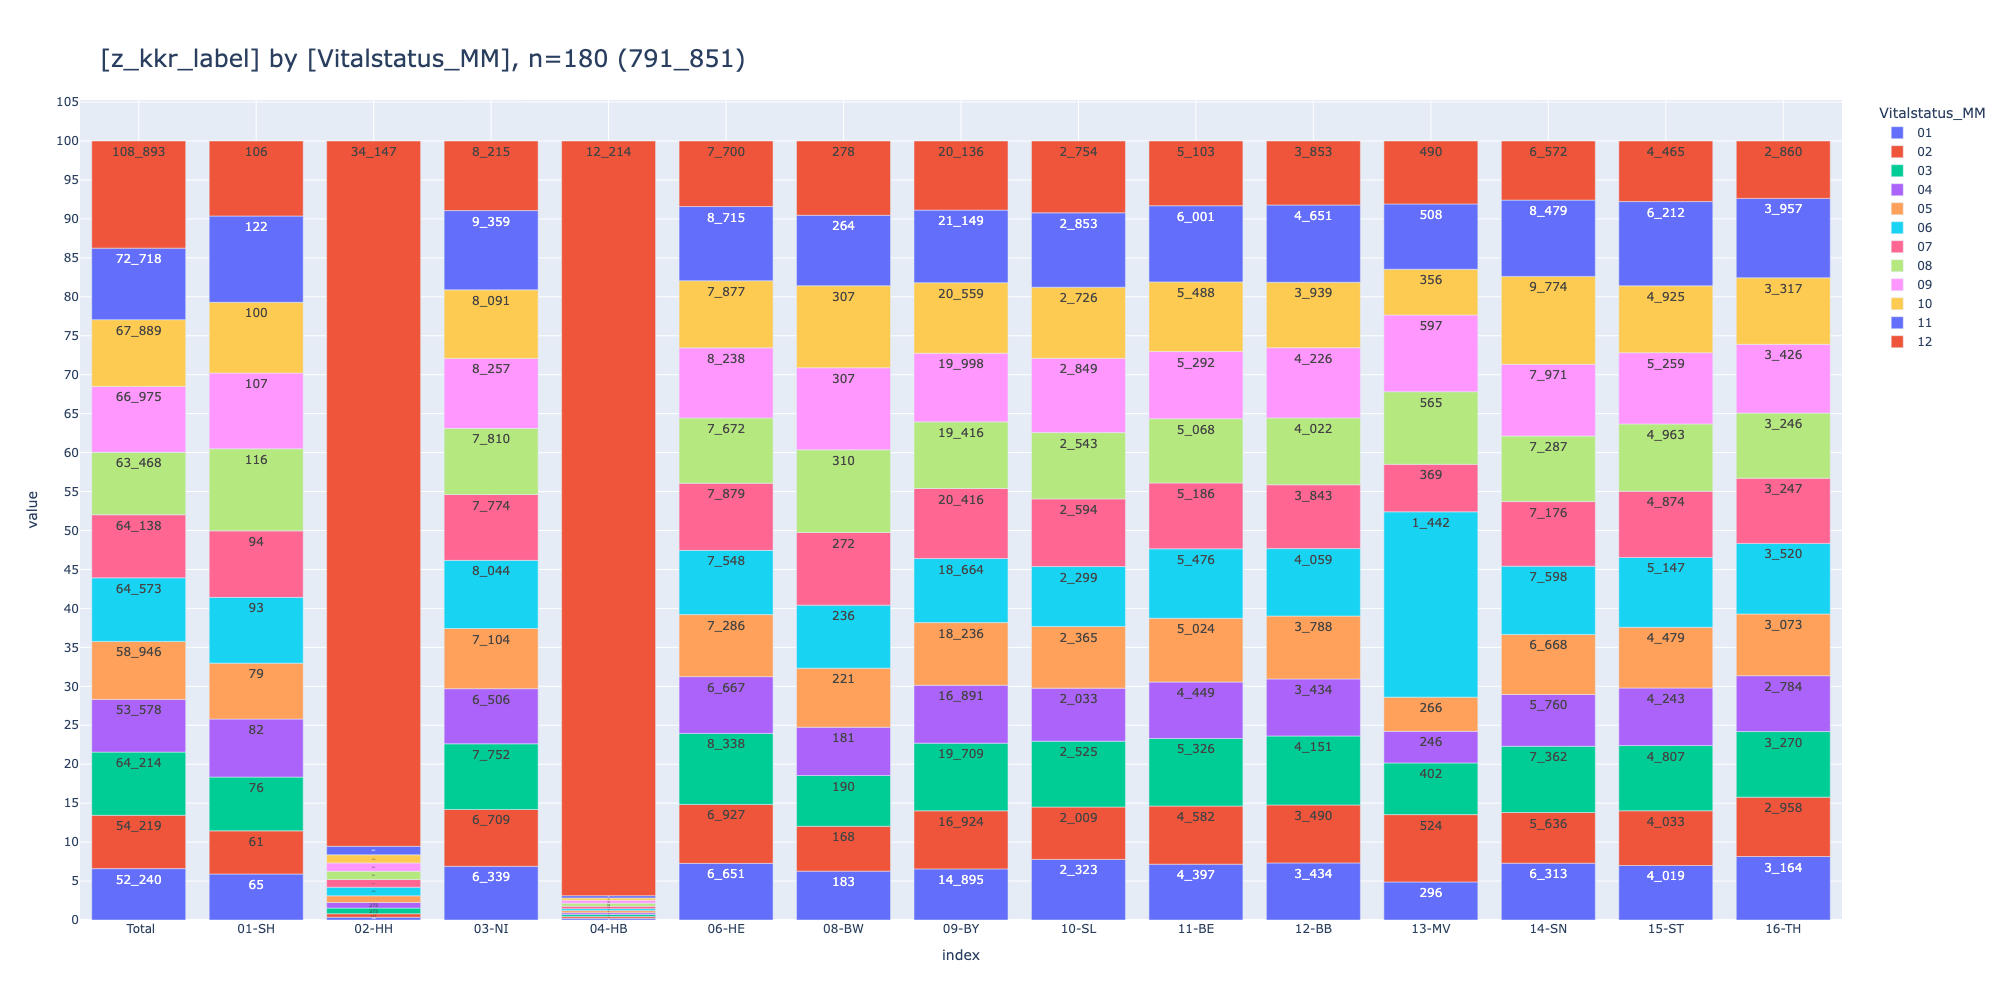

In [51]:
_tu = (Patient
    # to get tum cols
    .join(Tumor, "oBDS_RKIPatientId", "inner")
    .filter(f"Verstorben = 'N' and year(cast(Datum_Vitalstatus as date)) between 2020 and {dy_max}")
    # apply tum filter
    .filter(fil_dy)
    .project("z_kkr_label, month(cast(Datum_Vitalstatus as date)) as Vitalstatus_MM, oBDS_RKIPatientId")
    # count pat, not tum
    .aggregate("z_kkr_label,Vitalstatus_MM, count(distinct oBDS_RKIPatientId) as cnt")
    .order("z_kkr_label,Vitalstatus_MM")
    .to_df()
    .astype({"Vitalstatus_MM": "Int64"}).astype({"Vitalstatus_MM": str})
)
_tu.Vitalstatus_MM = _tu.Vitalstatus_MM.str.zfill(2)
_=pls.plot_stacked_bars(_tu.rename(columns={"cnt":"pct"}), orientation='v', show_total=True, normalize=False, relative=True, height=1000, renderer="png")
# todo wo ist NW

<div style="page-break-after: always;"></div>

## <a id='toc1_10_'></a>[Numerische Variablen 🔢](#toc0_)

In [52]:
df_numerics = (
    Tumor.project("""--sql
        z_kkr_label
        ,z_age
        ,Tumordicke
        ,Anzahl_Tage_Diagnose_Tod::int as Anzahl_Tage_Diagnose_Tod
        ,PSA
        ,LK_befallen::int as LK_befallen
        ,LK_untersucht::int as LK_untersucht
        ,RektumAbstandAnokutanlinie::int as RektumAbstandAnokutanlinie
        ,LDH::int as LDH
        """)
    .order("z_kkr_label")
    .to_df()
)

<br>

### <a id='toc1_10_1_'></a>[Diagnosealter](#toc0_)
- berechnet aus `Diagnosejahr` - `Geburtsjahr`
- negative Werte entstehen aus falscher Datumsreihenfolge von Ereignissen
- die Datumsangaben sind **nicht bereinigt**, um strukturelle Effekte sichtbar zu machen

> 💡 `HH`: _"Ja, das liegt an dem Geschätzt-Flag in den Datumsangaben. In unseren Daten haben wir noch die alte Ausprägung 'Jahr geschätzt', diese wird dann im ZFKD-Datensatz mit 'Vollständig geschätzt' übersetzt. Theoretisch könnten Sie statt 1900 auch das angegebene Jahr nutzen… Aber diese Schätz-Angabe ist uns auch ein Dorn im Auge. Wir werden es auch noch in unseren Daten bereinigen. Zumeist handelt es sich da bei uns um Dokumentations oder Verständnisfehler."_

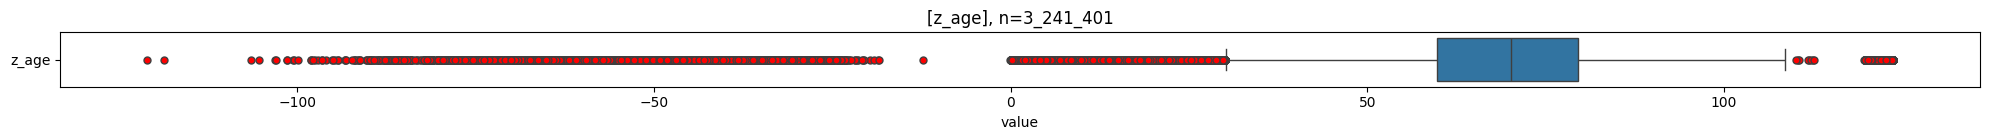

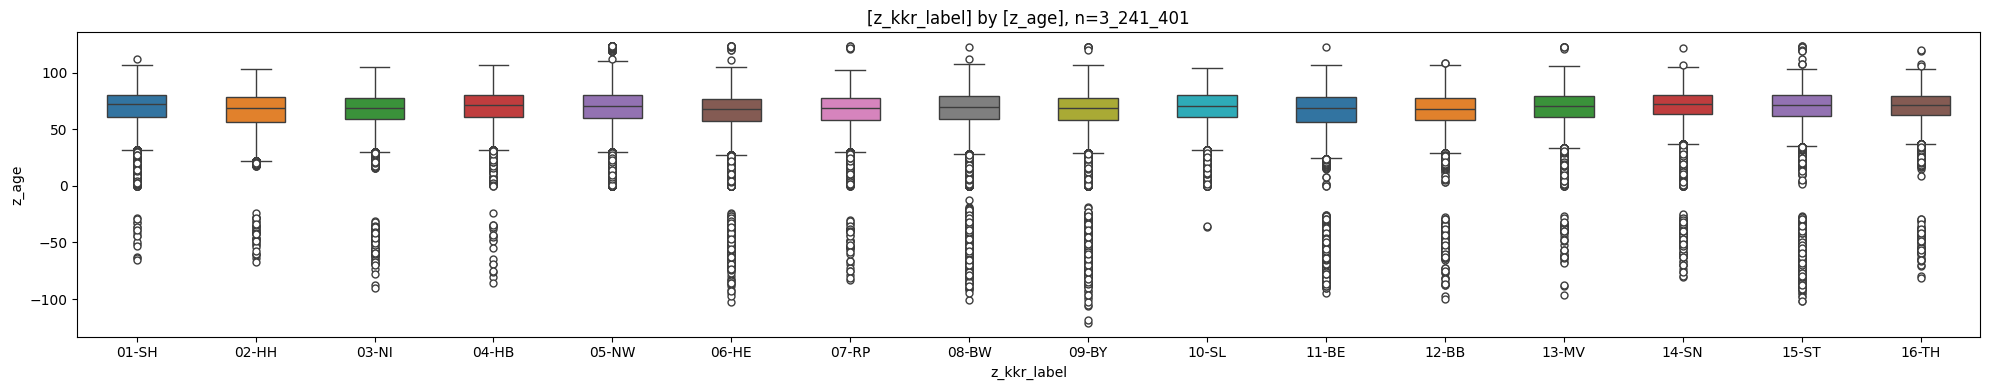


column (n = 3_241_401) |     present      |   min   | lower |  q25  | median | mean  |  q75  | upper  |  max   |  std  |  cv 
-----------------------+------------------+---------+-------+-------+--------+-------+-------+--------+--------+-------+-----
z_age                  | 3_241_401 (100%) | -121.00 | 30.17 | 59.75 |  70.17 | 68.14 | 79.50 | 108.50 | 123.67 | 15.21 | 0.22


item (n = 3_241_401) |  count  |   min   | lower |  q25  | median | mean  |  q75  | upper  |  max   |  std  |  cv 
---------------------+---------+---------+-------+-------+--------+-------+-------+--------+--------+-------+-----
01-SH                | 150_685 |  -65.75 | 31.83 | 61.17 |  72.33 | 69.85 | 80.75 | 106.67 | 112.50 | 14.30 | 0.20
02-HH                |  55_559 |  -67.17 | 22.50 | 56.25 |  68.67 | 66.15 | 78.75 | 103.50 | 103.50 | 16.19 | 0.24
03-NI                | 216_710 |  -90.17 | 30.25 | 58.83 |  68.75 | 67.03 | 77.92 | 105.33 | 105.33 | 14.23 | 0.21
04-HB                |  25_182 |  -85.83 | 3

In [53]:
_=pls.plot_box_large(df_numerics["z_age"], height=150, width=2000, summary=False)
_=pls.plot_boxes_large(df_numerics[["z_kkr_label", "z_age"]], height=400, width=2000, )

<br>

### <a id='toc1_10_2_'></a>[Anzahl Tage zwischen Diagnose und Tod](#toc0_)

> 💡 `ZfKD`: _Es treten Extremwerte auf, weit ausserhalb des Interquartilsabstandes. Grund dafür sind mutmasslich fehlende Datumsangaben, die auf 1900 kodiert werden._  
> _In der KKR Verteilung sind die Extreme in den GTDS Ländern besonders ausgeprägt_

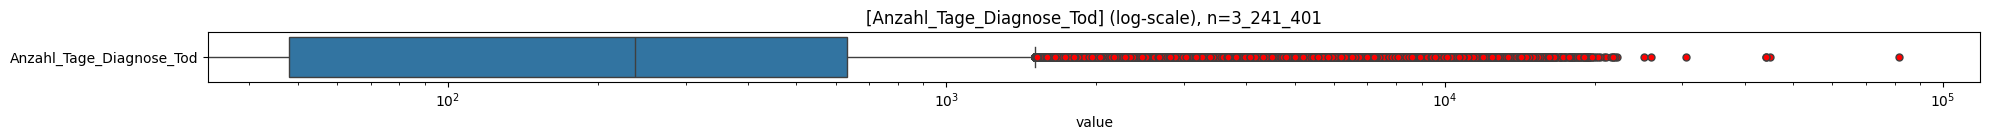

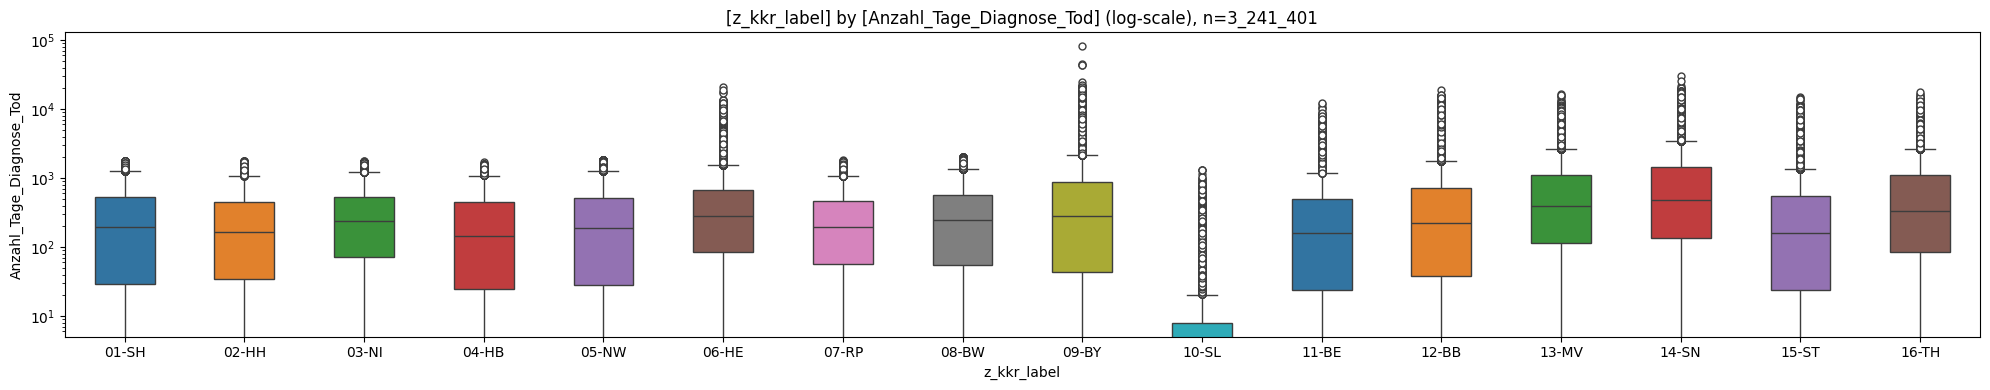


column (n = 3_241_401)   |    present    |   min   | lower |  q25  | median |  mean  |  q75   | upper |  max   |   std    |  cv 
-------------------------+---------------+---------+-------+-------+--------+--------+--------+-------+--------+----------+-----
Anzahl_Tage_Diagnose_Tod | 880_655 (27%) | -27_320 |  -212 | 48.00 | 238.00 | 599.84 | 633.00 | 1_510 | 81_801 | 1_218.24 | 2.03


item (n = 3_241_401) |  count  |   min   | lower |  q25   | median |   mean   |   q75    | upper |  max   |   std    |  cv 
---------------------+---------+---------+-------+--------+--------+----------+----------+-------+--------+----------+-----
01-SH                |  40_150 |       0 |     0 |  29.00 | 193.00 |   336.30 |   527.00 | 1_274 |  1_783 |   381.00 | 1.13
02-HH                |  17_931 |       0 |     0 |  34.00 | 163.00 |   301.89 |   456.00 | 1_089 |  1_784 |   350.89 | 1.16
03-NI                |  62_000 |       0 |     0 |  72.00 | 238.00 |   354.04 |   529.00 | 1_214 |  1_752 |   352.

In [54]:
_=pls.plot_box_large(df_numerics["Anzahl_Tage_Diagnose_Tod"], height=150, width=2000, use_log=True, summary=False)
_=pls.plot_boxes_large(df_numerics[["z_kkr_label", "Anzahl_Tage_Diagnose_Tod"]], height=400, width=2000, summary=True, use_log=True)

<br>

### <a id='toc1_10_3_'></a>[Tumordicke](#toc0_)

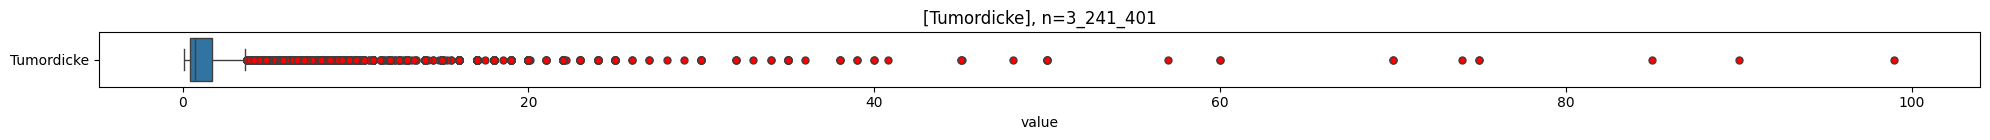


column (n = 3_241_401) |   present   |  min  | lower |  q25  | median | mean  |  q75  | upper |  max   |  std  |  cv  
-----------------------+-------------+-------+-------+-------+--------+-------+-------+-------+--------+-------+------
Tumordicke             | 26_869 (0%) | 0.100 | 0.100 | 0.400 |  0.700 | 1.732 | 1.700 | 3.600 | 99.000 | 3.269 | 1.887



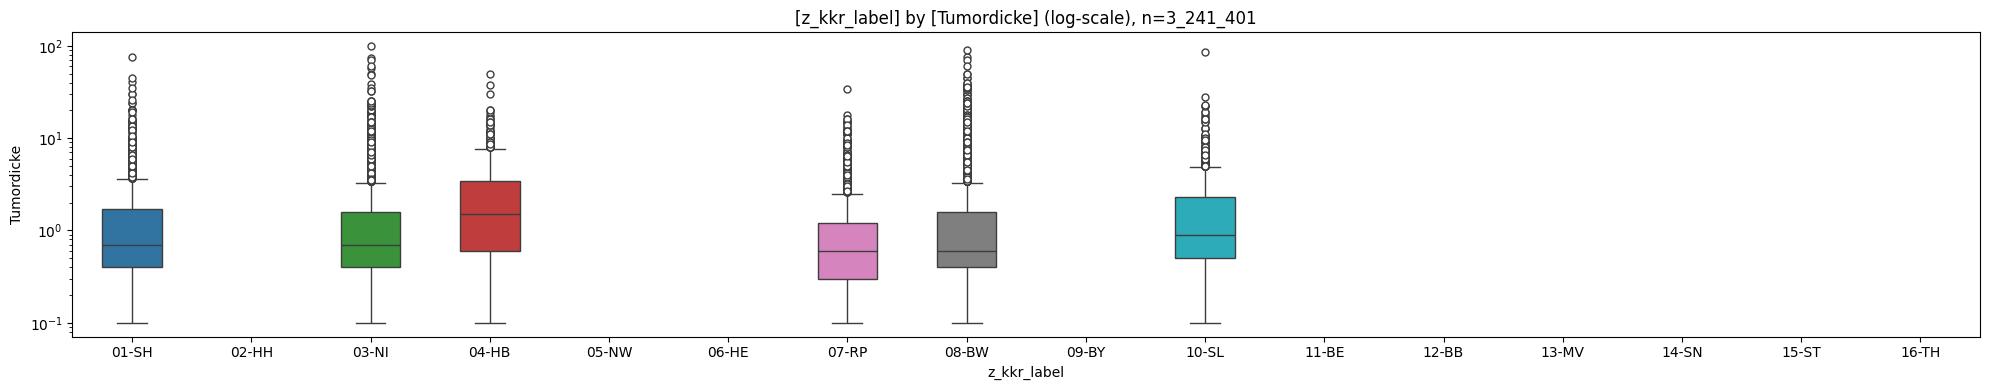

In [55]:
_=pls.plot_box_large(df_numerics["Tumordicke"], height=150, width=2000, use_log=False, violin=False, summary=True)
_=pls.plot_boxes_large(df_numerics[["z_kkr_label", "Tumordicke"]], height=400, width=2000, summary=False, use_log=True)

### <a id='toc1_10_4_'></a>[PSA](#toc0_)

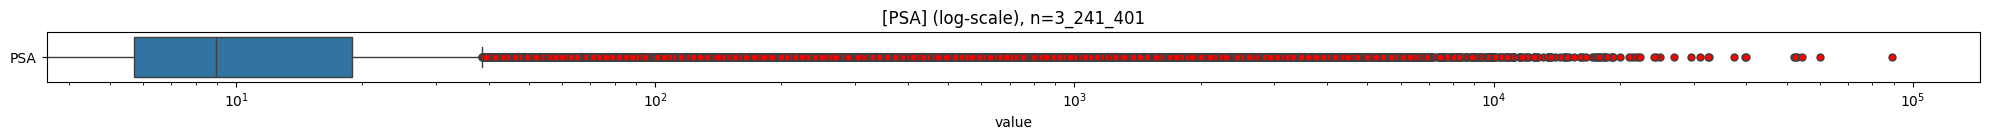


column (n = 3_241_401) |   present    |  min  | lower |  q25  | median |  mean  |  q75   | upper  |    max     |   std   |  cv  
-----------------------+--------------+-------+-------+-------+--------+--------+--------+--------+------------+---------+------
PSA                    | 145_564 (4%) | 0.000 | 0.000 | 5.720 |  8.930 | 94.472 | 18.900 | 38.670 | 89_280.000 | 728.099 | 7.707



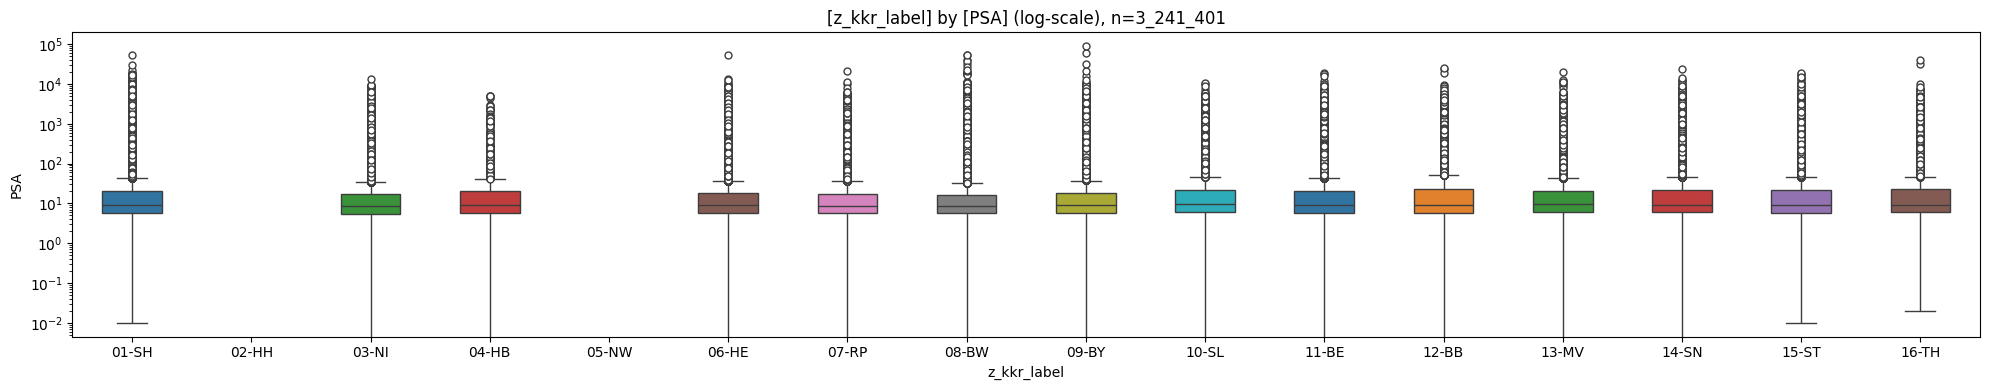

In [56]:
_=pls.plot_box_large(df_numerics["PSA"], height=150, width=2000, use_log=True, violin=False)
_=pls.plot_boxes_large(df_numerics[["z_kkr_label", "PSA"]], height=400, width=2000, summary=False, use_log=True)

### <a id='toc1_10_5_'></a>[LK_befallen](#toc0_)

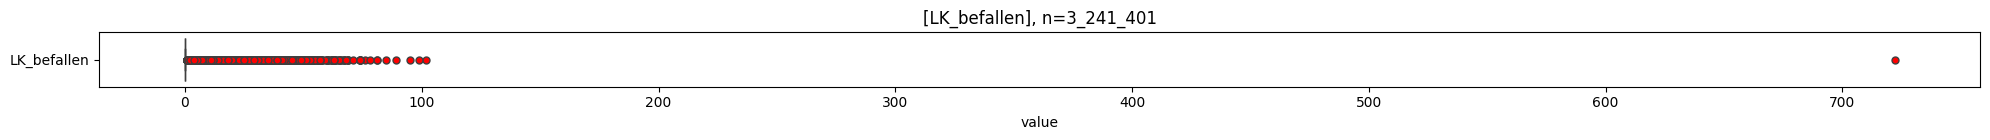


column (n = 3_241_401) |    present    | min | lower |  q25  | median | mean  |  q75  | upper | max |  std  |  cv  
-----------------------+---------------+-----+-------+-------+--------+-------+-------+-------+-----+-------+------
LK_befallen            | 633_804 (19%) |   0 |     0 | 0.000 |  0.000 | 0.911 | 0.000 |     0 | 722 | 3.095 | 3.397



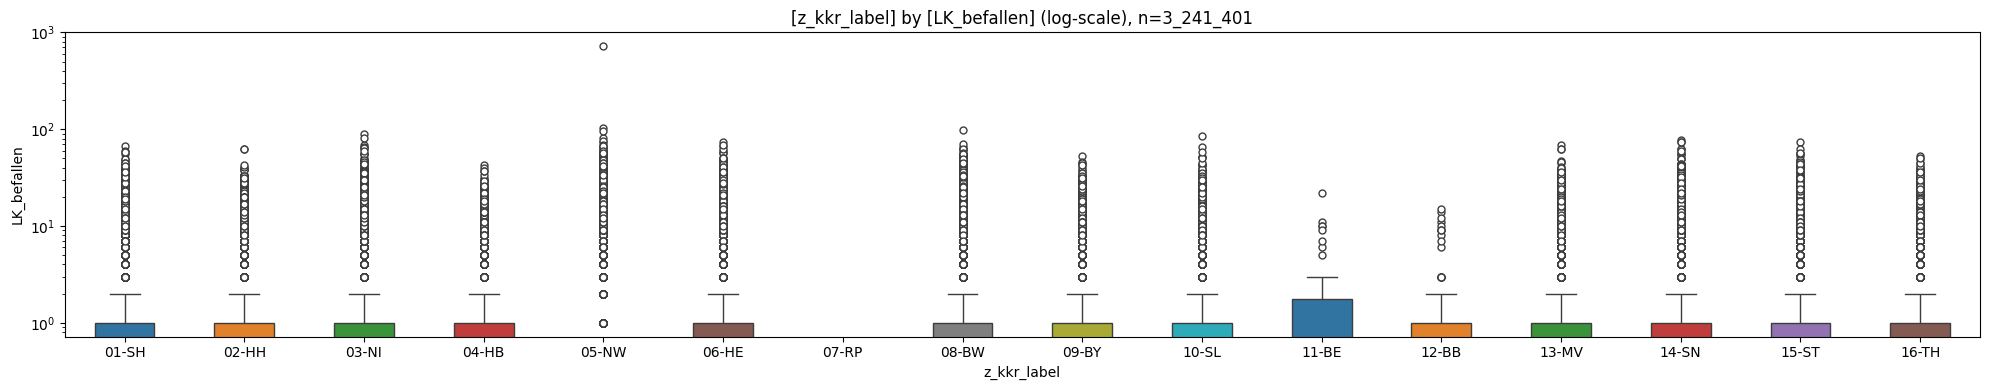

In [57]:
_=pls.plot_box_large(df_numerics["LK_befallen"], height=150, width=2000,  use_log=False, violin=False)
_=pls.plot_boxes_large(df_numerics[["z_kkr_label", "LK_befallen"]], height=400, width=2000,  summary=False, use_log=True)

### <a id='toc1_10_6_'></a>[LK_untersucht](#toc0_)

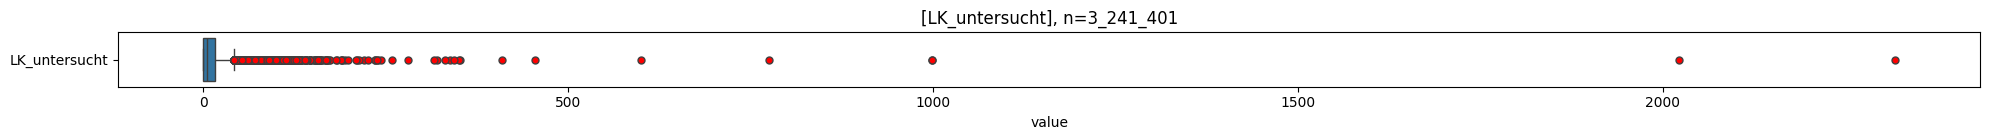


column (n = 3_241_401) |    present    | min | lower |  q25  | median |  mean  |  q75   | upper |  max  |  std   |  cv  
-----------------------+---------------+-----+-------+-------+--------+--------+--------+-------+-------+--------+------
LK_untersucht          | 761_827 (23%) |   0 |     0 | 0.000 |  5.000 | 10.543 | 17.000 |    42 | 2_319 | 13.518 | 1.282



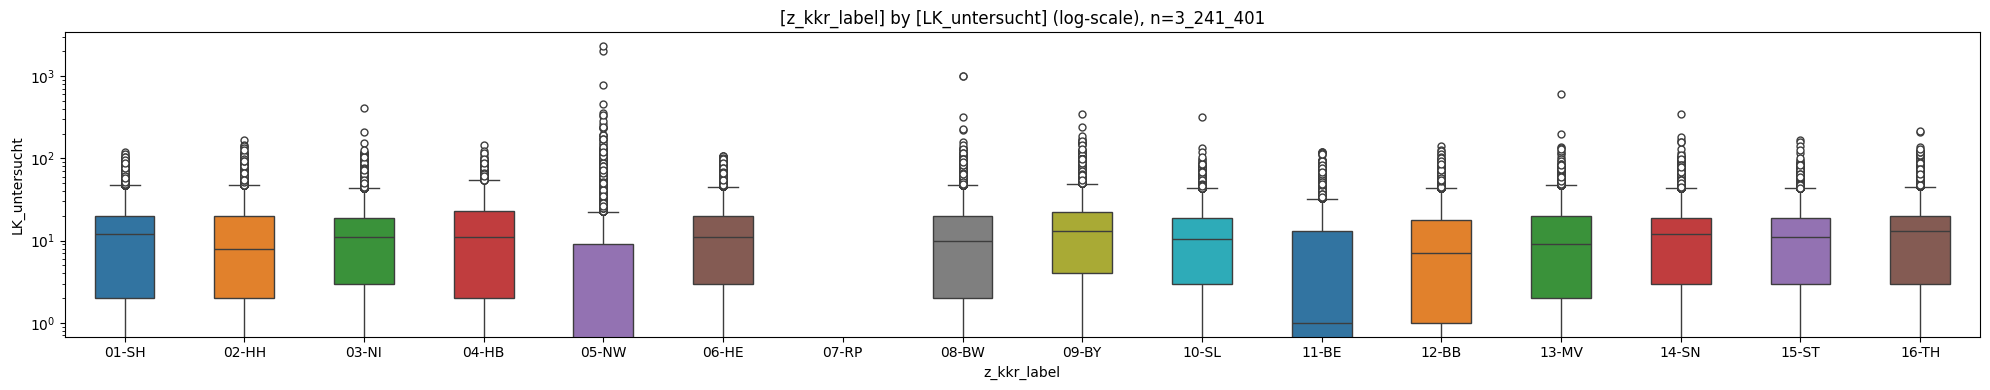

In [58]:
_=pls.plot_box_large(df_numerics["LK_untersucht"], height=150, width=2000,  use_log=False, violin=False)
_=pls.plot_boxes_large(df_numerics[["z_kkr_label", "LK_untersucht"]], height=400, width=2000,  summary=False, use_log=True)

### <a id='toc1_10_7_'></a>[RektumAbstandAnokutanlinie](#toc0_)

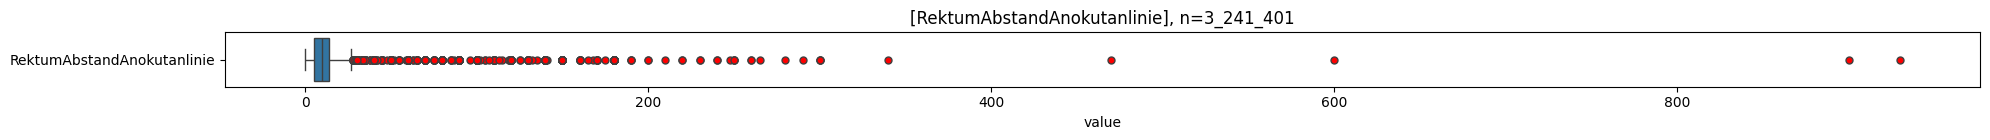


column (n = 3_241_401)     |   present   | min | lower |  q25  | median |  mean  |  q75   | upper | max |  std   |  cv  
---------------------------+-------------+-----+-------+-------+--------+--------+--------+-------+-----+--------+------
RektumAbstandAnokutanlinie | 32_714 (1%) |   0 |     0 | 5.000 | 10.000 | 11.615 | 14.000 |    27 | 930 | 18.365 | 1.581



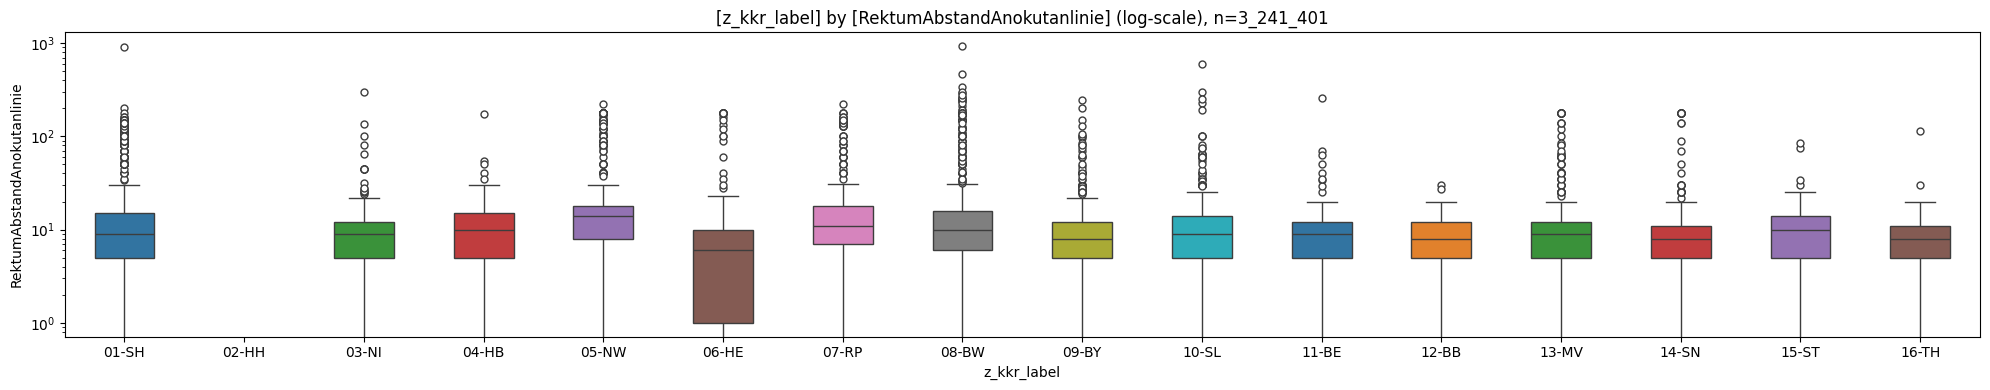

In [59]:
_=pls.plot_box_large(df_numerics["RektumAbstandAnokutanlinie"], height=150, width=2000,  use_log=False, violin=False)
_=pls.plot_boxes_large(df_numerics[["z_kkr_label", "RektumAbstandAnokutanlinie"]], height=400, width=2000,  summary=False, use_log=True)

### <a id='toc1_10_8_'></a>[LDH](#toc0_)

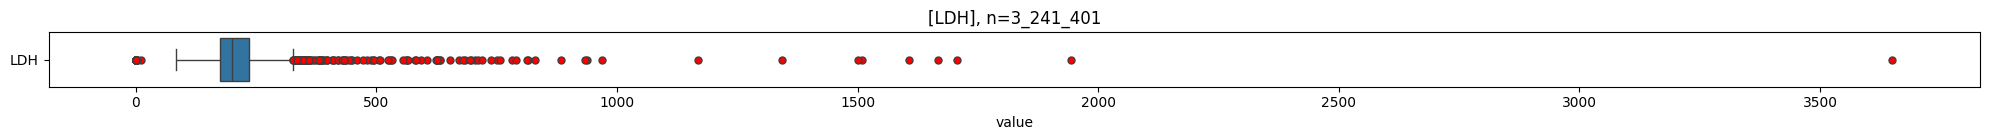


column (n = 3_241_401) |  present   | min | lower |   q25   | median  |  mean   |   q75   | upper |  max  |   std   |  cv  
-----------------------+------------+-----+-------+---------+---------+---------+---------+-------+-------+---------+------
LDH                    | 2_231 (0%) |   1 |    83 | 174.000 | 200.000 | 219.252 | 235.000 |   326 | 3_650 | 141.193 | 0.644



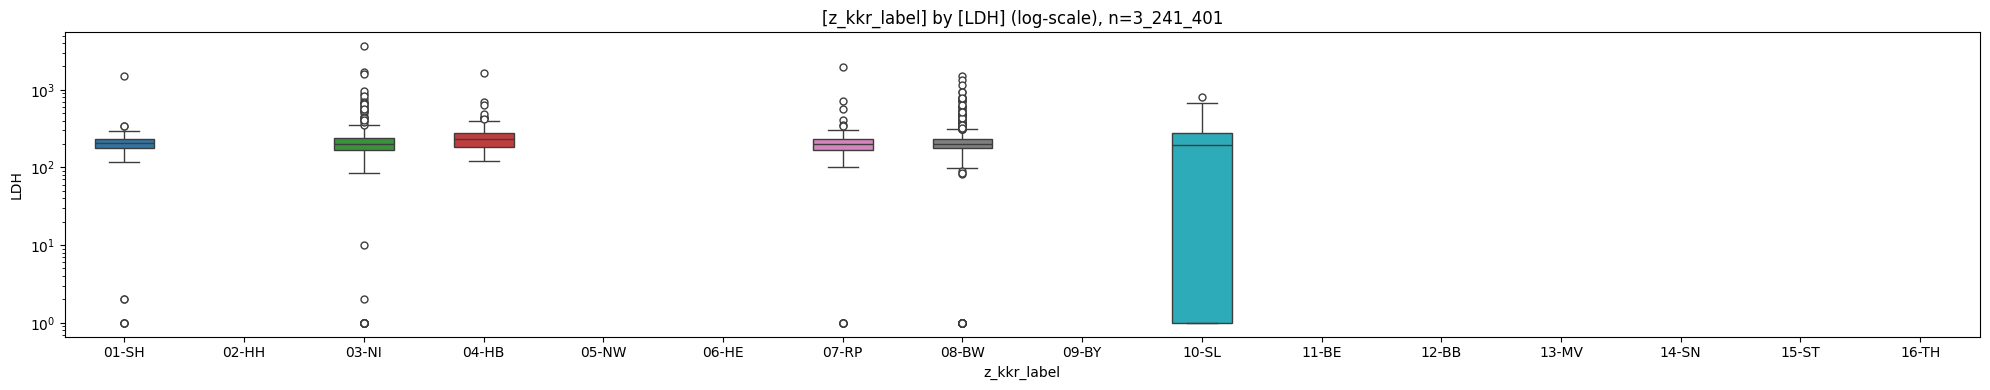

In [60]:
_=pls.plot_box_large(df_numerics["LDH"], height=150, width=2000,  use_log=False, violin=False)
_=pls.plot_boxes_large(df_numerics[["z_kkr_label", "LDH"]], height=400, width=2000,  summary=False, use_log=True)